## Imports of standard libraries

In [1]:
# Standard Libraries
import os
import sys
import math
import ast
import pickle
import warnings
from pathlib import Path
import re

# Scientific Libraries
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d, CubicSpline
from numpy.polynomial.polynomial import Polynomial
from scipy.fft import fft, ifft

# Machine Learning Libraries
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import scipy.stats as stats
import tensorflow as tf

# Visualization Libraries
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LogNorm
from matplotlib.colors import to_rgba
import seaborn as sns

# IPython Display and Widget Libraries
from IPython.display import display, HTML
import ipywidgets
from ipywidgets import IntSlider, Dropdown, RadioButtons, HBox, Checkbox, ToggleButtons, Layout, Box, Button, Label, FloatSlider

# TensorFlow version check
print("TensorFlow version: ", tf.__version__)

# Display Settings
display(HTML("<style>.jp-Cell { width: 80% !important; margin: 0 auto; }</style>"))

# Suppress Warnings
# Suppress specific warning about KMeans memory leak on Windows with MKL
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak")
# Suppress specific RuntimeWarning about divide by zero
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Project Directory and Data Path Settings
home_dir = Path.cwd().parent
sys.path.append(f"{home_dir}/data_preprocessing/utilities")
data_path = f"{home_dir}/data"

# Set the global font to Times New Roman
plt.rc('font', family='Arial')  

TensorFlow version:  2.10.0


## Data imports

In [2]:
# Specify interval at which data were resampled
interval = '30s'
# Number of padded datapoints at either end of each event in dataset - added at data preprocessing
predefined_max_lag_size = 90
# Choosing which scale to use normalized/original scale
normalized = False

In [3]:
# Define suffix based on whether normalized or not
norm = '_norm' if normalized else ''

# Load the dictionary containing all datasets
with open(f'{data_path}/prepared_datasets/multipar_datasets_{interval}{norm}.pkl', 'rb') as f:
    multipar_datasets = pickle.load(f)

# Convert to NumPy arrays if the data is not already normalized
if normalized:
    multipar_train_dataset_list = multipar_datasets['train_datasets']  # Already NumPy ndarray
    multipar_val_dataset_list = multipar_datasets['val_datasets']
    multipar_test_dataset_list = multipar_datasets['test_datasets']
else:
    multipar_train_dataset_list = multipar_datasets['train_datasets']
    multipar_val_dataset_list = multipar_datasets['val_datasets']
    multipar_test_dataset_list = multipar_datasets['test_datasets']
    for i in range(len(multipar_train_dataset_list)):
        multipar_train_dataset_list[i].iloc[:90] = -111  # Set first 90 rows to -111
        multipar_train_dataset_list[i].iloc[-90:] = -111  # Set last 90 rows to -111
    for i in range(len(multipar_val_dataset_list)):
        multipar_val_dataset_list[i].iloc[:90] = -111  # Set first 90 rows to -111
        multipar_val_dataset_list[i].iloc[-90:] = -111  # Set last 90 rows to -111
    for i in range(len(multipar_test_dataset_list)):
        multipar_test_dataset_list[i].iloc[:90] = -111  # Set first 90 rows to -111
        multipar_test_dataset_list[i].iloc[-90:] = -111  # Set last 90 rows to -111
    multipar_train_dataset_list = [df.to_numpy() for df in multipar_train_dataset_list]  # Convert DataFrame to NumPy
    multipar_val_dataset_list = [df.to_numpy() for df in multipar_val_dataset_list]
    multipar_test_dataset_list = [df.to_numpy() for df in multipar_test_dataset_list]

In [4]:
[len(a) for a in multipar_test_dataset_list]

[2345, 911, 301, 2407, 661, 657, 943, 662]

In [5]:
# Replacing paded values with the lowest value possible in normalized dataset
multipar_train_dataset_list = [np.where(period == -111, np.nan, period) for period in multipar_train_dataset_list]
multipar_val_dataset_list = [np.where(period == -111, np.nan, period) for period in multipar_val_dataset_list]
multipar_test_dataset_list = [np.where(period == -111, np.nan, period) for period in multipar_test_dataset_list]

## Initializing scaler

In [6]:
# Load the dictionary containing all merged datasets
with open(f'{data_path}/prepared_datasets/multipar_datasets_{interval}.pkl', 'rb') as f:
    multipar_datasets = pickle.load(f)

# Accessing train dataset
train_datasets_merged_multi = pd.concat([period.replace(-111, np.nan).dropna() for period in multipar_datasets['train_datasets']])

# Initiating scaler
scaler = MinMaxScaler(feature_range=(0,1))
# Fitting scaller to ALL train data, so we have to concat precipitation events in train dataset
scaler = scaler.fit(train_datasets_merged_multi)

### Import of lists of model names

In [7]:
def list_models(directory):
    '''
    Lists all the models in the directory

    Args:
      directory (str) - path to the folder with forward and backward models
    Returns:
      folder_names (list of str) - list of folder names (model configurations)
    '''
    # Initialize an empty list to store folder names
    folder_names = []
    
    # Iterate over all entries in the directory
    for entry in os.listdir(directory):
        # Join the directory path with the entry name
        full_path = os.path.join(directory, entry)
        
        # Check if the entry is a directory
        if os.path.isdir(full_path):
            # Append the folder name to the list
            folder_names.append(entry)
    
    return folder_names

In [8]:
# Specify the directories with models
folder_with_turb_models = f'{home_dir}/models_archive/turb_models_forecasts'
folder_with_cond_models = f'{home_dir}/models_archive/cond_models_forecasts'
folder_with_pH_models = f'{home_dir}/models_archive/pH_models_forecasts'

In [9]:
# Lists of configurations of models
turb_case_list = [folder_name for folder_name in list_models(folder_with_turb_models)if interval in folder_name]
cond_case_list = [folder_name for folder_name in list_models(folder_with_cond_models)if interval in folder_name]
pH_case_list = [folder_name for folder_name in list_models(folder_with_pH_models)if interval in folder_name]

In [10]:
# List of models
print('Turbidity models:\n\n', pd.Series(turb_case_list))
print()
print('Conductivity models:\n\n', pd.Series(cond_case_list))
print()
print('pH models:\n\n', pd.Series(pH_case_list))

Turbidity models:

 0      CNN-10-20-30s
1      CNN-10-40-30s
2      CNN-10-60-30s
3      CNN-20-20-30s
4      CNN-20-40-30s
5      CNN-20-60-30s
6       CNN-5-20-30s
7       CNN-5-40-30s
8       CNN-5-60-30s
9     LSTM-10-20-30s
10    LSTM-10-40-30s
11    LSTM-10-60-30s
12    LSTM-20-20-30s
13    LSTM-20-40-30s
14    LSTM-20-60-30s
15     LSTM-5-20-30s
16     LSTM-5-40-30s
17     LSTM-5-60-30s
18     MLP-10-20-30s
19     MLP-10-40-30s
20     MLP-10-60-30s
21     MLP-20-20-30s
22     MLP-20-40-30s
23     MLP-20-60-30s
24      MLP-5-20-30s
25      MLP-5-40-30s
26      MLP-5-60-30s
dtype: object

Conductivity models:

 0      CNN-10-20-30s
1      CNN-10-40-30s
2      CNN-10-60-30s
3      CNN-20-20-30s
4      CNN-20-40-30s
5      CNN-20-60-30s
6       CNN-5-20-30s
7       CNN-5-40-30s
8       CNN-5-60-30s
9     LSTM-10-20-30s
10    LSTM-10-40-30s
11    LSTM-10-60-30s
12    LSTM-20-20-30s
13    LSTM-20-40-30s
14    LSTM-20-60-30s
15     LSTM-5-20-30s
16     LSTM-5-40-30s
17     LSTM-5-60-3

### Forecasts

In [11]:
%%time

def importing_forecasts(folder_with_models, parameter, dataset_type):
    # Create a dictionary to map each parameter to its corresponding index
    par_map = {'turb': (3, turb_case_list),'cond': (0, cond_case_list),'pH': (4, pH_case_list)}

    # Retrieve the corresponding lists using the parameter
    par_col, case_list = par_map.get(parameter, (None, None))
    
    # Indeces of the models
    case_indeces = list(range(len(case_list)))

    # Importing the list of forecasts
    forecast = []
    for case_ind in case_indeces:
        try:
            # Path to the specific model folder
            model_path = f'{folder_with_models}/{case_list[case_ind]}'
            # Count number of "run" subfolders in the model folder
            n_runs = sum(os.path.isdir(os.path.join(model_path, item)) for item in os.listdir(model_path))
            forecast_run = []
            for run_n in range(n_runs):
                # Load the pickle file
                with open(f'{model_path}/run_{run_n}/forecasts/forecasts_{dataset_type}_norm.pkl', 'rb') as f:
                    forc = pickle.load(f)[0]
                    # MLP and CNN forecasts have 3 dimentions in not normalized dataset, squeezing them
                    forc = [ev.squeeze() for ev in forc]

                    if normalized == True:
                        forecast_run.append(forc)
                    else:
                        forecast_run.append([np.array([scaler.inverse_transform(np.tile(forc[ev][instan][:, np.newaxis], (1, 10)))[:, par_col] for instan in range(len(forc[ev]))]) for ev in range(len(forc))])
        except FileNotFoundError:
            # File not found, continue with the next step
            forecast.append([])
            continue
        forecast.append(forecast_run)
    return forecast

# Forecasts
turb_forecast_test = importing_forecasts(folder_with_turb_models, 'turb', 'test')
cond_forecast_test = importing_forecasts(folder_with_cond_models, 'cond', 'test')
pH_forecast_test = importing_forecasts(folder_with_pH_models, 'pH', 'test')

# turb_forecast_train = importing_forecasts(folder_with_turb_models, 'turb', 'train', normalized)
# cond_forecast_train = importing_forecasts(folder_with_cond_models, 'cond', 'train', normalized)
# pH_forecast_train = importing_forecasts(folder_with_pH_models, 'pH', 'train', normalized)

CPU times: total: 1min 11s
Wall time: 1min 26s


In [12]:
def available_l_g_sizes(case_list):  
    # Identifying lag and gap sizes present in the list of configurations of the models
    lag_list, gap_list = zip(*(map(ast.literal_eval, case.split('-')[1:3]) for case in case_list))

    # Unique lists of each individual parameter
    unique_lag_list = list(set(lag_list))
    unique_gap_list = list(set(gap_list))

    # Possible combinations of lag and gap sizes that I use in my model
    l_g_list = np.unique(np.transpose(np.array([lag_list, gap_list])), axis = 0)
    print('Available combinations of l_s and g_s:\n', l_g_list)
    return unique_lag_list, unique_gap_list, l_g_list

turb_unique_lag_list, turb_unique_gap_list, turb_l_g_list = available_l_g_sizes(turb_case_list)
cond_unique_lag_list, cond_unique_gap_list, cond_l_g_list = available_l_g_sizes(cond_case_list)
pH_unique_lag_list, pH_unique_gap_list, pH_l_g_list = available_l_g_sizes(pH_case_list)

Available combinations of l_s and g_s:
 [[ 5 20]
 [ 5 40]
 [ 5 60]
 [10 20]
 [10 40]
 [10 60]
 [20 20]
 [20 40]
 [20 60]]
Available combinations of l_s and g_s:
 [[ 5 20]
 [ 5 40]
 [ 5 60]
 [10 20]
 [10 40]
 [10 60]
 [20 20]
 [20 40]
 [20 60]]
Available combinations of l_s and g_s:
 [[ 5 20]
 [ 5 40]
 [ 5 60]
 [10 20]
 [10 40]
 [10 60]
 [20 20]
 [20 40]
 [20 60]]


In [13]:
def available_models(l, g, case_list):
    '''
    This function returns available w_g cases and their indexes in the main collection of cases for specific l and g sizes

    Args:
      l (int) - number of datapoints preceding OR succeeding the gap, NOT BOTH TOGETHER
      g (int) - number of missing datapoints
    Returns:
      available_cases (list) - configurations of the model for given l and g
    '''
    available_cases = []
    # i - index in original case_list
    for case, i in zip(case_list, range(len(case_list))):
        l_s_found, g_s_found = map(ast.literal_eval, case.split('-')[1:3])
        if l_s_found == l and g_s_found == g:
            available_cases.append([case, i])
    return available_cases

### Metrics

In [14]:
def fourier_interpolation(x_interp, x_known, y_known, num_terms=20):
    N = len(y_known)
    Y = fft(y_known)  # Compute FFT of known data
    Y[num_terms:] = 0  # Keep only first 'num_terms' frequencies
    y_fourier_full = ifft(Y).real  # Inverse FFT to reconstruct signal
    fourier_interp = interp1d(x_known, y_fourier_full, kind='cubic')
    return fourier_interp(x_interp)

def idw_interpolation(x_interp, x_known, y_known, power=2):
    y_interp = []
    for xi in x_interp:
        weights = 1 / np.abs(x_known - xi) ** power
        weights /= np.sum(weights)
        y_interp.append(np.sum(weights * y_known))
    return np.array(y_interp)


# This function returns a nested list needed for prediction and plotting
def instance_event_collection(l, g, event_list, param, base=True):
    '''
    This function returns y, str_line, instance for each instance of each event for different configurations of l and g

    Args:
      l (int) - number of datapoints preceding OR succeeding the gap, NOT BOTH TOGETHER
      g (int) - number of missing datapoints
    Returns:
      list_of_instance_arrays (list) - lists of y, str_line, and instance number
    '''

    # Column indeces of the parameters in the events
    param_columns = {'cond': 0, 'temp': 1, 'DO': 2, 'turb': 3, 'pH': 4, 'flow': 5, 'cum_disch':6, 'time_since_rain':7, 'time_since_rain_started':8}
    par_col = param_columns[param]
    
    # Number of instances in each event
    n_inst = [(len(el[predefined_max_lag_size: -(predefined_max_lag_size)]) - 2 * l) - g + 1  for el in event_list]

    # Collection of instances for each combination of l and g for each event
    # Combination of l and g
        # event
            # instance
                # y, base_line, initial_ind
    list_of_instance_arrays = []
    for n_event in range(len(event_list)):
        instance_list = []
        event = event_list[n_event][predefined_max_lag_size: -(predefined_max_lag_size), par_col]
        for instance_number in range(n_inst[n_event]):
            #Shifting event's beginning
            event_inst = event[instance_number:]
            
            # Observed labels
            y = event_inst[l:l + g]
            
            if base == True:
                # Input data for the plot
                pr_w = event_inst[:l]
                suc_w = event_inst[l+g:2*l+g]

                # Interpolations
                x_known = np.concatenate([np.array(range(l)), np.array(range(l+g, 2*l+g))])
                y_known = np.concatenate([pr_w, suc_w])
                # Generate interpolated values
                x_interp = np.linspace(0, 2*l+g-1, 2*l+g)

                # Linear
                linear_interp = interp1d(x_known, y_known, kind='linear')
                y_linear = linear_interp(x_interp)[l:l+g]
                
                # Cubic Spline Interpolation
                spline_interp = CubicSpline(x_known, y_known)
                y_spline = spline_interp(x_interp)[l:l+g]

                # Inverse Distance Weighting (IDW) Interpolation
                y_idw = idw_interpolation(x_interp[l:l+g], x_known, y_known)

                
                # Fourier-based Interpolation
                y_fourier = fourier_interpolation(x_interp[l:l+g], x_known, y_known)
                                 
            elif base == False:
                y_linear = None
                pr_w = None
                suc_w = None
            
            instance_list.append((y, y_linear, y_spline, y_idw, y_fourier, pr_w, suc_w, instance_number))
        list_of_instance_arrays.append(instance_list)
    return list_of_instance_arrays


# %%time
# z = instance_event_collection(20, 20, multipar_test_dataset_list, 'turb', base=True)[0][55]

# x = np.arange(len(z[0]))  # X-axis values
# for series in z[:5]:
#     plt.plot(x, series)

In [15]:
def mean_absolute_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def symmetric_mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100

def mean_squared_error(y_true, y_pred):
    return np.mean(np.square(y_true - y_pred))

def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(np.mean(np.square(y_true - y_pred)))

def pearson_correlation_coefficient(y_true, y_pred):
    return np.corrcoef(y_true, y_pred)[0, 1]

def residual_sum_of_squares(y_true, y_pred):
    return np.sum(np.square(y_true - y_pred))

def coefficient_of_determination(y_true, y_pred):
    ss_res = np.sum(np.square(y_true - y_pred))
    ss_tot = np.sum(np.square(y_true - np.mean(y_true)))
    return 1 - (ss_res / ss_tot)


# Define a dictionary mapping metric names to their corresponding functions
metric_functions = {
    "RMSE": root_mean_squared_error,
    # "MAE": mean_absolute_error,
    # "MSE": mean_squared_error,
    # "MAPE": mean_absolute_percentage_error,
    # "SMAPE": symmetric_mean_absolute_percentage_error
    # "PCC": pearson_correlation_coefficient,
    # "RSR": residual_sum_of_squares,
    # "R2": coefficient_of_determination
}

In [16]:
# def percentile_into_threshold(lag, gap, param, percentile_threshold):
#     combined_variances = []
#     for eve in range(len(multipar_test_dataset_list)):
#         # Getting range variance 
#         number_of_instances = (len(multipar_test_dataset_list[eve][predefined_max_lag_size: -(predefined_max_lag_size)]) - 2 * lag) - gap + 1
#         eve_inst_array = instance_event_collection(lag, gap, multipar_test_dataset_list, param, base=True)[eve]
#         # Collection of all instances for this event
#         list_of_event_instances = [eve_inst_array[instance][0] for instance in range(number_of_instances)]
    
#         # Calculate range ('peak-to-peak') for each instance
#         variances = [np.ptp(array) for array in list_of_event_instances]
    
#         # Combining events into one list to find and return a value of a threshold
#         combined_variances = combined_variances + variances
    
#     threshold = np.percentile(combined_variances, percentile_threshold)

#     return threshold

# def clustering_instances_event(event_inst_array, n_of_instances, threshold):
#     # Collection of all instances for this event
#     list_of_event_instances = [event_inst_array[instance][0] for instance in range(n_of_instances)]
    
#     # Calculate range ('peak-to-peak') for each instance
#     variances = np.array([np.ptp(array) for array in list_of_event_instances]).reshape(-1, 1)


#     # Create a boolean mask for values greater than threshold
#     boolean_mask = variances > threshold
#     # Convert the boolean mask to an integer mask (0 and 1)
#     labels = boolean_mask.astype(int)

#     # More intuitive labels
#     labels = ["included" if value == 1 else "excluded" for value in labels]

#     return np.array(labels), variances


# list_of_instance_arrays = []
# for n_event in range(len(event_list)):
#     instance_list = []
#     event = event_list[n_event][predefined_max_lag_size: -(predefined_max_lag_size), par_col]
#     for instance in range(n_inst[n_event]):
#         #Shifting event's beginning
#         event_inst = event[instance:]
        
#         # Observed labels
#         y = event_inst[l:l + g]
        
#         if base == True:
#             # Input data for the plot
#             pr_w = event_inst[:l]
#             suc_w = event_inst[l+g:2*l+g]

#             # Interpolations
#             x_known = np.concatenate([np.array(range(l)), np.array(range(l+g, 2*l+g))])
#             y_known = np.concatenate([pr_w, suc_w])
#             # Generate interpolated values
#             x_interp = np.linspace(0, 2*l+g-1, 2*l+g)

#             # Linear
#             linear_interp = interp1d(x_known, y_known, kind='linear')
#             y_linear = linear_interp(x_interp)[l:l+g]
#         elif base == False:
#             y_linear = None
#             pr_w = None
#             suc_w = None



def percentile_into_threshold(lag, gap, param, percentile_threshold_lower):

    '''
    This function turns a percentile threshold into RMSE for this percent and this percent + 1
    '''

    percentile_threshold_upper = percentile_threshold_lower + 1
    combined_RMSE = []
    for eve in range(len(multipar_test_dataset_list)):
        # Getting range variance 
        number_of_instances = (len(multipar_test_dataset_list[eve][predefined_max_lag_size: -(predefined_max_lag_size)]) - 2 * lag) - gap + 1
        eve_inst_array = instance_event_collection(lag, gap, multipar_test_dataset_list, param, base=True)[eve]
        # Collection of all instances for this event
        list_of_event_observations = [eve_inst_array[instance][0] for instance in range(number_of_instances)]
        list_of_event_lin_interp = [eve_inst_array[instance][1] for instance in range(number_of_instances)]

    
        event_list_RMSE = []
        # LR vs LI - uncomment needed
        # for instance in list_of_event_observations:
        #     # Fit linear model
        #     X = np.arange(len(instance)).reshape(-1, 1)
        #     model = LinearRegression()
        #     model.fit(X, instance)
        #     # Calculate trend
        #     trend = model.predict(X)
        #     rel_res = (instance - trend)/trend*100
        
        for obs, LI in zip(list_of_event_observations, list_of_event_lin_interp):
            RMSE = root_mean_squared_error(obs, LI)
            event_list_RMSE.append(RMSE)
    
        # Combining all events into one list to find and return a value of a threshold
        combined_RMSE = combined_RMSE + event_list_RMSE
    
    threshold_lower = np.nanpercentile(combined_RMSE, percentile_threshold_lower)
    threshold_upper = np.nanpercentile(combined_RMSE, percentile_threshold_upper)

    return threshold_lower, threshold_upper



def clustering_instances_event(event_inst_array, n_of_instances, thresholds):
    threshold_lower, threshold_upper = thresholds
    # Collection of all instances for this event
    list_of_event_observations = [event_inst_array[instance][0] for instance in range(n_of_instances)]
    list_of_event_lin_interp = [event_inst_array[instance][1] for instance in range(n_of_instances)]
    
    event_list_RMSE = []
    # LR vs LI - uncomment needed
    # for instance in list_of_event_observations:
    #     # Fit linear model
    #     X = np.arange(len(instance)).reshape(-1, 1)

    #     model = LinearRegression()
    #     model.fit(X, instance)
    #     # Calculate trend
    #     trend = model.predict(X)

    #     # calculate residuals from linear trend
    #     rel_res = (instance - trend)/trend*100

    for obs, LI in zip(list_of_event_observations, list_of_event_lin_interp):
        # I pick mean absolute deviation as a measure of variation of the instance
        RMSE = root_mean_squared_error(obs, LI)
        event_list_RMSE.append(RMSE)
                              
    event_list_RMSE = np.array(event_list_RMSE).reshape(-1, 1)

    # Create a boolean mask for values greater than threshold
    boolean_mask = (threshold_lower < event_list_RMSE) & (event_list_RMSE <= threshold_upper)
    # Convert the boolean mask to an integer mask (0 and 1)
    labels = boolean_mask.astype(int)

    # More intuitive labels
    labels = ["included" if value == 1 else "excluded" for value in labels]

    return np.array(labels), event_list_RMSE
    

# This code makes a list of average metric scores per event for each specific combination of l_s and g_s
def metrics_benchmark(event_list, metric_name, l_g_list, param, percentile_threshold):
    metric_l_g_list = []
    metric_l_g_list_total = []
    for l, g in l_g_list:
        metric_event_list_linear, metric_event_list_spline, metric_event_list_idw, metric_event_list_fourier = [], [], [], []
        metric_event_list_linear_instances, metric_event_list_spline_instances, metric_event_list_idw_instances, metric_event_list_fourier_instances = [], [], [], []
        inst_ev_col = instance_event_collection(l, g, event_list, param, base=True)
        thresholds = percentile_into_threshold(l, g, param, percentile_threshold)
        for n_event in range(len(event_list)):
            obs_event_instances = inst_ev_col[n_event]

            # Clustering instances
            cluster_mask = clustering_instances_event(obs_event_instances, len(obs_event_instances), thresholds)[0]

            # Filter out the arrays corresponding to 'excluded' in the binary mask
            list_of_instances = [instance for instance, labels in zip(obs_event_instances, cluster_mask) if labels == 'included']

            # List of metric scores for instances within each event for this configuration
            metric_instance_list_linear = [metric_functions[metric_name](list_of_instances[instance][0], list_of_instances[instance][1]) for instance in range(len(list_of_instances))]
            metric_event_list_linear.append(np.mean(metric_instance_list_linear))
            metric_event_list_linear_instances.append(metric_instance_list_linear)

            metric_instance_list_spline = [metric_functions[metric_name](list_of_instances[instance][0], list_of_instances[instance][2]) for instance in range(len(list_of_instances))]
            metric_event_list_spline.append(np.mean(metric_instance_list_spline))
            metric_event_list_spline_instances.append(metric_instance_list_spline)

            metric_instance_list_idw = [metric_functions[metric_name](list_of_instances[instance][0], list_of_instances[instance][3]) for instance in range(len(list_of_instances))]
            metric_event_list_idw.append(np.mean(metric_instance_list_idw))
            metric_event_list_idw_instances.append(metric_instance_list_idw)

            metric_instance_list_fourier = [metric_functions[metric_name](list_of_instances[instance][0], list_of_instances[instance][4]) for instance in range(len(list_of_instances))]
            metric_event_list_fourier.append(np.mean(metric_instance_list_fourier))
            metric_event_list_fourier_instances.append(metric_instance_list_fourier)

            
     
        metric_l_g_list.append([metric_event_list_linear, metric_event_list_spline, metric_event_list_idw, metric_event_list_fourier])
        # Intentionally do it this way to avoid mean of mean - that would bias contribution of events of different length
        metric_l_g_list_total.append([np.mean([item for sublist in metric_event_list_linear_instances for item in sublist]), 
                                      np.mean([item for sublist in metric_event_list_spline_instances for item in sublist]), 
                                      np.mean([item for sublist in metric_event_list_idw_instances for item in sublist]), 
                                      np.mean([item for sublist in metric_event_list_fourier_instances for item in sublist])])
    return metric_l_g_list, metric_l_g_list_total

def metric_event_model(event_list, forecast, case_list, metric_name, param, percentile_threshold):
    metric_case_list = []
    metric_case_list_total = []
    # For every case
    for case_i, case in enumerate(case_list):
        # For models with predictions
        l, g = map(ast.literal_eval, case.split('-')[1:3])
        metric_run_list_total = []
        inst_ev_col = instance_event_collection(l, g, event_list, param, base=True)
        forc_case = forecast[case_i]
        thresholds = percentile_into_threshold(l, g, param, percentile_threshold)
        # For every run within case
        for run_i, forc_run in enumerate(forc_case):
            metric_event_list_instances = []
            # For every event within run
            for event_i, forc_event_instances in enumerate(forc_run):
                # Number of the instances in the event with these l_s and g_s
                obs_event_instances = inst_ev_col[event_i]
                
                # Clustering instances
                cluster_mask = clustering_instances_event(obs_event_instances, len(obs_event_instances), thresholds)[0]
            
                # Filter out the arrays corresponding to 'excluded' in the binary mask
                list_of_instances = [instance for instance, labels in zip(obs_event_instances, cluster_mask) if labels == 'included']
                list_of_instances_forc = [instance for instance, labels in zip(forc_event_instances, cluster_mask) if labels == 'included']

                # List of metric scores for instances within each event for this configuration
                metric_instance_list = [metric_functions[metric_name](list_of_instances[instance][0], list_of_instances_forc[instance][l:l+g].squeeze()) for instance in range(len(list_of_instances))]
                metric_event_list_instances.append(metric_instance_list)

            # List of agregated total metric for every run
            # Intentionally do it this way to avoid mean of mean - that would bias contribution of events of different length
            metric_run_list_total.append(np.mean([item for sublist in metric_event_list_instances for item in sublist]))

        # List accross all cases, each case sublist is a list of aggregated results per run
        metric_case_list.append(metric_run_list_total)
        # List of agregated performance accross all cases, fare to just take a mean of mean, as every run contributes equally
        metric_case_list_total.append(np.mean(metric_run_list_total))
    return metric_case_list, metric_case_list_total

### Defyning range variance threshold for the instance clustering

In [17]:
def scale_threshold_back(value, param, info=False):
    """
    Scales a value from the current range to the original range.
    
    Parameters:
        value (float): The value to be scaled. 
        param (str): Parameter in the dataset
    
    Returns:
        float: The value scaled back to original scale.
    """

    # Column indeces of the parameters in the events
    param_columns = {'cond': 0, 'temp': 1, 'DO': 2, 'turb': 3, 'pH': 4, 'flow': 5, 'cum_disch':6, 'time_since_rain':7, 'time_since_rain_started':8}
    par_col = param_columns[param]

    
    
    # Taking random value on original scale for upper limit
    upper_ptp_limit = 0.7
    scaled_upper_ptp_limit = np.tile(np.array([upper_ptp_limit])[:, np.newaxis], (1, 10))
    original_upper_ptp_limit = scaler.inverse_transform(scaled_upper_ptp_limit)[0][par_col]

    # Lower limit 
    lower_ptp_limit = upper_ptp_limit - value
    scaled_lower_ptp_limit = np.tile(np.array([lower_ptp_limit])[:, np.newaxis], (1, 10))
    original_lower_ptp_limit = scaler.inverse_transform(scaled_lower_ptp_limit)[0][par_col]

    # Threshold value on original scale
    original_value = original_upper_ptp_limit - original_lower_ptp_limit
    

    if info == True:
        print(f'Threshold in original {param} units: {round(original_value, 3)}')

    return round(original_value, 3)

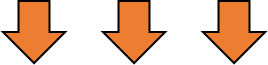

In [18]:
parame = ['turb', 'cond', 'pH']
# # We are going to use 3 splits: 0 (maybe 1), 2.5 and 5%
# threshold_range_relative = [0.1, 0.025, 0.005]
# threshold_range = [threshold_range_relative, threshold_range_relative, threshold_range_relative]
# if normalized == False:
#     threshold_range_original = []
#     for par in parame:     
#         threshold_range_original.append([scale_threshold_back(thr, par, info=True) for thr in threshold_range[0]])
#     threshold_range = threshold_range_original

# Percentiles 
threshold_r = [30]

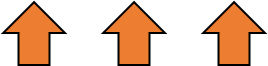

In [19]:
def range_variance_visual_assessment(lag, gap, percentile_threshold, param):
    # Converting percentiles into threshold value for a case
    thresholds = percentile_into_threshold(lag, gap, param, percentile_threshold)
    print(f'Threshold for this case and this percentile ({percentile_threshold}%) is {thresholds[0]}\n\n')
    # Create a figure and a 2x4 grid of subplots
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()  # Flatten the array of axes for easy iteration

    number_of_instances = [(len(multipar_test_dataset_list[eve][predefined_max_lag_size: -(predefined_max_lag_size)]) - 2 * lag) - gap + 1 for eve in range(len(multipar_test_dataset_list))]
    
    for eve in range(len(multipar_test_dataset_list)):
        # Getting range variance 
        eve_inst_array = instance_event_collection(lag, gap, multipar_test_dataset_list, param, base=True)[eve]
        range_variance = clustering_instances_event(eve_inst_array, number_of_instances[eve], thresholds)
    
        # Example data
        categories = np.arange(number_of_instances[eve])
        values = range_variance[1].reshape(1, len(range_variance[1]))[0]

        # Defining condition
        condition = np.array(values) < thresholds[0]
        
        # Define colors based on condition
        colors = np.where(condition, 'red', 'green')
        
        # Plot the data
        ax = axes[eve]
        ax.bar(categories, values, color=colors)
        ax.axhline(y=thresholds[0], color='r', linestyle='--')
        
        # Add a legend
        ax.legend(handles=[plt.Line2D([0], [0], color='green', lw=4, label=f'RMSE >= {thresholds[0]:.03f}'),
                           plt.Line2D([0], [0], color='red', lw=4, label=f'RMSE < {thresholds[0]:.03f}')],
                           loc='upper right')
    

        ax.set_xlim(0, max(number_of_instances))
        
        # Add labels and title
        ax.set_title(f'Test dataset, event {eve+1}')
        ax.set_xlabel('Instance')
        ax.set_ylabel(f'RMSE for {percentile_threshold} % percentile')
        # ax.set_ylim(0, 0.2)

    # Add a common title for the entire figure
    fig.suptitle(f'Variance Visual Assessment for $\Delta T_{{g}}$ = {gap/2} min\n', fontsize=16)
    
    # Adjust layout to prevent overlap
    plt.tight_layout()
    
    # Display the figure
    plt.show()

In [20]:
# Uncomment to visualize if needed

# range_variance_visual_assessment(20, 20, threshold_r[0], parame[0])

In [21]:
# Function to normalize values
def normalize_list(values):
    min_val = min(values)
    max_val = max(values)
    return [(value - min_val) / (max_val - min_val) for value in values]

def qualities_instance_collection(inst_array, n_of_instances):
    # Collection of all instances for this event
    list_of_instances = [inst_array[instance][0] for instance in range(n_of_instances)]

    instance_list_range, instance_list_mean, instance_list_median = [], [], []
    for instance in list_of_instances:
        instance_range = np.ptp(instance)
        instance_mean = np.mean(instance)
        instance_median = np.median(instance)
        instance_list_range.append(instance_range)
        instance_list_mean.append(instance_mean)
        instance_list_median.append(instance_median)

    
                              
    instance_list_range = np.array(instance_list_range).reshape(-1, 1)
    instance_list_mean = np.array(instance_list_mean).reshape(-1, 1)
    instance_list_median = np.array(instance_list_median).reshape(-1, 1)

    return instance_list_range, instance_list_mean, instance_list_median


def calculate_group_averages(numbers, num_groups=100):
    """
    Splits the list of numbers into `num_groups` groups and returns the average of each group.

    Parameters:
    - numbers: List or array of numbers to be split into groups.
    - num_groups: The number of groups to split the numbers into (default is 100).

    Returns:
    - List of averages for each group.
    """
    if isinstance(numbers, list):
        numbers = np.array(numbers)
    
    # Calculate the group size and the remainder excluding nan values
    group_size = len(numbers[~np.isnan(numbers)]) // num_groups
    remainder = len(numbers[~np.isnan(numbers)]) % num_groups

    # List to store the averages
    averages = []
    
    start_idx = 0

    for i in range(num_groups):
        # Add an extra element to the first 'remainder' groups
        end_idx = start_idx + group_size + (1 if i < remainder else 0)
        group = numbers[start_idx:end_idx]
        averages.append(np.nanmean(group))  # Compute and store the average of the current group
        start_idx = end_idx  # Move to the next group

    return averages


def weights_from_RMSE(lag, gap, param):
    combined_RMSE = []
    for eve in range(len(multipar_test_dataset_list)):
        # Getting range variance 
        number_of_instances = (len(multipar_test_dataset_list[eve][predefined_max_lag_size: -(predefined_max_lag_size)]) - 2 * lag) - gap + 1
        eve_inst_array = instance_event_collection(lag, gap, multipar_test_dataset_list, param, base=True)[eve]
        # Collection of all instances for this event
        list_of_event_observations = [eve_inst_array[instance][0] for instance in range(number_of_instances)]
        list_of_event_lin_interp = [eve_inst_array[instance][1] for instance in range(number_of_instances)]

    
        event_list_RMSE = []
        # LR vs LI - uncomment needed
        # for instance in list_of_event_observations:
        #     # Fit linear model
        #     X = np.arange(len(instance)).reshape(-1, 1)
        #     model = LinearRegression()
        #     model.fit(X, instance)
        #     # Calculate trend
        #     trend = model.predict(X)
        #     rel_res = (instance - trend)/trend*100
        
        for obs, LI in zip(list_of_event_observations, list_of_event_lin_interp):
            RMSE = root_mean_squared_error(obs, LI)
            event_list_RMSE.append(RMSE)
    
        # Combining all events into one list to find and return a value of a threshold
        combined_RMSE = combined_RMSE + event_list_RMSE
    # Sort in ascending order
    sorted_RMSE = sorted(combined_RMSE)

    # Finding averages of every 1% of values
    sorted_100_RMSE = np.array(calculate_group_averages(sorted_RMSE, num_groups=100))

    # Max
    max_RMSE = max(sorted_100_RMSE)
    # Min
    min_RMSE = min(sorted_100_RMSE)
    # Weights from non-linearity transformed into linearity
    weights = (max_RMSE + min_RMSE - sorted_100_RMSE)/sum(max_RMSE + min_RMSE - sorted_100_RMSE)

    return sorted_100_RMSE, weights

In [22]:
def get_variable_name(var, scope=globals()):
    return [name for name in scope if scope[name] is var][0]

def save_to_pkl(list_name, folder):
    # Save the list
    with open(f'{home_dir}/results/temp_files/{folder}/{get_variable_name(list_name)}.pkl', 'wb') as f:
        pickle.dump(list_name, f)

def load_from_pkl(list_name_str, folder):
    # Load it back later
    with open(f'{home_dir}/results/temp_files/{folder}/{list_name_str}', 'rb') as f:
        loaded_list = pickle.load(f)
    return loaded_list

In [23]:
# %%time
# turb_RMSE = {'5_20': weights_from_RMSE(5, 20, 'turb'), 
#             '10_20': weights_from_RMSE(10, 20, 'turb'),
#             '20_20': weights_from_RMSE(20, 20, 'turb'),
#             '5_40': weights_from_RMSE(5, 40, 'turb'), 
#             '10_40': weights_from_RMSE(10, 40, 'turb'),
#             '20_40': weights_from_RMSE(20, 40, 'turb'),
#             '5_60': weights_from_RMSE(5, 60, 'turb'), 
#             '10_60': weights_from_RMSE(10, 60, 'turb'),
#             '20_60': weights_from_RMSE(20, 60, 'turb')}

# save_to_pkl(turb_RMSE, 'RMSE_LI_weights')

In [24]:
# %%time
# cond_RMSE = {'5_20': weights_from_RMSE(5, 20, 'cond'), 
#             '10_20': weights_from_RMSE(10, 20, 'cond'),
#             '20_20': weights_from_RMSE(20, 20, 'cond'),
#             '5_40': weights_from_RMSE(5, 40, 'cond'), 
#             '10_40': weights_from_RMSE(10, 40, 'cond'),
#             '20_40': weights_from_RMSE(20, 40, 'cond'),
#             '5_60': weights_from_RMSE(5, 60, 'cond'), 
#             '10_60': weights_from_RMSE(10, 60, 'cond'),
#             '20_60': weights_from_RMSE(20, 60, 'cond')}

# save_to_pkl(cond_RMSE, 'RMSE_LI_weights')

In [25]:
# %%time
# pH_RMSE = {'5_20': weights_from_RMSE(5, 20, 'pH'), 
#             '10_20': weights_from_RMSE(10, 20, 'pH'),
#             '20_20': weights_from_RMSE(20, 20, 'pH'),
#             '5_40': weights_from_RMSE(5, 40, 'pH'), 
#             '10_40': weights_from_RMSE(10, 40, 'pH'),
#             '20_40': weights_from_RMSE(20, 40, 'pH'),
#             '5_60': weights_from_RMSE(5, 60, 'pH'), 
#             '10_60': weights_from_RMSE(10, 60, 'pH'),
#             '20_60': weights_from_RMSE(20, 60, 'pH')}

# save_to_pkl(pH_RMSE, 'RMSE_LI_weights')

In [26]:
turb_RMSE = load_from_pkl('turb_RMSE.pkl', 'RMSE_LI_weights')
cond_RMSE = load_from_pkl('cond_RMSE.pkl', 'RMSE_LI_weights')
pH_RMSE = load_from_pkl('pH_RMSE.pkl', 'RMSE_LI_weights')

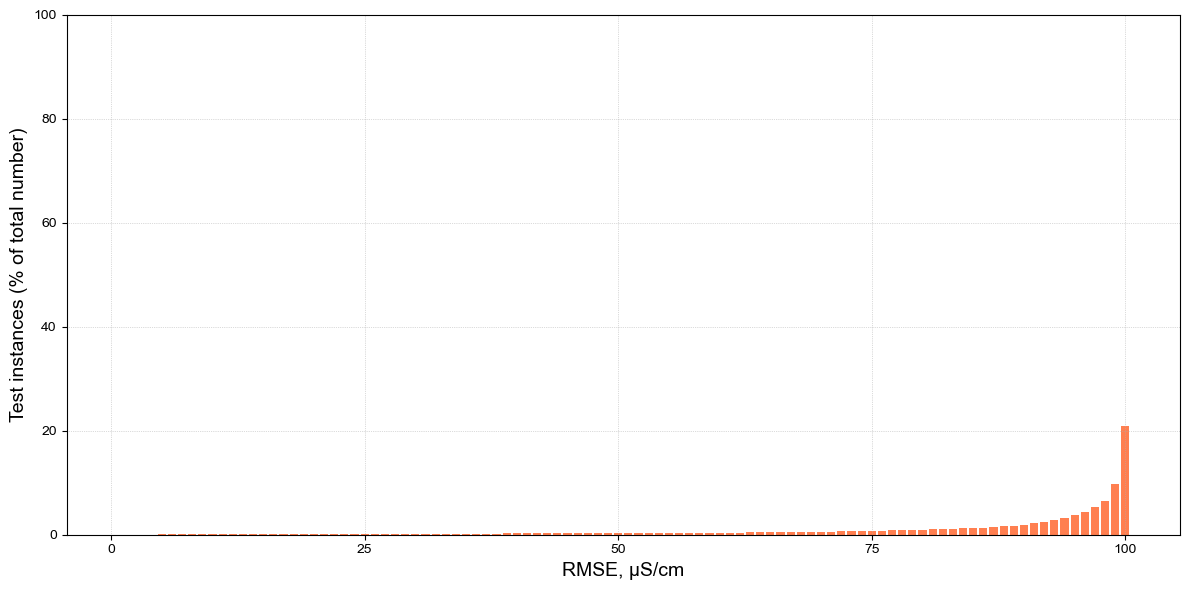

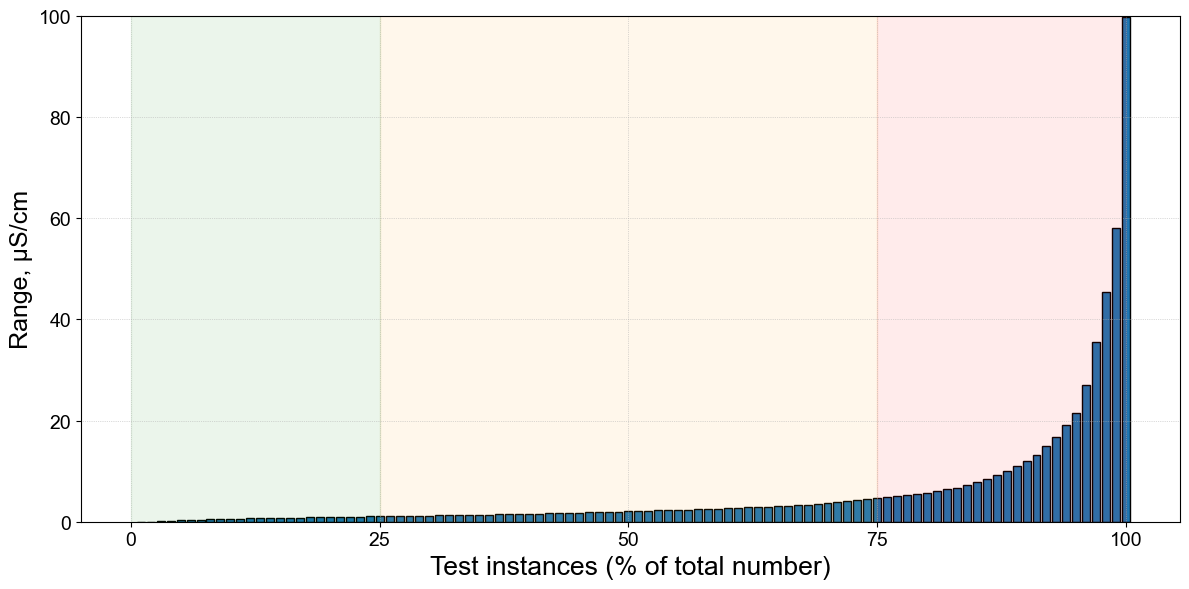

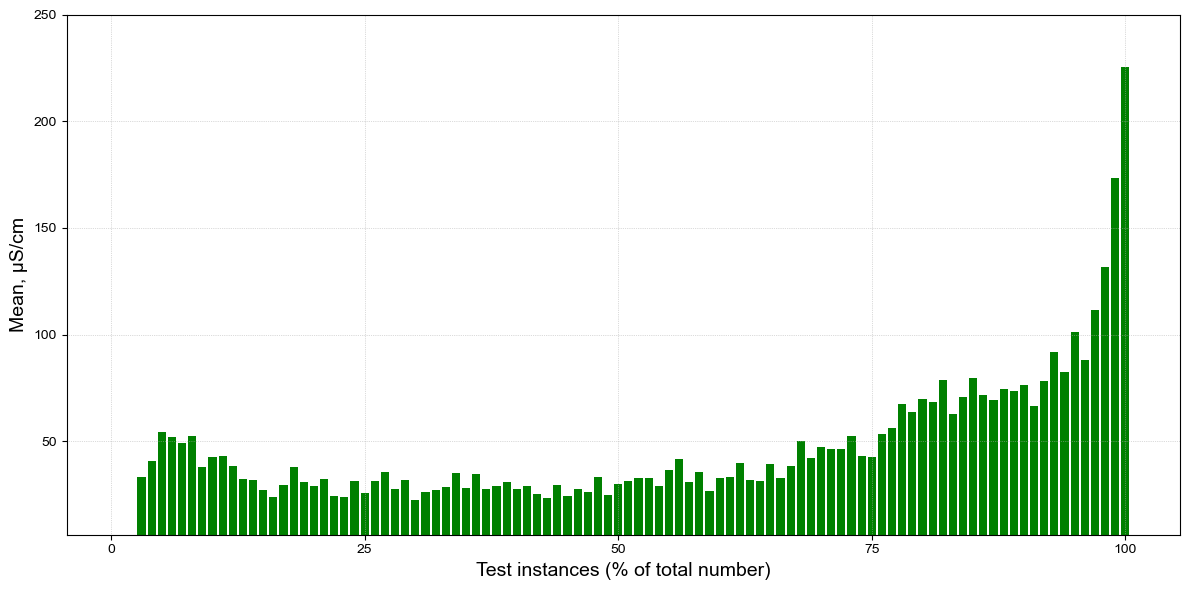

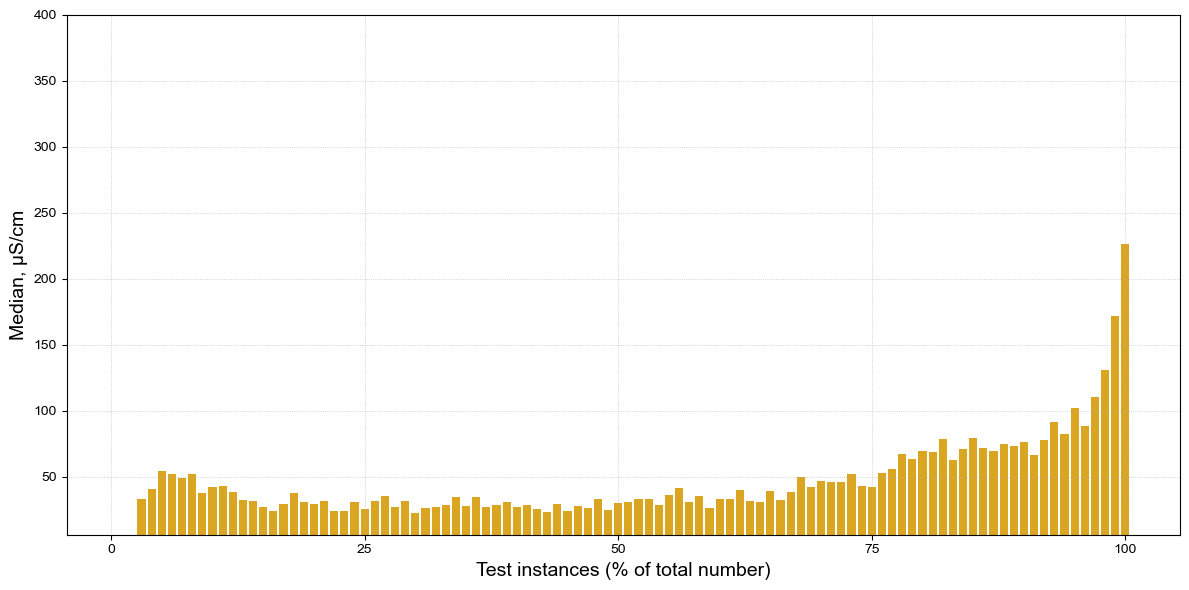

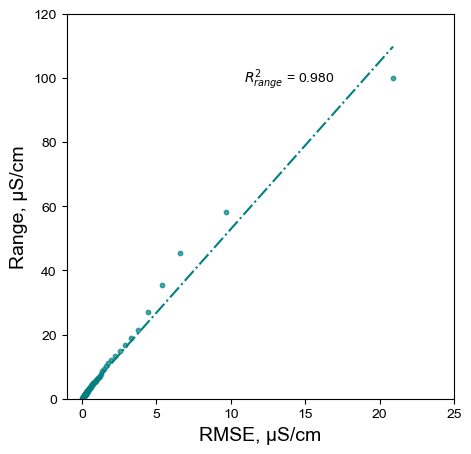

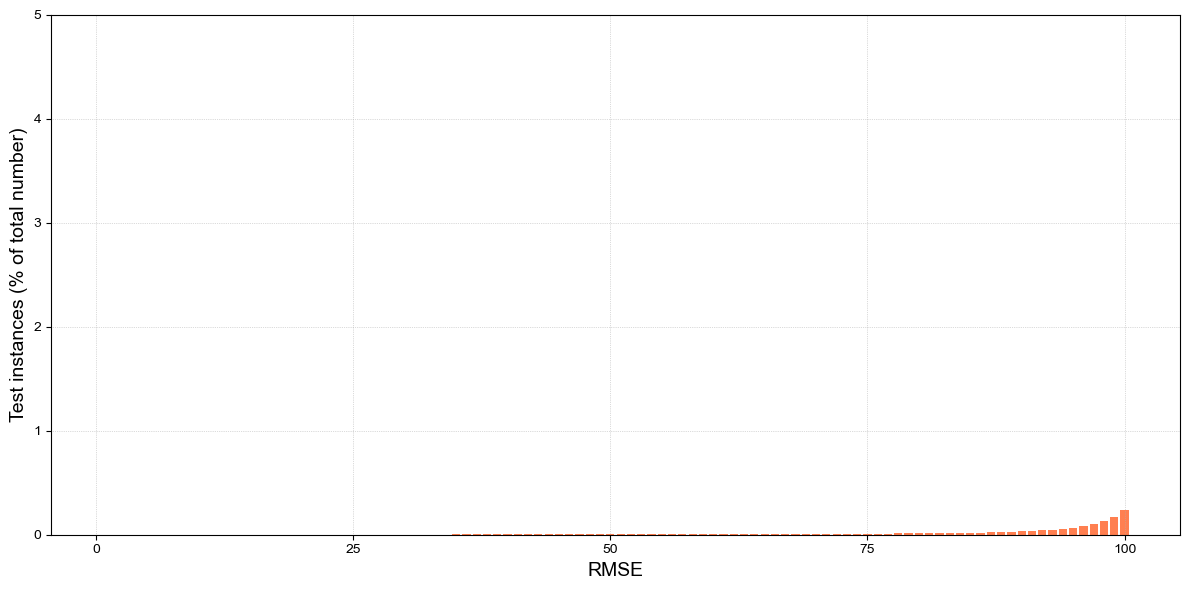

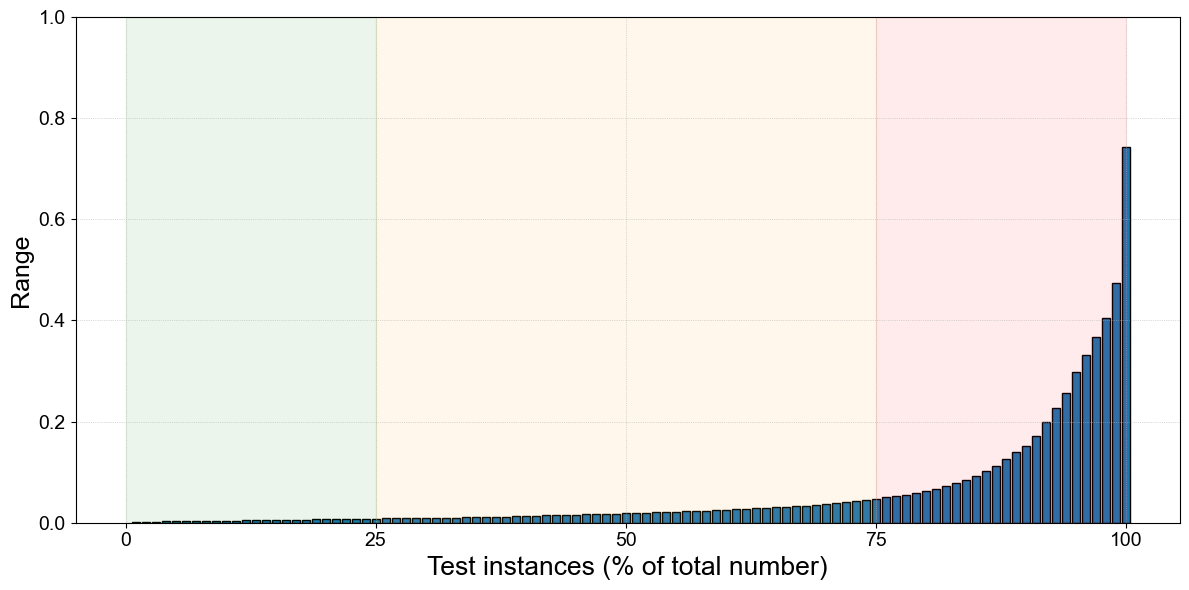

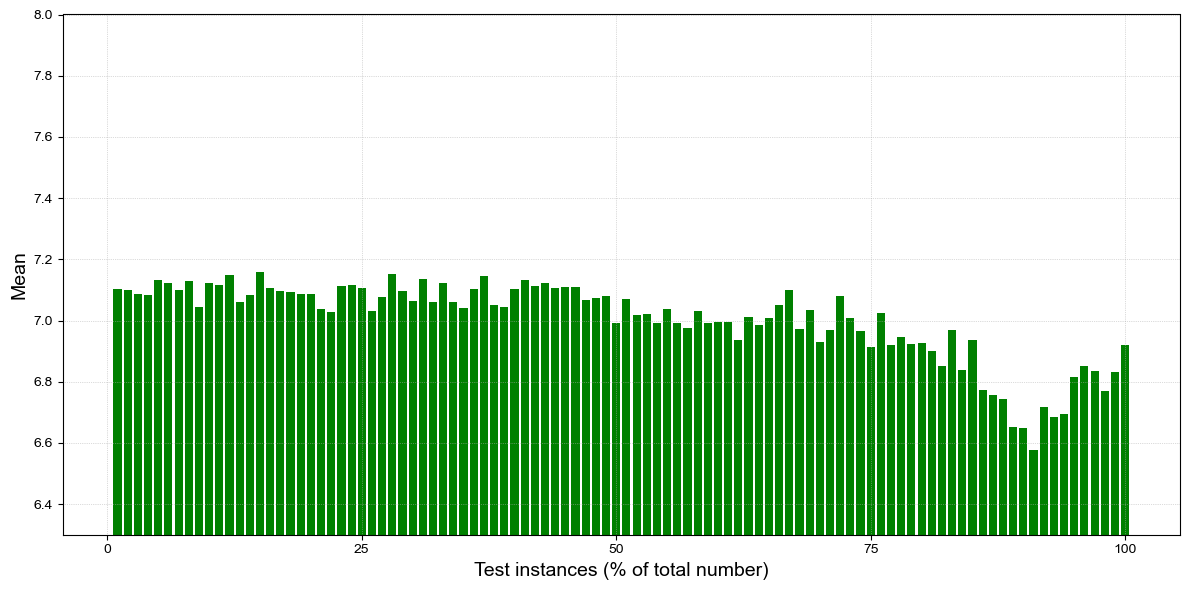

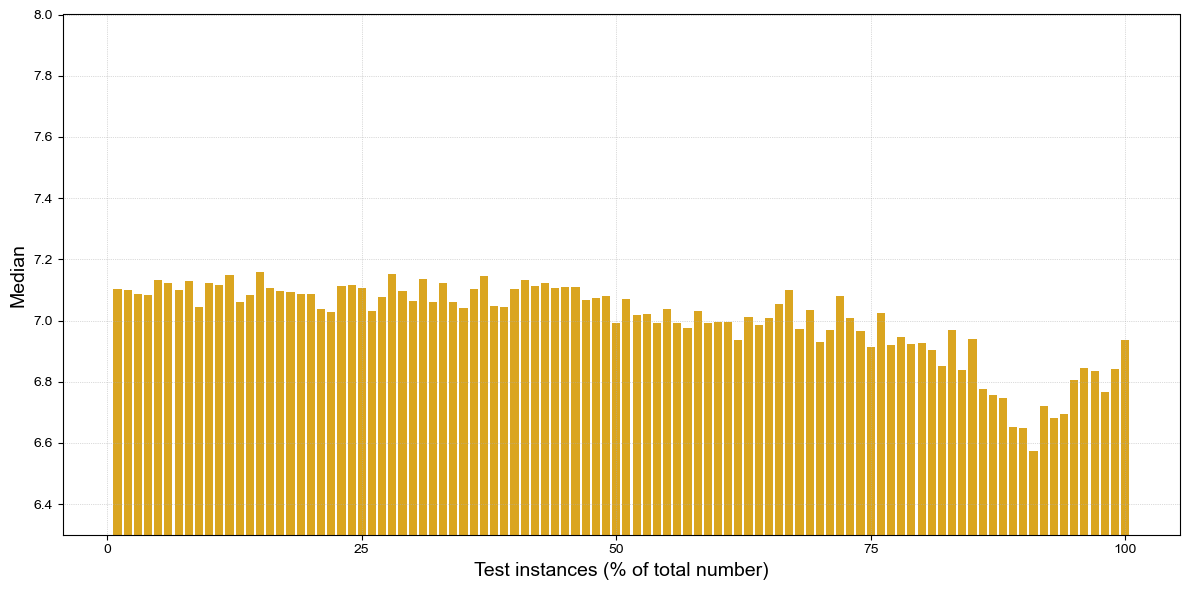

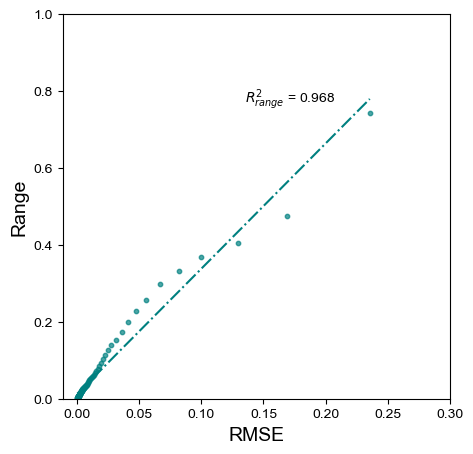

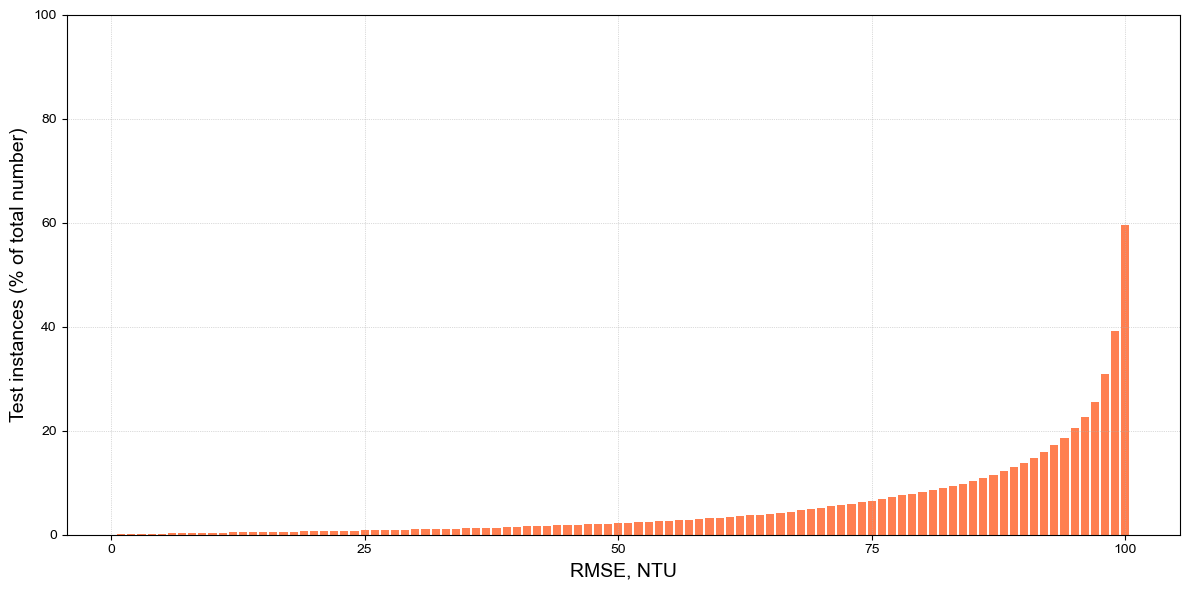

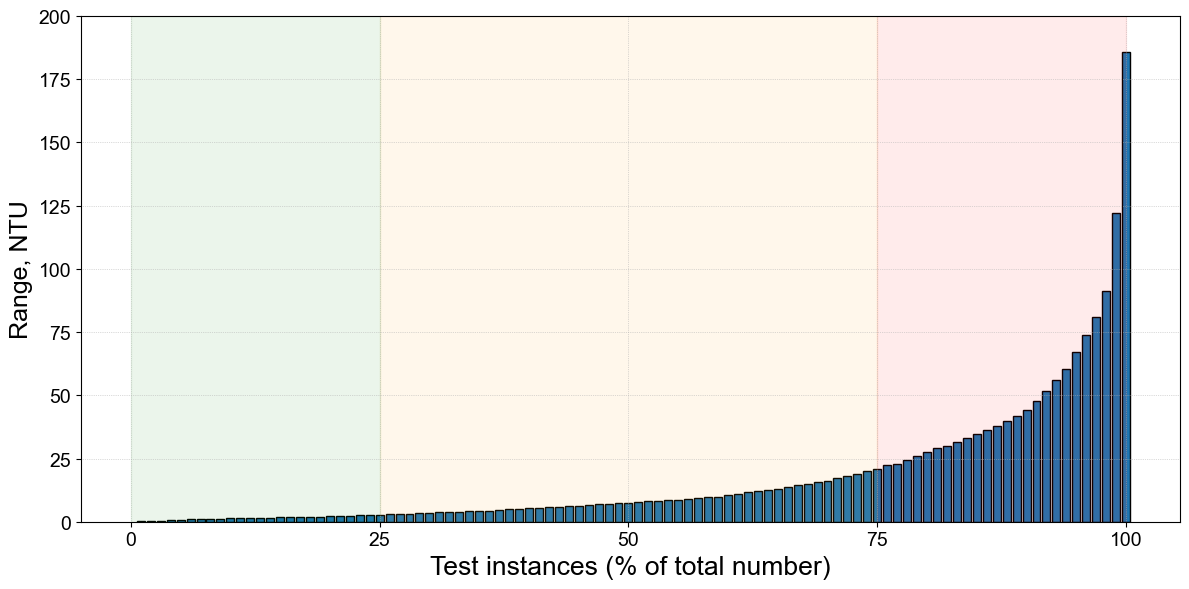

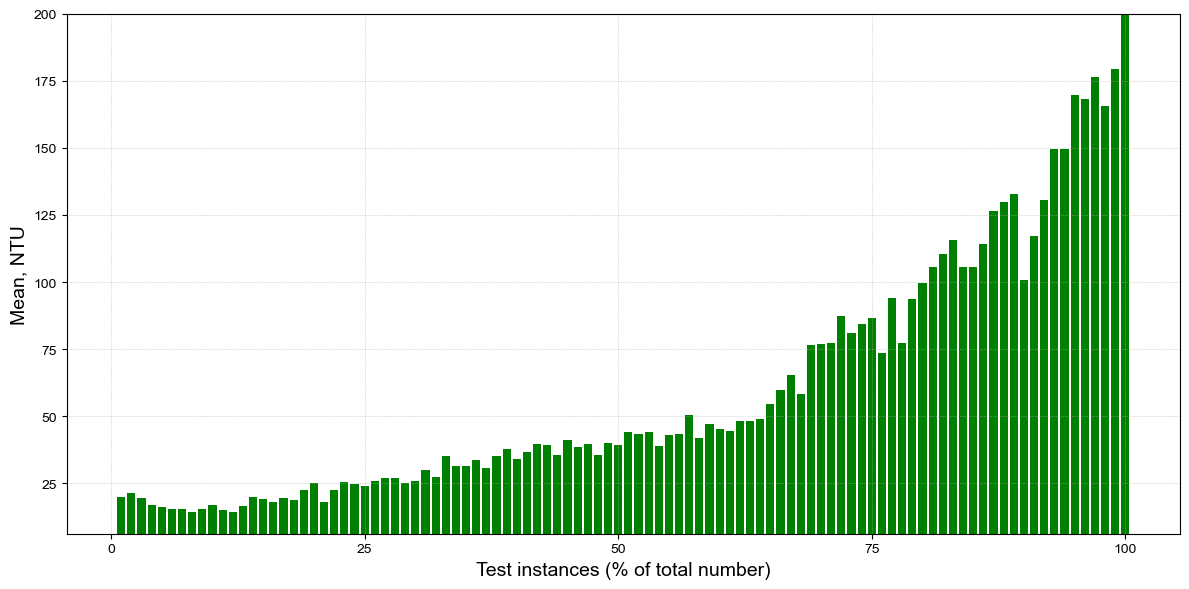

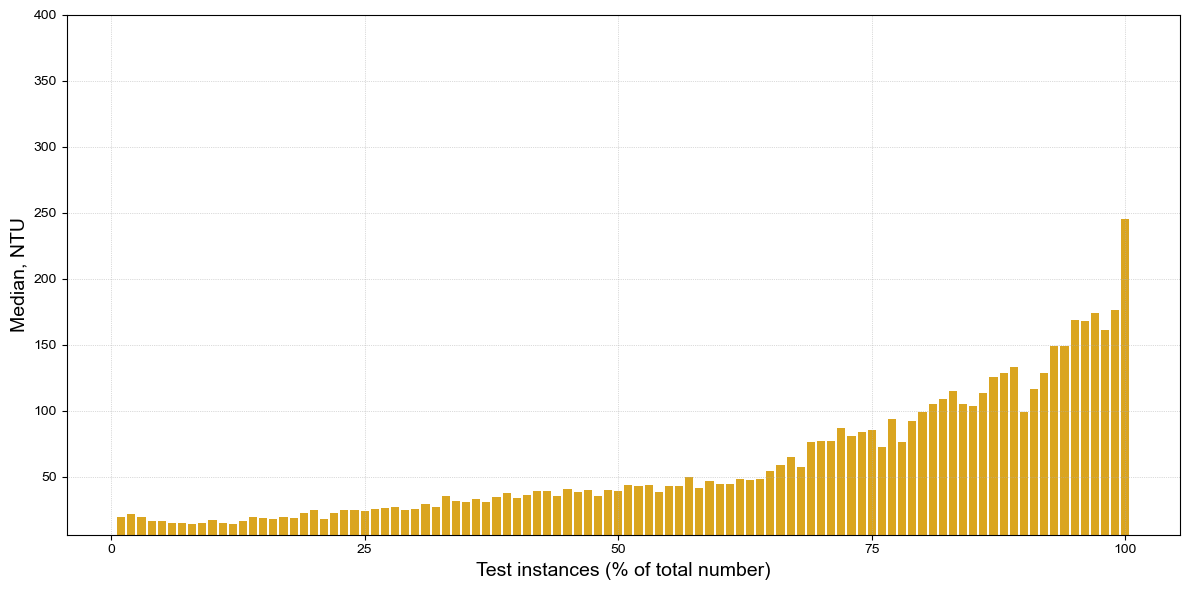

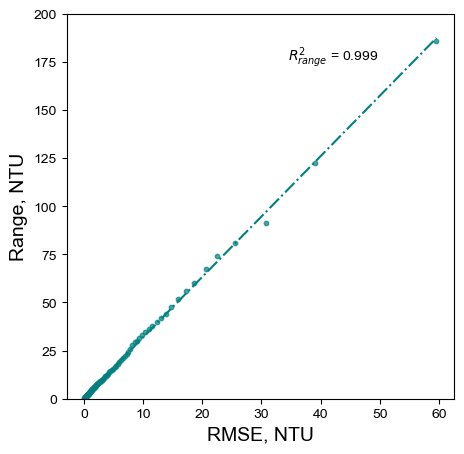

In [27]:
def instances_collection_visualization(lag, gap, param):


    number_of_instances = [
        (len(multipar_test_dataset_list[eve][predefined_max_lag_size:-(predefined_max_lag_size)]) - 2 * lag) - gap + 1 
        for eve in range(len(multipar_test_dataset_list))
    ]

    # Getting range variance 
    eve_inst_array = instance_event_collection(lag, gap, multipar_test_dataset_list, param, base=True)

    # Merging events into one collection of instances
    all_instances = []
    for event in eve_inst_array:
        all_instances.extend(event)

    
    # Range between RMSE equivalent of 0 and 100 percent of data thresholds
    RMSE_all_instances = clustering_instances_event(all_instances, len(all_instances), (0, 1000))
    ptp_all_instances, min_all_instances, max_all_instances = qualities_instance_collection(all_instances, len(all_instances))

    categories = np.arange(1, 101)
    RMSE_all_instances_sorted = np.sort(RMSE_all_instances[1].reshape(1, len(RMSE_all_instances[1]))[0])
    RMSE_all_instances_sorted_mean = calculate_group_averages(RMSE_all_instances_sorted)
    
    # Sort the values array and get the sorting indices
    sorted_indices = np.argsort(RMSE_all_instances[1].reshape(1, len(RMSE_all_instances[1]))[0])
    
    # Apply the sorted indices to the other arrays
    # sorted_ptp_all_instances = ptp_all_instances[sorted_indices].reshape(1, len(ptp_all_instances))[0]
    # I manually sort it for the visualization
    sorted_ptp_all_instances = np.sort(ptp_all_instances.reshape(1, len(ptp_all_instances)))[0]











    
    sorted_min_all_instances = min_all_instances[sorted_indices].reshape(1, len(min_all_instances))[0]
    sorted_max_all_instances = max_all_instances[sorted_indices].reshape(1, len(max_all_instances))[0]

    sorted_ptp_all_instances_mean = calculate_group_averages(sorted_ptp_all_instances)
    sorted_min_all_instances_mean = calculate_group_averages(sorted_min_all_instances)
    sorted_max_all_instances_mean = calculate_group_averages(sorted_max_all_instances)



    
    if param == 'turb':
        unit = ', NTU'
        # Ponsel turbidity sensor has 5% of a measurement uncertainty
        delta = 0.05
        analytical_uncertainty = [inst*delta for inst in sorted_max_all_instances_mean]
        # RMSE_all_instances_sorted_mean = turb_RMSE[f'{lag}_{gap}'][0]
    elif param == 'cond':
        unit = ', μS/cm'
        # Instrumental uncertainty
        # Ponsel conductivity sensor has uncertainty based on range
        delta = [0.01*200, 0.01*2000, 0.01*20000, 0.01*200000]
        analytical_uncertainty = []
        for inst in sorted_max_all_instances_mean:
            if inst < 200:
                anal_unc = delta[0]
            elif inst < 2000:
                anal_unc = delta[1]
            elif inst < 20000:
                anal_unc = delta[2]
            elif inst < 200000:
                anal_unc = delta[3]
            analytical_uncertainty.append(anal_unc)
        # It is only the last value that is 20 mkS/cm
        # analytical_uncertainty = [delta[0]]*100


    
        # RMSE_all_instances_sorted_mean = cond_RMSE[f'{lag}_{gap}'][0]
    elif param == 'pH':
        unit = ''
        # Ponsel pH sensor has 0.1 absolute uncertainty
        delta = 0.1
        # RMSE_all_instances_sorted_mean = pH_RMSE[f'{lag}_{gap}'][0]
        analytical_uncertainty = [delta]*100
    

    for i_char, characteristic in enumerate([RMSE_all_instances_sorted_mean, sorted_ptp_all_instances_mean, sorted_min_all_instances_mean, sorted_max_all_instances_mean]):    
        if i_char == 0:
            char_name = 'RMSE'
            color = 'coral'
            if param == 'turb':
                limit = 100
            elif param == 'cond':
                limit = 100
            elif param == 'pH':
                limit = 5
        elif i_char == 1:
            char_name = 'Range'
            color = '#1f77b4'
            if param == 'turb':
                limit = 200
            elif param == 'cond':
                limit = 100
            elif param == 'pH':
                limit = 1
        elif i_char == 2:
            char_name = 'Mean'
            color = 'green'
            if param == 'turb':
                limit = 200
            elif param == 'cond':
                limit = 250
            elif param == 'pH':
                limit = 8
        elif i_char == 3:
            char_name = 'Median'
            color = 'goldenrod'
            if param == 'turb':
                limit = 400
            elif param == 'cond':
                limit = 400
            elif param == 'pH':
                limit = 8
            
        # Create a figure and a 2x4 grid of subplots
        fig, axes = plt.subplots(1, 1, figsize=(12, 6))
        axes.grid(True, which='both', axis='both', linestyle=':', linewidth=0.5, alpha=0.9)
        axes.set_xticks([0, 25, 50, 75, 100])
        # Plot the data with a single color
        if i_char == 0:
            axes.bar(categories, characteristic, color=color)
            axes.set_ylim(top=limit)
            axes.set_ylabel('Test instances (% of total number)', fontsize=14)
            axes.set_xlabel(f'{char_name}{unit}', fontsize=14)
        elif i_char == 1:
            # axes.yaxis.tick_right()  # Move ticks to the right
            # axes.yaxis.set_label_position("right")  # Move the label to the right
            axes.bar(categories, characteristic, color=color, edgecolor = 'k')
            axes.set_ylim(top=limit)
            # Add labels and title
            axes.set_xlabel('Test instances (% of total number)', fontsize=19)
            axes.set_ylabel(f'{char_name}{unit}', fontsize=18)
            axes.tick_params(axis='both', labelsize=14)
            axes.axvspan(0, 25, color='green', alpha=0.08)
            axes.axvspan(25, 75, color='orange', alpha=0.08)
            axes.axvspan(75, 100, color='red', alpha=0.08)
            # Add a common title for the entire figure
            # axes.text(50, 190, f'$\Delta T_{{g}}$ = {int(gap/2)} min, $\Delta T_{{c}}$ = {int(lag)} min', ha='center', va = 'top', fontsize = 18, bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor='white'))




        
        else:
            axes.bar(categories, characteristic, color=color)
            axes.set_ylim(bottom = 6.3, top=limit)
            # Add labels and title
            axes.set_xlabel('Test instances (% of total number)', fontsize=14)
            axes.set_ylabel(f'{char_name}{unit}', fontsize=14)


    
        # Vertically mirror the plot by inverting the y-axis
        # axes.invert_yaxis()
        
        # Add a common title for the entire figure
        # fig.suptitle(f'$\Delta T_{{g}}$ = {int(gap/2)} min, $\Delta T_{{c}}$ = {int(lag)} min', fontsize=14)
    
        # Adjust layout to prevent overlap
        plt.tight_layout()
        # Save the plot
        if i_char == 1:
            plt.savefig(r"H:\Work\Writing in progress\3. ML paper\Draft\Figures\Difficulty level\Bottom_right_subplot.png", dpi=300, bbox_inches="tight")
        # Display the figure
        plt.show()


    
    # Create a figure and a 1x1 grid of subplots
    fig, ax1 = plt.subplots(1, 1, figsize=(5, 5))

    # Create a twin axis for another parameter
    # ax2 = ax1.twinx()
    
    # Scatter plots with smaller marker size and labels for legend
    # ax1.scatter(RMSE_all_instances_sorted_mean, sorted_max_all_instances_mean, s=10, label='Max', alpha=0.7, color='goldenrod')
    ax1.scatter(RMSE_all_instances_sorted_mean, sorted_ptp_all_instances_mean, s=10, label='Range', alpha=0.7, color='teal')
    # ax1.scatter(RMSE_all_instances_sorted_mean, sorted_min_all_instances_mean, s=10, label='Min', alpha=0.7, color='goldenrod')

    
    # Trend lines (using polyfit to get a linear trend line)
    def plot_trend(x_data, y_data, ax, label, color):
        if label == 'Range':
            y = f'$y_{{range}}$'
            if param == 'turb':
                horiz_shift = -25
                vert_shift = -10
            elif param == 'cond':
                horiz_shift = -10
                vert_shift = -10
            elif param == 'pH':
                horiz_shift = -0.1
                vert_shift = 0
            r_und = f'R^2_{{range}}'

        # elif label == 'Max' or label == 'Min':
        #     y = f'$y_{{max}}$'
        #     if param == 'turb':
        #         horiz_shift = 0
        #         vert_shift = 0
        #     elif param == 'cond':
        #         horiz_shift = -1.5
        #         vert_shift = -80
        #     elif param == 'pH':
        #         horiz_shift = 0
        #         vert_shift = 0
        #     r_und = f'R^2_{{max}}'

        
        # Perform linear fit (degree 1)
        coeffs = np.polyfit(x_data, y_data, 1)
        trend_line = np.polyval(coeffs, x_data)
        
        # Plot the trend line
        ax.plot(x_data, trend_line, label='d', linestyle='-.', color=color)
    
        # Calculate R²
        y_pred = np.polyval(coeffs, x_data)
        ss_tot = np.sum((y_data - np.mean(y_data))**2)
        ss_res = np.sum((y_data - y_pred)**2)
        r2 = 1 - (ss_res / ss_tot)
    
        # Get the slope (m) and intercept (b) from the polyfit coefficients
        m, b = coeffs


        
        # formula = f'{y} = {m:.2f} · RMSE + {b:.2f}, ${r_und}$ = {r2:.2f}'
        formula = f'${r_und}$ = {r2:.3f}'
    
        # Calculate the x and y coordinates of the end of the trend line
        x_end = x_data[-1]
        y_end = np.polyval(coeffs, x_end)
    
        # Add the formula and R² value next to the end of the trend line
        ax.text(x_end + horiz_shift, y_end + vert_shift, formula, fontsize=10, ha='left', va='center')

        # ax1.legend()

        ax.set_ylim(0)
    if param == 'turb':
        # ax1.set_ylim(top=500)
        ax1.set_ylim(top=200)
        plt.xlim()
    elif param == 'cond':
        # ax1.set_ylim(top=350)
        ax1.set_ylim(top=120)
        plt.xlim(right=25)
    elif param == 'pH':
        ax1.set_ylim(top = 1)
        # ax1.set_ylim()
        plt.xlim(right = 0.3)



    # Plot trend lines for each set
    # plot_trend(RMSE_all_instances_sorted_mean, sorted_max_all_instances_mean, ax1, 'Max', color='goldenrod')
    plot_trend(RMSE_all_instances_sorted_mean, sorted_ptp_all_instances_mean, ax1, 'Range', color='teal')
    # plot_trend(RMSE_all_instances_sorted_mean, sorted_min_all_instances_mean, ax1, 'Min', color='goldenrod')

    
    # Adding axis labels and title
    ax1.set_xlabel(f'RMSE{unit}', fontsize = 14)
    # ax1.set_ylabel(f'Max{unit}', fontsize = 14)
    ax1.set_ylabel(f'Range{unit}', fontsize = 14)
    
    # Displaying legend
    # plt.gca().legend()
    
    # Display the figure
    plt.show()
    
    return analytical_uncertainty



analytical_uncertainty_cond = instances_collection_visualization(5, 20, parame[1])
analytical_uncertainty_pH = instances_collection_visualization(5, 20, parame[2])
analytical_uncertainty_turb = instances_collection_visualization(5, 20, parame[0])
# instances_collection_visualization(10, 20, parame[2])
# instances_collection_visualization(20, 20, parame[2])
# instances_collection_visualization(5, 40, parame[2])
# instances_collection_visualization(10, 40, parame[2])
# instances_collection_visualization(20, 40, parame[2])
# instances_collection_visualization(5, 60, parame[2])
# instances_collection_visualization(10, 60, parame[2])
# instances_collection_visualization(20, 60, parame[2])

In [28]:
# Average R2
R2_turb = [0.999, 0.999, 0.999, 0.995, 0.995, 0.995, 0.992, 0.991, 0.991]
print('Turbidity:', round(np.mean(R2_turb), 3))
R2_cond = [0.980, 0.981, 0.982, 0.969, 0.968, 0.979, 0.983, 0.985, 0.989]
print('Conductivity:', round(np.mean(R2_cond), 3))
R2_pH = [0.968, 0.971, 0.974, 0.973, 0.977, 0.979, 0.978, 0.979, 0.982]
print('pH:', round(np.mean(R2_pH), 3))

Turbidity: 0.995
Conductivity: 0.98
pH: 0.976


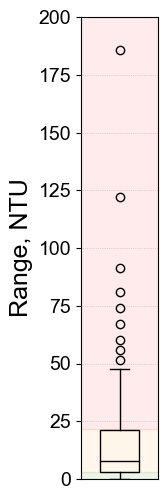

In [29]:
def boxplot_for_ptp(lag, gap, param):


    number_of_instances = [
        (len(multipar_test_dataset_list[eve][predefined_max_lag_size:-(predefined_max_lag_size)]) - 2 * lag) - gap + 1 
        for eve in range(len(multipar_test_dataset_list))
    ]

    # Getting range variance 
    eve_inst_array = instance_event_collection(lag, gap, multipar_test_dataset_list, param, base=True)

    # Merging events into one collection of instances
    all_instances = []
    for event in eve_inst_array:
        all_instances.extend(event)

    
    # Range between RMSE equivalent of 0 and 100 percent of data thresholds
    ptp_all_instances, min_all_instances, max_all_instances = qualities_instance_collection(all_instances, len(all_instances))
    
    # Apply the sorted indices to the other arrays
    sorted_ptp_all_instances = np.sort(ptp_all_instances.reshape(1, len(ptp_all_instances)))[0]
    sorted_ptp_all_instances_mean = calculate_group_averages(sorted_ptp_all_instances)


    
    # Create a figure and axis
    fig, ax = plt.subplots(figsize=(1, 6))
    
    # Create the box plot
    ax.boxplot(sorted_ptp_all_instances_mean, patch_artist=True, boxprops=dict(facecolor=(1, 0.05, 0, 0.005)), widths=0.5, medianprops={'color': 'black'})
    
    ax.axhspan(0, 3, color='green', alpha=0.08)
    ax.axhspan(3, 21.5, color='orange', alpha=0.08)
    ax.axhspan(21.5, 200, color='red', alpha=0.08)
    
    # Customize labels and title
    ax.set_xticks([])
    ax.tick_params(axis='both', labelsize=14)
    ax.set_ylabel("Range, NTU", fontsize = 18)
    ax.set_ylim(bottom = 0, top = 200)
    ax.grid(True, which='both', axis='both', linestyle=':', linewidth=0.5, alpha=0.9)
    
    # Save the plot
    # plt.savefig(r"H:\Work\Writing in progress\3. ML paper\Draft\Figures\Difficulty level\Bottom_left_subplot.png", dpi=300, bbox_inches="tight")
    # Show the plot
    plt.show()

boxplot_for_ptp(5, 20, parame[0])

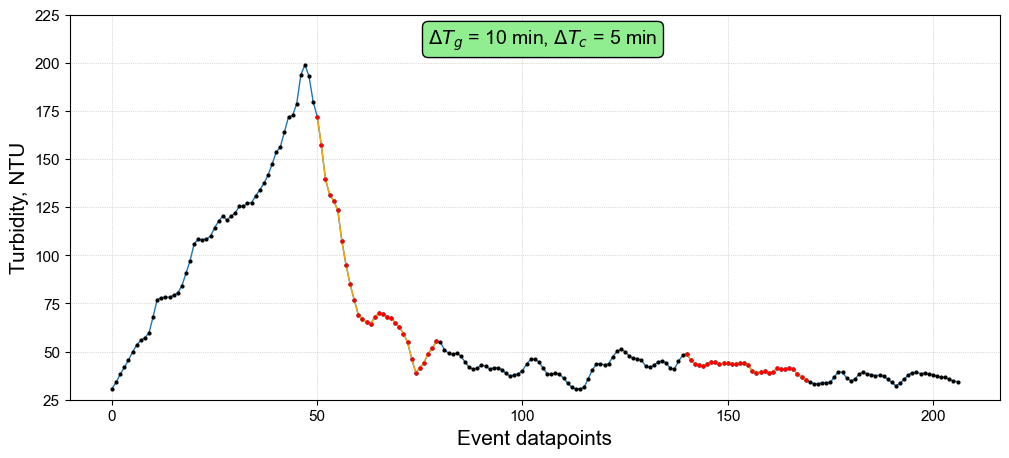

In [30]:
# Smallest poossible window size
window_size = 30

event_number = 5
para = 'Turbidity'

# Cutting off what is not supposed to be in the plot (shifting by a number of datapoints)
frontshift = 0
backshift = 270

# Mowing the window 1
shift1 = 50
shift2 = 140

parameters = {'Conductivity':0, 'Temperature':1, 'DO':2, 'Turbidity':3, 'pH':4, 'Flow':5, 'Cumulative discharge':6, 'Time since last rain':7, 'Time since rain started':8, 'Absolute gradient of flow l/s':9}
main_data = multipar_test_dataset_list[event_number][frontshift+90:-90-backshift, parameters[para]]
window1_data = main_data[shift1:window_size+shift1]
window2_data = main_data[shift2:window_size+shift2]



fig, ax = plt.subplots(figsize = (12, 5), dpi=100)

ax.plot(main_data, 
         marker = 'o', 
         markersize = 2, 
         markerfacecolor = 'k', 
         markeredgecolor = 'k', 
         linewidth = 1)


ax.plot(np.arange(shift1, len(window1_data)+shift1),
        window1_data,
        marker = 'o', 
        markersize = 2, 
        markerfacecolor = 'r', 
        markeredgecolor = 'r', 
        linewidth = 1,
        color = 'orange')



ax.plot(np.arange(shift2, len(window2_data)+shift2),
        window2_data,
        marker = 'o', 
        markersize = 2, 
        markerfacecolor = 'r', 
        markeredgecolor = 'r', 
        linewidth = 1,
        color = 'orange')

ax.set_ylabel("Turbidity, NTU", fontsize = 15)
ax.set_xlabel("Event datapoints", fontsize = 15)
ax.tick_params(axis='both', labelsize=11)
ax.grid(True, which='both', axis='both', linestyle=':', linewidth=0.5, alpha=0.9)
ax.set_ylim(bottom=25, top=225)
ax.text(105, 218.5, f'$\Delta T_{{g}}$ = 10 min, $\Delta T_{{c}}$ = 5 min', ha='center', va = 'top', bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor='#90EE90'), fontsize = 14)
# Save the plot
# plt.savefig(r"H:\Work\Writing in progress\3. ML paper\Draft\Figures\Difficulty level\Top_subplot.png", dpi=300, bbox_inches="tight")
plt.show()



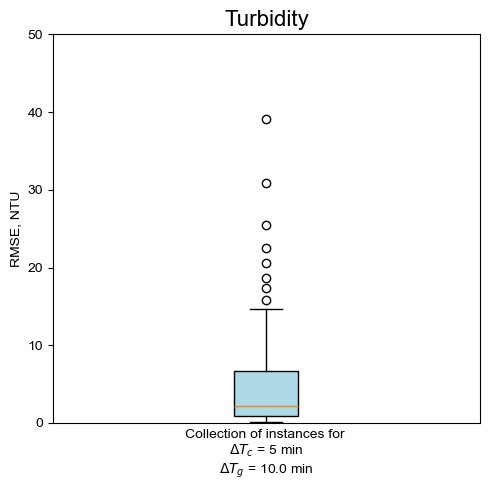

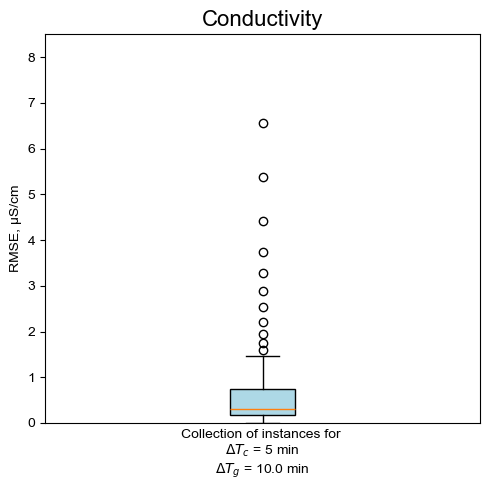

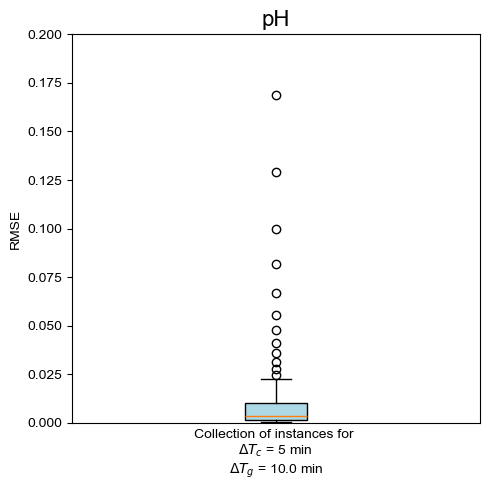

In [31]:
def RMSE_ranking_boxplot(lag, gap, param):


    # Calculate the number of instances for each event
    number_of_instances = [
        (len(multipar_test_dataset_list[eve][predefined_max_lag_size:-(predefined_max_lag_size)]) - 2 * lag) - gap + 1 
        for eve in range(len(multipar_test_dataset_list))
    ]

    # Gather data across all events
    eve_inst_array = instance_event_collection(lag, gap, multipar_test_dataset_list, param, base=True)
    
    # Combine all lists into one
    combined_data = []
    for sublist in eve_inst_array:
        combined_data.extend(sublist)

    # Range between RMSE equivalent of 0 and 100 percent of data thresholds
    range_variance = clustering_instances_event(combined_data, len(combined_data), (0, 10000))
    # All values
    values = np.sort(range_variance[1].reshape(1, len(range_variance[1]))[0])
    values_grouped = calculate_group_averages(values)

    # Create a figure for the box plot
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    

    ax.set_xlabel(f'Collection of instances for \n$\Delta T_{{c}}$ = {lag} min \n$\Delta T_{{g}}$ = {gap/2} min')
    if param == 'turb':
        parameter = 'Turbidity'
        unit = ', NTU'
        limit=50
        # values = turb_RMSE[f'{lag}_{gap}'][0]
    elif param == 'cond':
        unit = ', μS/cm'
        parameter = 'Conductivity'
        limit=8.5
        # values = cond_RMSE[f'{lag}_{gap}'][0]
    elif param == 'pH':
        unit = ''
        parameter = 'pH'
        limit=0.2
        # values = pH_RMSE[f'{lag}_{gap}'][0]
    ax.set_ylim(0, limit)
    ax.set_ylabel(f'RMSE{unit}')
    ax.set_title(f'{parameter}', fontsize=16)
    # Plot the box plot
    ax.boxplot(values_grouped, vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))

    # Add labels and title
    plt.xticks([])
    # Adjust layout and display the figure
    plt.tight_layout()
    plt.show()


RMSE_ranking_boxplot(5, 20, parame[0])
RMSE_ranking_boxplot(5, 20, parame[1])
RMSE_ranking_boxplot(5, 20, parame[2])

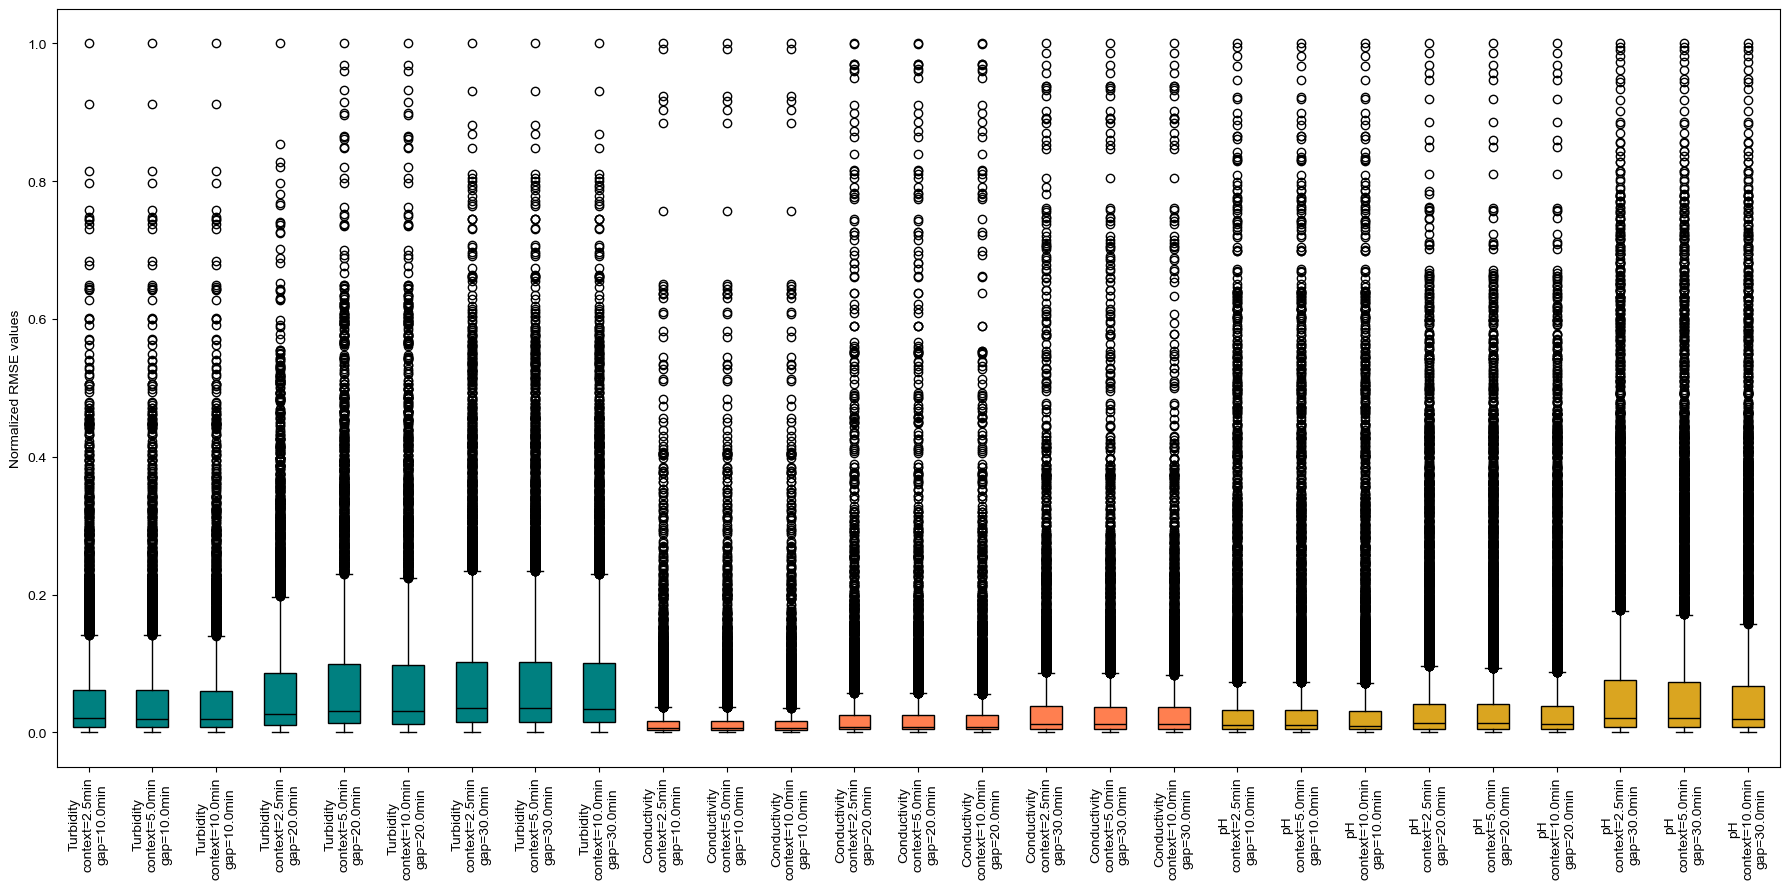

In [32]:
# List of gap and lag combinations
gap_values = [20, 40, 60]  # Replace with actual gap values
lag_values = [5, 10, 20]  # Replace with actual lag values

# List of parameters
parameters = ['turb', 'cond', 'pH']

# Create a figure with a single axis for the boxplots
fig, ax = plt.subplots(figsize=(18, 9))

# Initialize a list to hold all the data for the boxplot
all_values = []

# Initialize a list to hold the labels for each boxplot
labels = []

# Define the colors for each set of 9 boxplots
colors = ['teal'] * 9 + ['coral'] * 9 + ['goldenrod'] * 9

# Loop through each combination of parameter, gap, and lag
for i, param in enumerate(parameters):
    for j, gap in enumerate(gap_values):
        for k, lag in enumerate(lag_values):
            
            # Calculate the number of instances for each event
            number_of_instances = [
                (len(multipar_test_dataset_list[eve][predefined_max_lag_size:-(predefined_max_lag_size)]) - 2 * lag) - gap + 1 
                for eve in range(len(multipar_test_dataset_list))
            ]

            # Gather data across all events
            eve_inst_array = instance_event_collection(lag, gap, multipar_test_dataset_list, param, base=True)
            
            # Combine all lists into one
            combined_data = []
            for sublist in eve_inst_array:
                combined_data.extend(sublist)

            # Range between RMSE equivalent of 0 and 100 percent of data thresholds
            range_variance = clustering_instances_event(combined_data, len(combined_data), (0, 1000))
            values = np.sort(range_variance[1].reshape(1, len(range_variance[1]))[0])

            # Normalizing for correct visualization
            values = normalize_list(values)
            
            # Append the values for the boxplot
            all_values.append(values)

            # For naming
            if param == 'turb':
                parameter = 'Turbidity'
            elif param == 'cond':
                parameter = 'Conductivity'
            elif param == 'pH':
                parameter = 'pH'
            
            # Construct label: "Param_Gap_Lag"
            label = f'{parameter}\ncontext={lag/2}min\ngap={gap/2}min'
            labels.append(label)

# Plot the box plot on the same axis with different colors for each group
box = ax.boxplot(all_values, vert=True, patch_artist=True)

# Assign colors to the boxplots based on the index
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Change the color of the medians to black
for median in box['medians']:
    median.set_color('black')

# Set x-ticks to display the labels
ax.set_xticklabels(labels, rotation=90)

# Add labels and title
ax.set_ylabel('Normalized RMSE values')

# Adjust layout and display the figure
plt.tight_layout()
plt.show()


In [33]:
def RMSE_ranking_heatmap(lag, gap, param):
    # Calculate the number of instances for each event
    number_of_instances = [
        (len(multipar_test_dataset_list[eve][predefined_max_lag_size:-(predefined_max_lag_size)]) - 2 * lag) - gap + 1 
        for eve in range(len(multipar_test_dataset_list))
    ]

    # Gather data across all events
    eve_inst_array = instance_event_collection(lag, gap, multipar_test_dataset_list, param, base=True)
    
    # Combine all lists into one
    combined_data = []
    for sublist in eve_inst_array:
        combined_data.extend(sublist)

    # Range between RMSE equivalent of 0 and 100 percent of data thresholds
    range_variance = clustering_instances_event(combined_data, len(combined_data), (0, 1000))
    values = range_variance[1].reshape(1, len(range_variance[1]))[0]

    # Create a histogram and heatmap data
    hist, bin_edges = np.histogram(values, bins=25)
    heatmap_data = np.expand_dims(hist, axis=0)

    return heatmap_data, bin_edges, hist, len(values)

def plot_RMSE_heatmaps(lag, gap):
    # Create the figure with 3 subplots (one for each parameter)
    fig, axes = plt.subplots(3, 1, figsize=(9, 7))

    parameters = ['turb', 'cond', 'pH']  # Parameters: turbidity, conductivity, pH
    units = [', NTU', ', μS/cm', '']  # Units for each parameter

    # Loop through each parameter and plot its corresponding heatmap
    for ax, param, unit in zip(axes, parameters, units):
        heatmap_data, bin_edges, hist, total_data_points = RMSE_ranking_heatmap(lag, gap, param)

        # Plot the heatmap
        sns.heatmap(heatmap_data, ax=ax, cmap="viridis", cbar_kws={'label': 'Frequency', 'shrink': 1, 'pad': 0.04, 'aspect': 3},
                    xticklabels=np.round(bin_edges, 2), yticklabels=['Frequency'])

        # Add data point annotations over each bin
        for i in range(len(hist)):
            percent = (hist[i] / total_data_points) * 100
            annotation = f'{hist[i]} ({percent:.2f}%)'
            ax.text(i + 0.5, 0.5, annotation, ha='center', va='center', color='white', fontsize=9, rotation=90)

        # Add labels and title
        ax.set_xlabel(f'RMSE{unit}')
        ax.set_ylabel('RMSE')
        ax.set_title(f'Frequency Heatmap for {param}')

        # Adjust x-axis ticks
        ax.set_xticklabels(np.round(bin_edges, 3), rotation=45, ha='right', fontsize=9)

    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()

# Call the function to plot all 3 heatmaps
# plot_RMSE_heatmaps(5, 60)

### Calculating all metric lists for the plots and models evaluation

In [34]:
# Function to extract the lists of metrics separately to two variables - one for per-event list, another for total model scores and then making two separate dictionaries for different metrics
def per_event_and_total_metrics(metric_functions, benchmark, event_list=None, l_g_list=None, forecast=None, case_list=None, param=None, threshold_percentile=None):
    # Creating dictionaries to store each element of the tuple separately

    metrics_event_list, metrics_total_list = [], []
    # Iterating over different splits
    for thr in threshold_percentile:
        metric_first_element, metric_second_element = {}, {}
        for metric_name in metric_functions:
            # Call the function and unpack the returned tuple
            if benchmark == True:
                first, second = metrics_benchmark(event_list, metric_name, l_g_list, param, thr)
            elif benchmark == False:
                first, second = metric_event_model(event_list, forecast, case_list, metric_name, param, thr)
            
            # Store the results in their respective dictionaries
            metric_first_element[metric_name] = first
            metric_second_element[metric_name] = second
        metrics_event_list.append(metric_first_element)
        metrics_total_list.append(metric_second_element)

    return metrics_event_list, metrics_total_list

### Heatmaps

In [35]:
def data_for_heatmap(l, g, cfg_list, l_g_list, metric_event_base, metric_event_base_total, metric_event, metric_event_total, metric_name, only_total=True):
    # Lists for runs
    if only_total == False:
        models_list = [metric_event[metric_name][case[1]] for case in available_models(l, g, cfg_list)]
        base_list = metric_event_base[metric_name][np.where((l_g_list == [l, g]).all(axis=1))[0][0]]
        compl_list = np.transpose(np.array(models_list + base_list))
    else:
        compl_list = None

    # Total lists
    models_list_total = [metric_event_total[metric_name][case[1]] for case in available_models(l, g, cfg_list)]
    base_list_total = [metric_event_base_total[metric_name][np.where((l_g_list == [l, g]).all(axis=1))[0][0]]]
    compl_list_total = np.transpose(np.array(models_list_total + base_list_total[0]))
    
    # List of names for the columns of the heatmap
    model_list_names = [case[0] for case in available_models(l, g, cfg_list)]
    
    model_list_names = ['LSTM NN' if 'LSTM' in model_name else model_name for model_name in model_list_names]
    model_list_names = ['MLP NN' if 'MLP' in model_name else model_name for model_name in model_list_names]
    model_list_names = ['CNN' if 'CNN' in model_name else model_name for model_name in model_list_names]
    compl_list_names = model_list_names + ['Linear', 'Spline', 'IDW', 'Fourier']

    return compl_list, compl_list_total, compl_list_names


# pl1, pl2, pl3, pl4 = collection_of_calculated_metrics('Turbidity', 'Test', 1)


# data_for_heatmap(20, 20, turb_case_list, turb_l_g_list, pl1, pl2, pl3, pl4, 'RMSE')

In [36]:
def collection_of_calculated_metrics(parameter, dataset, threshold):
    if parameter == 'Turbidity':
        if dataset == 'Test':
            metric_event_base = turb_metric_event_base_test_hv
            metric_event_base_total = turb_metric_event_base_test_hv_total
            metric_event = turb_metric_event_test_hv
            metric_event_total = turb_metric_event_test_hv_total

        elif dataset == 'Train':
            metric_event_base = turb_metric_event_base_train_hv
            metric_event_base_total = turb_metric_event_base_train_hv_total
            metric_event = turb_metric_event_train_hv
            metric_event_total = turb_metric_event_train_hv_total



    elif parameter == 'Conductivity':
        if dataset == 'Test':
            metric_event_base = cond_metric_event_base_test_hv
            metric_event_base_total = cond_metric_event_base_test_hv_total
            metric_event = cond_metric_event_test_hv
            metric_event_total = cond_metric_event_test_hv_total
                
        elif dataset == 'Train':
            metric_event_base = cond_metric_event_base_train_hv
            metric_event_base_total = cond_metric_event_base_train_hv_total
            metric_event = cond_metric_event_train_hv
            metric_event_total = cond_metric_event_train_hv_total


                
    elif parameter == 'pH':
        if dataset == 'Test':
            metric_event_base = pH_metric_event_base_test_hv
            metric_event_base_total = pH_metric_event_base_test_hv_total
            metric_event = pH_metric_event_test_hv
            metric_event_total = pH_metric_event_test_hv_total

            
        elif dataset == 'Train':
            metric_event_base = pH_metric_event_base_train_hv
            metric_event_base_total = pH_metric_event_base_train_hv_total
            metric_event = pH_metric_event_train_hv
            metric_event_total = pH_metric_event_train_hv_total



    return metric_event_base[threshold], metric_event_base_total[threshold], metric_event[threshold], metric_event_total[threshold]

In [37]:
def total_model_metrics(l, g, parameter, dataset, metric_name, threshold):
    # Create a dictionary to map each parameter to its corresponding case_list and l_g_list
    param_mapping = {
        'Turbidity': (turb_case_list, turb_l_g_list),
        'Conductivity': (cond_case_list, cond_l_g_list),
        'pH': (pH_case_list, pH_l_g_list)
    }
    
    # Retrieve the corresponding lists using the parameter
    case_list, l_g_list = param_mapping.get(parameter, (None, None))

    # Taking collections of metrics corresponding to the chosen parameters on the interactive plot
    metric_event_base, metric_event_base_total, metric_event, metric_event_total = collection_of_calculated_metrics(parameter, dataset, threshold)

    # data for the plot
    compl_list, compl_list_total, compl_list_names = data_for_heatmap(l, g, case_list, l_g_list, metric_event_base, metric_event_base_total, metric_event, metric_event_total, metric_name)

    return [compl_list_total, compl_list_names]


def total_metrics_list(total_metrics, model_name):
    # Extracting values
    values = []
    
    for item in total_metrics:
        value_array = item[0]
        methods = item[1]
        if model_name in methods:
            # Find the index
            index = methods.index(model_name)
            # Extract the value corresponding to 'model's name'
            values.append(value_array[index])
        else:
            # While training, as not all models are are there yet
            values.append(np.nan)
    return values

# Function to generate heatmap data
def generate_heatmap_data(l_g_list, total_metrics):
    # Extract all gap and lag values and transform them into minutes
    gap_values = [x / 2 for x in sorted(set(entry[0] for entry in l_g_list))]
    lag_values = [x / 2 for x in sorted(set(entry[1] for entry in l_g_list))]
    
    # Create index mappings
    x_map = {value: idx for idx, value in enumerate(gap_values)}
    y_map = {value: idx for idx, value in enumerate(lag_values)}
    
    heatmap_data = np.zeros((len(gap_values), len(lag_values)))
    for lag_gap, metric in zip([x / 2 for x in l_g_list], total_metrics):
        heatmap_data[x_map[lag_gap[0]], y_map[lag_gap[1]]] = metric
    return heatmap_data

def heatmap_model_datasets(parameter, dataset, metric_name, threshold):
    # Create a dictionary to map each parameter to its corresponding case_list and l_g_list
    param_mapping = {
        'Turbidity': (turb_case_list, turb_l_g_list),
        'Conductivity': (cond_case_list, cond_l_g_list),
        'pH': (pH_case_list, pH_l_g_list)
    }
    
    # Retrieve the corresponding lists using the parameter
    case_list, l_g_list = param_mapping.get(parameter, (None, None))
        
    total_metrics = [total_model_metrics(l, g, parameter, dataset, metric_name, threshold) for l, g in zip(l_g_list[:, 0], l_g_list[:, 1])]
    
    total_metrics_lstm = total_metrics_list(total_metrics, 'LSTM NN')
    total_metrics_cnn = total_metrics_list(total_metrics, 'CNN')
    total_metrics_mlp = total_metrics_list(total_metrics, 'MLP NN')
    total_metrics_linear = total_metrics_list(total_metrics, 'Linear')
    total_metrics_spline = total_metrics_list(total_metrics, 'Spline')
    total_metrics_idw = total_metrics_list(total_metrics, 'IDW')
    total_metrics_fourier = total_metrics_list(total_metrics, 'Fourier')
    
    # Generate heatmap data for each model
    heatmap_data_lstm = generate_heatmap_data(l_g_list, total_metrics_lstm)
    heatmap_data_cnn = generate_heatmap_data(l_g_list, total_metrics_cnn)
    heatmap_data_mlp = generate_heatmap_data(l_g_list, total_metrics_mlp)
    heatmap_data_linear = generate_heatmap_data(l_g_list, total_metrics_linear)
    heatmap_data_spline = generate_heatmap_data(l_g_list, total_metrics_spline)
    heatmap_data_idw = generate_heatmap_data(l_g_list, total_metrics_idw)
    heatmap_data_fourier = generate_heatmap_data(l_g_list, total_metrics_fourier)
    # List of heatmap data
    return [heatmap_data_lstm, heatmap_data_cnn, heatmap_data_mlp, heatmap_data_linear, heatmap_data_spline, heatmap_data_idw, heatmap_data_fourier]

# Create color data arrays for each heatmap
def create_color_data(heatmap_data_lstm, heatmap_data_cnn, heatmap_data_mlp, heatmap_data_linear, heatmap_data_spline, heatmap_data_idw, heatmap_data_fourier):
    num_rows, num_cols = heatmap_data_lstm.shape
    color_data_lstm = np.zeros_like(heatmap_data_lstm, dtype=int)
    color_data_cnn = np.zeros_like(heatmap_data_cnn, dtype=int)
    color_data_mlp = np.zeros_like(heatmap_data_mlp, dtype=int)
    color_data_linear = np.zeros_like(heatmap_data_linear, dtype=int)
    color_data_spline = np.zeros_like(heatmap_data_spline, dtype=int)
    color_data_idw = np.zeros_like(heatmap_data_idw, dtype=int)
    color_data_fourier = np.zeros_like(heatmap_data_fourier, dtype=int)
    
    for i in range(num_rows):
        for j in range(num_cols):
            # Three values of the three heatmaps
            values = [heatmap_data_lstm[i, j], heatmap_data_cnn[i, j], heatmap_data_mlp[i, j], heatmap_data_linear[i, j], heatmap_data_spline[i, j], heatmap_data_idw[i, j], heatmap_data_fourier[i, j]]
            # Also them but identified as min max and median
            min_val = np.nanmin(values)
            
            color_data_mapping = [color_data_lstm, color_data_cnn, color_data_mlp, color_data_linear, color_data_spline, color_data_idw, color_data_fourier]
            
            for k, color_data in enumerate(color_data_mapping):
                color_data[i, j] = 2 if values[k] == min_val else 1  # 2 for Green, 1 for Red

    return color_data_lstm, color_data_cnn, color_data_mlp, color_data_linear, color_data_spline, color_data_idw, color_data_fourier

# Custom colormap
def create_custom_colormap():
    return mcolors.ListedColormap(['red', 'green'])

def heatmaps_models(parameter, dataset, metric_name, colormap):
    # Create a dictionary to map each parameter to its corresponding case_list and l_g_list
    param_mapping = {
        'Turbidity': (turb_case_list, turb_l_g_list),
        'Conductivity': (cond_case_list, cond_l_g_list),
        'pH': (pH_case_list, pH_l_g_list)
    }
    
    # Create a dictionary to map each parameter to its corresponding index
    par_map = {'Turbidity': 0,'Conductivity': 1,'pH': 2}
    
    # Retrieve the corresponding lists using the parameter
    case_list, l_g_list = param_mapping.get(parameter, (None, None))
    
    # Getting datasets for 3 splits
    heatmap_datasets = [heatmap_model_datasets(parameter, dataset, metric_name, thr) for thr in range(len(threshold_r))]
    # Getting maximum value for v_max of c_bar

    if metric_name == 'RMSE':
        heatmap_datasets_max = np.max([np.max(arr) for inner_list in heatmap_datasets for arr in inner_list])
    elif metric_name == 'SMAPE':
        heatmap_datasets_max = 38
    
    # Color data arrays
    color_data_lstm, color_data_cnn, color_data_mlp, color_data_linear, color_data_spline, color_data_idw, color_data_fourier = [], [], [], [], [], [], []
    for split in heatmap_datasets:
        cd_lstm, cd_cnn, cd_mlp, cd_linear, cd_spline, cd_idw, cd_fourier = create_color_data(split[0], split[1], split[2], split[3], split[4], split[5], split[6])
        color_data_lstm.append(cd_lstm)
        color_data_cnn.append(cd_cnn)
        color_data_mlp.append(cd_mlp)
        color_data_linear.append(cd_linear)
        color_data_spline.append(cd_spline)
        color_data_idw.append(cd_idw)
        color_data_fourier.append(cd_fourier)

    # List of heatmap colors data
    color_datasets = [color_data_lstm, color_data_cnn, color_data_mlp, color_data_linear, color_data_spline, color_data_idw, color_data_fourier]
    
    # Create a figure with 3 subplots
    fig, axes = plt.subplots(3, 4, figsize=(12, 9))

    # Titles for each subplot
    titles = ['LSTM NN', 'CNN', 'MLP NN', 'Linear', 'Spline', 'IDW', 'Fourier']

    if colormap == 'Not compared':
        for i, threshold in enumerate(threshold_r):
            # Plot each heatmap for the current threshold
            for j, (ax, data, title) in enumerate(zip(axes[i], heatmap_datasets[i], titles)):
                # Transposing data for better visualisation
                data = np.transpose(data)[::-1]
                
                formatted_heatmap_data = np.array([[f"{cell:.2f}" for cell in row] for row in data])
                sns.heatmap(data, cmap='viridis_r', annot=formatted_heatmap_data, fmt='', ax=ax, cbar=False, vmin=0, vmax = heatmap_datasets_max, annot_kws={"color": "white"})
                ax.set_xticklabels([x / 2 for x in sorted(set(entry[0] for entry in l_g_list))])
                ax.set_yticklabels([x / 2 for x in sorted(set(entry[1] for entry in l_g_list), reverse=True)])
                ax.tick_params(top=False, bottom=False, left=False, right=False)
                
                # Getting rid of redundant stuff on vertical axis
                if i == 0:
                    ax.set_title(f'\n{title}\n', fontsize=14)
                    ax.set_xticklabels([])
                elif i == 1:
                    ax.set_xticklabels([])
                elif i == 2:
                    ax.set_xticklabels([x / 2 for x in sorted(set(entry[0] for entry in l_g_list))])
                    
                # Getting rid of redundant stuff on horizontal axis
                if j == 0:
                    if normalized:
                        # ax.set_ylabel(f'{100 * threshold_range_relative[par_map[parameter]][i]} % split                                ', rotation='horizontal', fontsize=12)
                        ax.set_ylabel(f'Level {3-i}                              ', rotation='horizontal', fontsize=12)
                    else:
                        # ax.set_ylabel(f'{100 * threshold_range_relative[i]} % split                                ', rotation='horizontal', fontsize=12)
                        ax.set_ylabel(f'Level {3-i}                              ', rotation='horizontal', fontsize=12)
                    ax.set_yticklabels([x / 2 for x in sorted(set(entry[1] for entry in l_g_list), reverse=True)])
                else:
                    ax.set_yticklabels([])

        # Determine the colormap and range
        cbar_ax = fig.add_axes([0.95, 0.11, 0.03, 0.69])  # Adjust position as needed
        cb = fig.colorbar(plt.cm.ScalarMappable(cmap='viridis_r', norm=plt.Normalize(vmin=0, vmax=heatmap_datasets_max)), cax=cbar_ax)
        cb.set_label(f'\n{metric_name}', fontsize = 12)

    
    elif colormap == 'Compared':
        for i, threshold in enumerate(threshold_range[par_map[parameter]]):
            # Plot each heatmap for the current threshold
            for j, (ax, data, color_data, title) in enumerate(zip(axes[i], heatmap_datasets[i], color_datasets, titles)):
                # Transposing data for better visualisation
                data = np.transpose(data)[::-1]
                color_data = np.transpose(color_data[i])[::-1]
                sns.heatmap(color_data, cmap=create_custom_colormap(), annot=np.array([[f"{cell:.2f}" if not np.isnan(cell) else '' for cell in row] for row in data]), fmt='', ax=ax, cbar=False, vmin=0, vmax=3, annot_kws={"color": "white"})
                ax.tick_params(top=False, bottom=False, left=False, right=False)

                # Getting rid of redundant stuff on vertical axis
                if i == 0:
                    ax.set_title(f'\n{title}\n', fontsize=14)
                    ax.set_xticklabels([])
                elif i == 1:
                    ax.set_xticklabels([])
                elif i == 2:
                    ax.set_xticklabels([x / 2 for x in sorted(set(entry[0] for entry in l_g_list))])
                    
                # Getting rid of redundant stuff on horizontal axis
                if j == 0:
                    if normalized:
                        # ax.set_ylabel(f'{100 * threshold_range_relative[par_map[parameter]][i]} % split                                ', rotation='horizontal', fontsize=12)
                        ax.set_ylabel(f'Level {3-i}                              ', rotation='horizontal', fontsize=12)
                    else:
                        # ax.set_ylabel(f'{100 * threshold_range_relative[i]} % split                                ', rotation='horizontal', fontsize=12)
                        ax.set_ylabel(f'Level {3-i}                              ', rotation='horizontal', fontsize=12)
                    ax.set_yticklabels([x / 2 for x in sorted(set(entry[1] for entry in l_g_list), reverse=True)])
                else:
                    ax.set_yticklabels([])
                    
    
        # Add a colorbar with custom ticks
        cbar_ax = fig.add_axes([0.95, 0.4, 0.04, 0.1])
        norm = mcolors.Normalize(vmin=0, vmax=3)
        cb = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=create_custom_colormap()), cax=cbar_ax)
        cb.set_ticks([0.8, 2.2])
        cb.set_ticklabels(['Rest', 'Best'])
        cb.ax.tick_params(top=False, bottom=False, left=False, right=False)

    # Add one common x-axis label for all graphs
    fig.text(0.5, 0.06, 'Context size x 2, min', ha='center', fontsize=12)
    fig.text(0.09, 0.46, 'Gaps, min', ha='center', va='center', rotation='vertical', fontsize=12)
    
    # Add total figure title
    fig.suptitle(f'\n{parameter}', fontsize=18, y=0.95)
    # Show the combined figure
    plt.subplots_adjust(hspace=0.01, top=0.8)  # Set the vertical space between subplots to zero
    plt.show()

### Multiple split

In [38]:
threshold_range = list(np.arange(0, 100, 1))

In [39]:
# %%time
# turb_metric_event_base_test_hv, turb_metric_event_base_test_hv_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=True, event_list=multipar_test_dataset_list,  l_g_list=turb_l_g_list,  param='turb', threshold_percentile=threshold_range)

# save_to_pkl(turb_metric_event_base_test_hv, 'RMSE_percentage_performance')
# save_to_pkl(turb_metric_event_base_test_hv_total, 'RMSE_percentage_performance')

In [40]:
# %%time
# turb_metric_event_test_hv, turb_metric_event_test_hv_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=False, event_list=multipar_test_dataset_list, forecast=turb_forecast_test, case_list=turb_case_list,  param='turb', threshold_percentile=threshold_range)

# save_to_pkl(turb_metric_event_test_hv, 'RMSE_percentage_performance')
# save_to_pkl(turb_metric_event_test_hv_total, 'RMSE_percentage_performance')

In [41]:
# %%time
# cond_metric_event_base_test_hv, cond_metric_event_base_test_hv_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=True, event_list=multipar_test_dataset_list,  l_g_list=cond_l_g_list,  param='cond', threshold_percentile=threshold_range)

# save_to_pkl(cond_metric_event_base_test_hv, 'RMSE_percentage_performance')
# save_to_pkl(cond_metric_event_base_test_hv_total, 'RMSE_percentage_performance')

In [42]:
# %%time
# cond_metric_event_test_hv, cond_metric_event_test_hv_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=False, event_list=multipar_test_dataset_list, forecast=cond_forecast_test, case_list=cond_case_list,  param='cond', threshold_percentile=threshold_range)

# save_to_pkl(cond_metric_event_test_hv, 'RMSE_percentage_performance')
# save_to_pkl(cond_metric_event_test_hv_total, 'RMSE_percentage_performance')

In [43]:
# %%time
# pH_metric_event_base_test_hv, pH_metric_event_base_test_hv_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=True, event_list=multipar_test_dataset_list,  l_g_list=pH_l_g_list,  param='pH', threshold_percentile=threshold_range)

# save_to_pkl(pH_metric_event_base_test_hv, 'RMSE_percentage_performance')
# save_to_pkl(pH_metric_event_base_test_hv_total, 'RMSE_percentage_performance')

In [44]:
# %%time
# pH_metric_event_test_hv, pH_metric_event_test_hv_total = per_event_and_total_metrics(metric_functions=metric_functions, benchmark=False, event_list=multipar_test_dataset_list, forecast=pH_forecast_test, case_list=pH_case_list,  param='pH', threshold_percentile=threshold_range)

# save_to_pkl(pH_metric_event_test_hv, 'RMSE_percentage_performance')
# save_to_pkl(pH_metric_event_test_hv_total, 'RMSE_percentage_performance')

In [45]:
RMSE_MRD_or_ptp = 'RMSE_LI'

turb_metric_event_base_test_hv = load_from_pkl('turb_metric_event_base_test_hv.pkl', RMSE_MRD_or_ptp)
turb_metric_event_base_test_hv_total = load_from_pkl('turb_metric_event_base_test_hv_total.pkl', RMSE_MRD_or_ptp)
turb_metric_event_test_hv = load_from_pkl('turb_metric_event_test_hv.pkl', RMSE_MRD_or_ptp)
turb_metric_event_test_hv_total = load_from_pkl('turb_metric_event_test_hv_total.pkl', RMSE_MRD_or_ptp)

cond_metric_event_base_test_hv = load_from_pkl('cond_metric_event_base_test_hv.pkl', RMSE_MRD_or_ptp)
cond_metric_event_base_test_hv_total = load_from_pkl('cond_metric_event_base_test_hv_total.pkl', RMSE_MRD_or_ptp)
cond_metric_event_test_hv = load_from_pkl('cond_metric_event_test_hv.pkl', RMSE_MRD_or_ptp)
cond_metric_event_test_hv_total = load_from_pkl('cond_metric_event_test_hv_total.pkl', RMSE_MRD_or_ptp)

pH_metric_event_base_test_hv = load_from_pkl('pH_metric_event_base_test_hv.pkl', RMSE_MRD_or_ptp)
pH_metric_event_base_test_hv_total = load_from_pkl('pH_metric_event_base_test_hv_total.pkl', RMSE_MRD_or_ptp)
pH_metric_event_test_hv = load_from_pkl('pH_metric_event_test_hv.pkl', RMSE_MRD_or_ptp)
pH_metric_event_test_hv_total = load_from_pkl('pH_metric_event_test_hv_total.pkl', RMSE_MRD_or_ptp)

In [ ]:
def find_cross_index_with_nans(array1, array2, offset_size=0, direction='forw'):
    # Ensure the arrays are numpy arrays
    array1 = np.array(array1)
    array2 = np.array(array2)

    # Reverse arrays for 'backw' direction
    array1_back = array1[::-1]
    array2_back = array2[::-1]
        

    # Iterate through both arrays
    for i in range(len(array1)):
        # Skip NaN values
        if np.isnan(array1[i]) or np.isnan(array2[i]):
            continue

        # Handle 'forw' direction
        if array1[i] < array2[i] - offset_size:
            forward_index = i  # Store the index if condition is met
            if direction == 'forw':
                return forward_index
                
            elif direction == 'backw':
                # Iterate through both arrays
                for j in range(len(array1_back)):
                    # Skip NaN values
                    if np.isnan(array1_back[j]) or np.isnan(array2_back[j]):
                        continue
                        
                    # Handle 'backw' direction
                    if array1_back[j] < array2_back[j]:
                        # If a cross is found in the backw direction
                        reverse_index = len(array1_back) - j
                        # Exclude cases that never back-cross
                        if reverse_index == 100 or reverse_index == 99:
                            return None
                        # Compare with the forward index and return None if reverse index is smaller
                        if reverse_index < forward_index:
                            return None
                        else:
                            return reverse_index
    return None



par_for_graph = 'Conductivity'
log_scale = False

if par_for_graph == 'Turbidity':
    offset_size = 0
    max_lim = 120
    analytical_uncertainty = analytical_uncertainty_turb
    
elif par_for_graph == 'Conductivity':
    offset_size = 0
    max_lim = 65
    analytical_uncertainty = analytical_uncertainty_cond
    
elif par_for_graph == 'pH':
    offset_size = 0
    max_lim = 0.4
    analytical_uncertainty = analytical_uncertainty_pH
    

for metric_for_graph in ['RMSE']:
    # Getting values for different scenarious and differrent cases
    splts = []
    for thr in range(100):
        splt = [mod for mod in heatmap_model_datasets(par_for_graph, 'Test', metric_for_graph, thr)]
        splts.append(splt)

    lg_values = [0, 1, 2]
    gp_values = [0, 1, 2]
    
    lg_sizes = [5, 10, 20]
    gp_sizes = [10, 20, 30]
    
    
    all_values = np.concatenate([arr.flatten() for sublist in splts for arr in sublist])
    
    # Find minimum and maximum values
    min_value = math.floor(np.nanmin(all_values))
    if log_scale == True:
        if par_for_graph == 'Turbidity':
            min_value = -3
            
        elif par_for_graph == 'Conductivity':
            min_value = -4
            
        elif par_for_graph == 'pH':
            min_value = -8
            

    if par_for_graph == 'pH':
        max_value = np.nanmax(all_values)
        if log_scale == True:
            max_value = np.log(max_value)
            max_lim = np.log(max_lim)
            analytical_uncertainty = np.log(analytical_uncertainty)
    else:
        max_value = math.ceil(np.nanmax(all_values))
        if log_scale == True:
            max_value = np.log(max_value)
            max_lim = np.log(max_lim)
            analytical_uncertainty = np.log(analytical_uncertainty)
    
    
    # Set up subplots
    fig, axs = plt.subplots(len(lg_values), len(gp_values), figsize=(10, 12))
    
    LSTM_cross_idx_list, CNN_cross_idx_list, MLP_cross_idx_list = [], [], []
    # Iterate over all combinations of lg and gp
    medians_q1_windows, medians_iqr_windows, medians_q3_windows = [], [], []
    for i, lg in enumerate(lg_values):
        for j, gp in enumerate(gp_values):
            LSTM_splts, CNN_splts, MLP_splts, lin_splts, spl_splts, idw_splts, fourier_splts = [], [], [], [], [], [], []
            
            
            # Collect data for each model type based on the current lg and gp
            for splt in splts:
                for mdl_ind, mdl in enumerate(splt):
                    if mdl_ind == 0:
                        LSTM_splts.append(mdl[lg, gp])
                    elif mdl_ind == 1:
                        CNN_splts.append(mdl[lg, gp])
                    elif mdl_ind == 2:
                        MLP_splts.append(mdl[lg, gp])
                    elif mdl_ind == 3:
                        lin_splts.append(mdl[lg, gp])
                    elif mdl_ind == 4:
                        spl_splts.append(mdl[lg, gp])
                    elif mdl_ind == 5:
                        idw_splts.append(mdl[lg, gp])
                    elif mdl_ind == 6:
                        fourier_splts.append(mdl[lg, gp])

            # Log scale
            if log_scale == True:
                LSTM_splts = np.log(LSTM_splts)
                CNN_splts = np.log(CNN_splts)
                MLP_splts = np.log(MLP_splts)
                lin_splts = np.log(lin_splts)
                spl_splts = np.log(spl_splts)
                idw_splts = np.log(idw_splts)
                fourier_splts = np.log(fourier_splts)
                


            
            # Plot in the corresponding subplot
            x = np.arange(len(lin_splts))
            # Labels
            if i == 0 and j == 0:
                labels_LSTM = 'LSTM'
                labels_CNN = 'CNN'
                labels_MLP = 'MLP'
                labels_LI = 'Linear interp.'
                labels_spline = 'Spline interp.'
                labels_idw = 'IDW interp.'
                labels_fourier = 'Fourier interp.'
            else:
                labels_LSTM = '_nolegend_'
                labels_CNN = '_nolegend_'
                labels_MLP = '_nolegend_'
                labels_LI = '_nolegend_'
                labels_spline = '_nolegend_'
                labels_idw = '_nolegend_'
                labels_fourier = '_nolegend_'
                
            
            # axs[i, j].plot(x+1, CNN_splts, label=labels_CNN, color='orange', linewidth=1, linestyle = ':')
            # axs[i, j].plot(x+1, MLP_splts, label=labels_MLP, color='g', linewidth=1, linestyle = ':')
            # axs[i, j].plot(x+1, LSTM_splts, label=labels_LSTM, color='#1f77b4', linewidth=1, linestyle = ':')
            axs[i, j].plot(x+1, lin_splts, label=labels_LI, color='red', linewidth=1)
            axs[i, j].plot(x+1, spl_splts, label=labels_spline, color='#8E44AD', linewidth=1)
            axs[i, j].plot(x+1, idw_splts, label=labels_idw, color='#1ABC9C', linewidth=1)
            # axs[i, j].plot(x+1, fourier_splts, label=labels_fourier, color='#F1C40F', linewidth=1)


            if log_scale == True:
                if i == 0 and j == 0: 
                    axs[i, j].plot(x+1, analytical_uncertainty, label='Instrumental uncertainty', color='k', linewidth=1)
                else: 
                    axs[i, j].plot(x+1, analytical_uncertainty, color='k', linewidth=1)






            




            if par_for_graph == 'Turbidity':
                if i == 2 and j == 0: 
                    position = 47
                elif i == 2 and j == 1: 
                    position = 20
                elif i == 2 and j == 2: 
                    position = 11
                else:
                    position = np.nan
            if par_for_graph == 'Conductivity':
                if i == 2 and j == 0: 
                    position = 92
                elif i == 2 and j == 1: 
                    position = 77
                elif i == 2 and j == 2: 
                    position = 69
                else:
                    position = np.nan
            if par_for_graph == 'pH':
                if i == 2 and j == 0: 
                    position = 98
                elif i == 2 and j == 1: 
                    position = 92
                elif i == 2 and j == 2: 
                    position = 86
                else:
                    position = np.nan
            axs[i, j].axvline(x=position, color='k', linestyle='--')













            




            
            if log_scale == False:
                wid = 0.8
    
                if i == 0 and j == 0: 
                    axs[i, j].hlines(y=np.median(lin_splts[:25]), xmin=0, xmax=25, color = 'r', linestyle = '--', linewidth=wid, label = 'Medians (Linear interp.)')
                    axs[i, j].hlines(y=np.median(spl_splts[:25]), xmin=0, xmax=25, color = '#8E44AD', linestyle = '--', linewidth=wid, label = 'Medians (Spline interp.)')
                    axs[i, j].hlines(y=np.median(idw_splts[:25]), xmin=0, xmax=25, color = '#1ABC9C', linestyle = '--', linewidth=wid, label = 'Medians (IDW interp.)')
    
                    axs[i, j].hlines(y=np.median(lin_splts[25:-25]), xmin=25, xmax=75, color = 'r', linestyle = '--', linewidth=wid)
                    axs[i, j].hlines(y=np.median(lin_splts[-25:]), xmin=75, xmax=100, color = 'r', linestyle = '--', linewidth=wid)
    
                    axs[i, j].hlines(y=np.median(spl_splts[25:-25]), xmin=25, xmax=75, color = '#8E44AD', linestyle = '--', linewidth=wid)
                    axs[i, j].hlines(y=np.median(spl_splts[-25:]), xmin=75, xmax=100, color = '#8E44AD', linestyle = '--', linewidth=wid)
        
                    axs[i, j].hlines(y=np.median(idw_splts[25:-25]), xmin=25, xmax=75, color = '#1ABC9C', linestyle = '--', linewidth=wid)
                    axs[i, j].hlines(y=np.median(idw_splts[-25:]), xmin=75, xmax=100, color = '#1ABC9C', linestyle = '--', linewidth=wid)
                    
                else:
                    axs[i, j].hlines(y=np.median(lin_splts[:25]), xmin=0, xmax=25, color = 'r', linestyle = '--', linewidth=wid)
                    axs[i, j].hlines(y=np.median(lin_splts[25:-25]), xmin=25, xmax=75, color = 'r', linestyle = '--', linewidth=wid)
                    axs[i, j].hlines(y=np.median(lin_splts[-25:]), xmin=75, xmax=100, color = 'r', linestyle = '--', linewidth=wid)
        
                    axs[i, j].hlines(y=np.median(spl_splts[:25]), xmin=0, xmax=25, color = '#8E44AD', linestyle = '--', linewidth=wid)
                    axs[i, j].hlines(y=np.median(spl_splts[25:-25]), xmin=25, xmax=75, color = '#8E44AD', linestyle = '--', linewidth=wid)
                    axs[i, j].hlines(y=np.median(spl_splts[-25:]), xmin=75, xmax=100, color = '#8E44AD', linestyle = '--', linewidth=wid)
        
                    axs[i, j].hlines(y=np.median(idw_splts[:25]), xmin=0, xmax=25, color = '#1ABC9C', linestyle = '--', linewidth=wid)
                    axs[i, j].hlines(y=np.median(idw_splts[25:-25]), xmin=25, xmax=75, color = '#1ABC9C', linestyle = '--', linewidth=wid)
                    axs[i, j].hlines(y=np.median(idw_splts[-25:]), xmin=75, xmax=100, color = '#1ABC9C', linestyle = '--', linewidth=wid)


            medians_q1 = [
                np.nanmedian(lin_splts[:25]),
                np.nanmedian(spl_splts[:25]),
                np.nanmedian(idw_splts[:25]),
            ]
            medians_iqr = [
                np.nanmedian(lin_splts[25:-25]),
                np.nanmedian(spl_splts[25:-25]),
                np.nanmedian(idw_splts[25:-25]),
            ]

            medians_q3 = [
                np.nanmedian(lin_splts[-25:]),
                np.nanmedian(spl_splts[-25:]),
                np.nanmedian(idw_splts[-25:])
            ]


            medians_q1_windows.append(medians_q1)
            medians_iqr_windows.append(medians_iqr)
            medians_q3_windows.append(medians_q3)
                  







            if i == 0 and j == 0: 
                axs[i, j].axvspan(0, 25, color='green', alpha=0.08, label = 'Minimally dynamic instances')
                axs[i, j].axvspan(25, 75, color='orange', alpha=0.08, label = 'Moderately dynamic instances')
                axs[i, j].axvspan(75, 100, color='red', alpha=0.08, label = 'Highly dynamic instances')
            else:
                axs[i, j].axvspan(0, 25, color='green', alpha=0.08)
                axs[i, j].axvspan(25, 75, color='orange', alpha=0.08)
                axs[i, j].axvspan(75, 100, color='red', alpha=0.08)



            # Statistical tests
            # Kruskal-Wallis test (compares all three groups)
            # h_stat, p_value_kruskal = stats.kruskal(q1, q2, q3)
            # print(np.median(lin_splts[:25]))
            # print(np.median(lin_splts[25:-25]))
            
            # h_stat, p_value_kruskal = stats.kruskal(np.median(lin_splts[:25]), np.median(lin_splts[25:-25]), np.median(lin_splts[-25:]))
            # print(f"Kruskal-Wallis test p-value: {p_value_kruskal}")
            
            # # Mann-Whitney U test (pairwise comparisons)
            # u_stat, p_value_mw = stats.mannwhitneyu(q1, q3, alternative='two-sided')
            # print(f"Mann-Whitney U test (Bottom 25% vs. Top 25%) p-value: {p_value_mw}")












            
            
            # Find the index where a value of the model crosses linear interpolation line
            LSTM_cross_idx = find_cross_index_with_nans(LSTM_splts, lin_splts, offset_size, 'forw')
            CNN_cross_idx = find_cross_index_with_nans(CNN_splts, lin_splts, offset_size, 'forw')
            MLP_cross_idx = find_cross_index_with_nans(MLP_splts, lin_splts, offset_size, 'forw')
            LSTM_cross_back_idx = find_cross_index_with_nans(LSTM_splts, lin_splts, offset_size, 'backw')
            CNN_cross_back_idx = find_cross_index_with_nans(CNN_splts, lin_splts, offset_size, 'backw')
            MLP_cross_back_idx = find_cross_index_with_nans(MLP_splts, lin_splts, offset_size, 'backw')


            axs[i, j].grid(True, which='both', axis='both', linestyle=':', linewidth=0.5, alpha=0.9)
            axs[i, j].set_xticks([0, 25, 50, 75, 100])
            if par_for_graph == 'pH':
                axs[i, j].set_yticks([0, 0.1, 0.2, 0.3, 0.4])
            
            # Add vertical lines for crossings
            if LSTM_cross_idx is not None:
                # axs[i, j].axvline(x=LSTM_cross_idx, linestyle='--', linewidth=1)
                if LSTM_cross_back_idx is not None:
                    # If there is back-crossing
                    # axs[i, j].axvline(x=LSTM_cross_back_idx, linestyle='--', linewidth=1)
                    LSTM_ind_value = LSTM_cross_back_idx - LSTM_cross_idx
                    # axs[i, j].text(LSTM_cross_idx + (LSTM_cross_back_idx - LSTM_cross_idx)/2 - 3, max_value - 0.1 * (max_value - min_value), f'  {LSTM_ind_value}\n<->', fontsize=10, color = '#1f77b4')
                else:
                    # If there is no back-crossing
                    LSTM_ind_value = len(lin_splts) - LSTM_cross_idx
                    # axs[i, j].text(LSTM_cross_idx + 1, max_value - 0.1 * (max_value - min_value), f'{LSTM_ind_value}\n-->', fontsize=10, color = '#1f77b4')
            else:
                LSTM_ind_value = None
                

            if CNN_cross_idx is not None:
                # axs[i, j].axvline(x=CNN_cross_idx, linestyle='--', linewidth=1, color = 'orange')
                if CNN_cross_back_idx is not None:
                    # If there is back-crossing
                    # axs[i, j].axvline(x=CNN_cross_back_idx, linestyle='--', linewidth=1, color = 'orange')
                    CNN_ind_value = CNN_cross_back_idx - CNN_cross_idx
                    # axs[i, j].text(CNN_cross_idx + (CNN_cross_back_idx - CNN_cross_idx)/2 - 3, max_value - 0.2 * (max_value - min_value), f'  {CNN_ind_value}\n<->', fontsize=10, color = 'orange')
                else:
                    # If there is no back-crossing
                    CNN_ind_value = len(lin_splts) - CNN_cross_idx
                    # axs[i, j].text(CNN_cross_idx + 1, max_value - 0.2 * (max_value - min_value), f'{CNN_ind_value}\n-->', fontsize=10, color = 'orange')
            else:
                CNN_ind_value = None



            if MLP_cross_idx is not None:
                # axs[i, j].axvline(x=MLP_cross_idx, linestyle='--', linewidth=1, color = 'g')
                if MLP_cross_back_idx is not None:
                    # If there is back-crossing
                    # axs[i, j].axvline(x=MLP_cross_back_idx, linestyle='--', linewidth=1, color = 'g')
                    MLP_ind_value = MLP_cross_back_idx - MLP_cross_idx
                    # axs[i, j].text(MLP_cross_idx + (MLP_cross_back_idx - MLP_cross_idx)/2 - 3, max_value - 0.3 * (max_value - min_value), f'  {MLP_ind_value}\n<->', fontsize=10, color = 'g')
                else:
                    # If there is no back-crossing
                    MLP_ind_value = len(lin_splts) - MLP_cross_idx
                    # axs[i, j].text(MLP_cross_idx + 1, max_value - 0.3 * (max_value - min_value), f'{MLP_ind_value}\n-->', fontsize=10, color = 'g')
            else:
                MLP_ind_value = None

            # To find average
            LSTM_cross_idx_list.append(LSTM_ind_value)
            CNN_cross_idx_list.append(CNN_ind_value)
            MLP_cross_idx_list.append(MLP_ind_value)

            
            # Formatting
            # axs[i, j].set_ylim(min_value, 1.02*max_value)
            axs[i, j].set_ylim(min_value, max_lim)
            if gp_sizes[j] == 10:
                back_color = '#90EE90'
            elif gp_sizes[j] == 20:
                back_color = '#FFCC99'
            elif gp_sizes[j] == 30:
                back_color = '#FF9999'
            axs[i, j].text(50, 0.965*max_lim, f"$\Delta T_{{g}}$ = {gp_sizes[j]}, min, $\Delta T_{{c}}$ = {lg_sizes[i]} min", ha='center', va = 'top', fontsize = 12, bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor=back_color))


    q3_medians_LI = [medians[0] for medians in medians_q3_windows]
    q3_medians_spline = [medians[1] for medians in medians_q3_windows]
    q3_medians_IDW = [medians[2] for medians in medians_q3_windows]
    
    q3_medians_LI_mean = np.mean(q3_medians_LI)
    q3_medians_spline_mean = np.mean(q3_medians_spline)
    q3_medians_IDW_mean = np.mean(q3_medians_IDW)
    print('LI average median:', round(q3_medians_LI_mean, 2))
    print('Spline average median:', round(q3_medians_spline_mean, 2))
    print('IDW average median:', round(q3_medians_IDW_mean, 2))
    
    if par_for_graph == 'Turbidity' or par_for_graph == 'pH':
        med_dif_1 = (q3_medians_spline_mean - q3_medians_LI_mean)/q3_medians_spline_mean*100
        med_dif_2 = (q3_medians_IDW_mean - q3_medians_LI_mean)/q3_medians_IDW_mean*100
        print('Linear interpolation is lower than spline by', round(med_dif_1, 2), '%')
        print('Linear interpolation is lower than IDW by', round(med_dif_2, 2), '%')
    if par_for_graph == 'Conductivity':
        med_dif_1 = (q3_medians_LI_mean - q3_medians_spline_mean)/q3_medians_spline_mean*100
        med_dif_2 = (q3_medians_IDW_mean - q3_medians_spline_mean)/q3_medians_IDW_mean*100
        print('Spline is lower than linear interpolation by', round(med_dif_1, 2), '%')
        print('Spline is lower than IDW by', round(med_dif_2, 2), '%')
        

    
    print('Order: LI, spline, IDW')
    # print('All medians q1:', medians_q1_windows)
    # print('All medians IQR:', medians_iqr_windows)
    print('All medians q3:', medians_q3_windows)
    print()
    print('Lowest and higherst median q1 accross all interpolation methods:', np.min([item for sublist in medians_q1_windows for item in sublist]), np.max([item for sublist in medians_q1_windows for item in sublist]))
    print('Lowest and higherst  median IQR accross all interpolation methods:', np.min([item for sublist in medians_iqr_windows for item in sublist]), np.max([item for sublist in medians_iqr_windows for item in sublist]))
    print('Lowest and higherst  median q3 accross all interpolation methods:', np.min([item for sublist in medians_q3_windows for item in sublist]), np.max([item for sublist in medians_q3_windows for item in sublist]))




    
    # Add one common x-axis label for all graphs
    if metric_for_graph == 'SMAPE':
        unit = '%'
    else:
        if par_for_graph == 'Turbidity':
            unit = ' (NTU)'
        elif par_for_graph == 'Conductivity':
            unit = ' (μS/cm)'
        else:
            unit = ''

    if log_scale == False:
        # fig.text(-0.01, 0.46, fr'{metric_for_graph}, $\Delta_{{instr}}${unit}', ha='center', va='center', rotation='vertical', fontsize=18)
        fig.text(-0.01, 0.46, f'{metric_for_graph}{unit}', ha='center', va='center', rotation='vertical', fontsize=18)
    elif log_scale == True:
        fig.text(-0.01, 0.46, fr'$\log_{{10}}({metric_for_graph}){unit}$', ha='center', va='center', rotation='vertical', fontsize=18)


    
    fig.text(0.5, -0.01, 'Test instances (% of total number)', ha='center', fontsize=18)
    # Create a single legend for all subplots and place it below the plots

    fig.text(0.5, 0.98, f'{par_for_graph}', ha='center', fontsize=18)
    # fig.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=14)
    fig.legend(loc='center', bbox_to_anchor=(0.5, -0.075), fontsize=14, ncol=3)
    
    # Adjust layout and display the figure
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust to fit title

    # Save the plot
    # plt.savefig(fr"H:\Work\Writing in progress\3. ML paper\Draft\Figures\Baseline\{par_for_graph}.png", dpi=300, bbox_inches="tight")
    plt.show()
    print('\n\n\n\n\n\n')

In [47]:
print('Instrumental uncertainty range (Turbidity):', np.min(analytical_uncertainty_turb), '-', np.max(analytical_uncertainty_turb))
print('Instrumental uncertainty range (Conductivity):', np.min(analytical_uncertainty_cond), '-', np.max(analytical_uncertainty_cond))
print('Instrumental uncertainty range (pH):', np.min(analytical_uncertainty_pH), '-', np.max(analytical_uncertainty_pH))

Instrumental uncertainty range (Turbidity): 0.7184970319634704 - 12.264906250000001
Instrumental uncertainty range (Conductivity): 2.0 - 20.0
Instrumental uncertainty range (pH): 0.1 - 0.1


In [48]:
pH_LI_smallest_gap_aver_median = np.mean([0.024792005068828688, 0.0248171393523582, 0.024977012558723217])
pH_spline_smallest_gap_aver_median = np.mean([0.019150858221295496, 0.019113242942698238, 0.021179642582176344])
pH_IDW_smallest_gap_aver_median = np.mean([0.03899602048973224, 0.04140479115062866, 0.04562006071991536])

print('Spline outperforms linear interpolation by:', round((pH_LI_smallest_gap_aver_median - pH_spline_smallest_gap_aver_median)/pH_LI_smallest_gap_aver_median*100, 2), '% for the smallest gap size for pH')
print('Spline outperforms IDW interpolation by:', round((pH_IDW_smallest_gap_aver_median - pH_spline_smallest_gap_aver_median)/pH_IDW_smallest_gap_aver_median*100, 2), '% for the smallest gap size for pH')

Spline outperforms linear interpolation by: 20.3 % for the smallest gap size for pH
Spline outperforms IDW interpolation by: 52.83 % for the smallest gap size for pH


In [49]:
pH_LI_medium_gap_aver_median = np.mean([0.06527646567183973, 0.06409962553157836, 0.06044924485106195])
pH_spline_medium_gap_aver_median = np.mean([0.06935454292142453, 0.07028842872784737, 0.07098957336217657])
pH_IDW_medium_gap_aver_median = np.mean([0.08906558749447803, 0.09027912046157979, 0.09417110086551439])

print('Linear interpolation outperforms spline interpolation by:', round((pH_spline_medium_gap_aver_median - pH_LI_medium_gap_aver_median)/pH_spline_medium_gap_aver_median*100, 2), '% for the medium gap size for pH')
print('Linear interpolation outperforms IDW interpolation by:', round((pH_IDW_medium_gap_aver_median - pH_LI_medium_gap_aver_median)/pH_IDW_medium_gap_aver_median*100, 2), '% for the medium gap size for pH')

Linear interpolation outperforms spline interpolation by: 9.88 % for the medium gap size for pH
Linear interpolation outperforms IDW interpolation by: 30.6 % for the medium gap size for pH


In [50]:
pH_LI_big_gap_aver_median = np.mean([0.1167407869283405, 0.11507123891492194, 0.11314880822987988])
pH_spline_big_gap_aver_median = np.mean([0.1323700200942307, 0.13289396007146087, 0.13587673036783846])
pH_IDW_big_gap_aver_median = np.mean([0.13550672993559656, 0.14062283250373067, 0.14125739969163362])

print('Linear interpolation outperforms spline interpolation by:', round((pH_spline_big_gap_aver_median - pH_LI_big_gap_aver_median)/pH_spline_big_gap_aver_median*100, 2), '% for the big gap size for pH')
print('Linear interpolation outperforms IDW interpolation by:', round((pH_IDW_big_gap_aver_median - pH_LI_big_gap_aver_median)/pH_IDW_big_gap_aver_median*100, 2), '% for the big gap size for pH')

Linear interpolation outperforms spline interpolation by: 14.01 % for the big gap size for pH
Linear interpolation outperforms IDW interpolation by: 17.35 % for the big gap size for pH


In [51]:
q1 = [0.45441133504064424, 0.6887570314149883, 0.9421281194426065, 0.4566312301825696, 0.6883958980982605, 0.9369870008054328, 0.458966257399787, 0.6884508575960341, 0.9278373144887576]
q2 = [2.236786726231707, 3.2804285742529604, 4.487373805526397, 2.2208779389670736, 3.2460943018001407, 4.457680437134038, 2.18853109162915, 3.1677467954603364, 4.403704565683567]
q3 = [12.258110980704524, 18.59346189795701, 23.587379502369963, 12.293082493324293, 18.53168487796224, 23.3184474284466, 12.226721135727464, 18.210421632638198, 22.57724730750255]
h_stat, p_value_kruskal = stats.kruskal(q1, q2, q3)
print(f"Kruskal-Wallis test p-value: {p_value_kruskal}")


# Perform pairwise Wilcoxon rank-sum tests (Mann-Whitney U test)
# Comparing q1 vs q2
stat_1_2, p_value_1_2 = stats.wilcoxon(q1, q2)

# Comparing q2 vs q3
stat_2_3, p_value_2_3 = stats.wilcoxon(q2, q3)

# Comparing q1 vs q3
stat_1_3, p_value_1_3 = stats.wilcoxon(q1, q3)

# Print results
print(f"Wilcoxon rank-sum test (q1 vs q2) p-value: {p_value_1_2}")
print(f"Wilcoxon rank-sum test (q2 vs q3) p-value: {p_value_2_3}")
print(f"Wilcoxon rank-sum test (q1 vs q3) p-value: {p_value_1_3}")

Kruskal-Wallis test p-value: 9.431753104603051e-06
Wilcoxon rank-sum test (q1 vs q2) p-value: 0.00390625
Wilcoxon rank-sum test (q2 vs q3) p-value: 0.00390625
Wilcoxon rank-sum test (q1 vs q3) p-value: 0.00390625


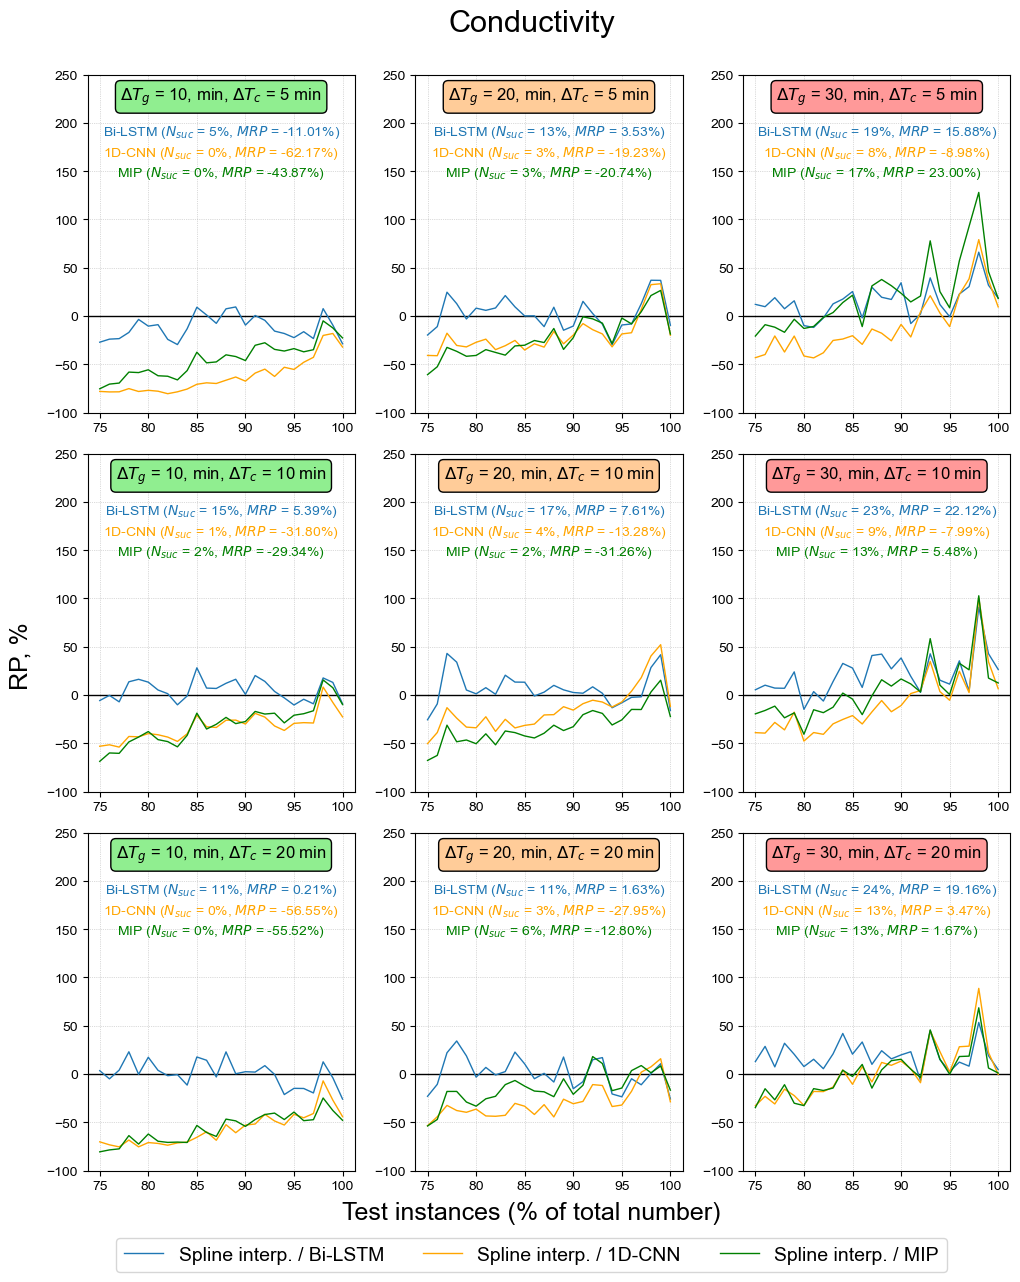







Max values of RP
Bi-LSTM: [9.371, 37.033, 66.13, 28.162, 43.066, 91.03, 22.993, 34.201, 53.411] , max of max: 91.0 % , mean of max: 42.8 %
1D-CNN: [-18.135, 33.42, 79.118, 8.204, 52.106, 100.539, -7.133, 15.827, 88.721] , max of max: 100.5 % , mean of max: 39.2 %
MIP: [-5.044, 26.511, 128.034, 15.564, 15.343, 102.81, -24.879, 18.08, 68.572] , max of max: 128.0 % , mean of max: 38.3 %



MIN values of RP
Bi-LSTM: [-29.603, -29.808, -11.855, -10.383, -16.063, -14.872, -26.007, -25.827, -6.61] , min of min: -29.8 % , mean of min: -19.0 %
1D-CNN: [-80.522, -41.146, -43.418, -53.997, -38.89, -47.752, -75.518, -44.506, -32.559] , min of min: -80.5 % , mean of min: -50.9 %
MIP: [-70.582, -52.607, -16.878, -60.458, -62.598, -40.69, -78.66, -47.124, -32.743] , min of min: -78.7 % , mean of min: -51.4 %



Total shares of data where the models overperform baseline
Bi-LSTM: [5, 13, 19, 15, 17, 23, 11, 11, 24] , average: 15.3 % , max: 24.0 %
1D-CNN: [0, 3, 8, 1, 4, 9, 0, 3, 13] , average: 4.

In [52]:
# def find_cross_index_with_nans(array1, array2, offset_size=0, direction='forw'):
#     # Ensure the arrays are numpy arrays
#     array1 = np.array(array1)
#     array2 = np.array(array2)

#     # Reverse arrays for 'backw' direction
#     array1_back = array1[::-1]
#     array2_back = array2[::-1]
        

#     # Iterate through both arrays
#     for i in range(len(array1)):
#         # Skip NaN values
#         if np.isnan(array1[i]) or np.isnan(array2[i]):
#             continue

#         # Handle 'forw' direction
#         if array1[i] < array2[i] - offset_size:
#             forward_index = i  # Store the index if condition is met
#             if direction == 'forw':
#                 return forward_index
                
#             elif direction == 'backw':
#                 # Iterate through both arrays
#                 for j in range(len(array1_back)):
#                     # Skip NaN values
#                     if np.isnan(array1_back[j]) or np.isnan(array2_back[j]):
#                         continue
                        
#                     # Handle 'backw' direction
#                     if array1_back[j] < array2_back[j]:
#                         # If a cross is found in the backw direction
#                         reverse_index = len(array1_back) - j
#                         # Exclude cases that never back-cross
#                         if reverse_index == 100 or reverse_index == 99:
#                             return None
#                         # Compare with the forward index and return None if reverse index is smaller
#                         if reverse_index < forward_index:
#                             return None
#                         else:
#                             return reverse_index
#     return None


# 'Turbidity', 'Conductivity', 'pH'
par_for_graph = 'Conductivity'
# 'Linear', 'Spline', 'IDW', 'Fourier'
if par_for_graph == 'Turbidity':
    base_method = 'Linear'
elif par_for_graph == 'Conductivity':
    base_method = 'Spline'
elif par_for_graph == 'pH':
    base_method = 'Linear'

if par_for_graph == 'Turbidity':
    RMSE_weights = turb_RMSE
    mi, ma = -80, 80
    offset_size = 0
elif par_for_graph == 'Conductivity':
    RMSE_weights = cond_RMSE
    mi, ma = -100, 250
    offset_size = 0
elif par_for_graph == 'pH':
    RMSE_weights = pH_RMSE
    mi, ma = -100, 200
    offset_size = 0

for metric_for_graph in ['RMSE']:
    # Getting values for different scenarious and differrent cases
    splts = []
    for thr in range(100):
        splt = [mod for mod in heatmap_model_datasets(par_for_graph, 'Test', metric_for_graph, thr)]
        splts.append(splt)

    lg_sizes = [5, 10, 20]
    gp_sizes = [10, 20, 30]
    


    
    
    # Set up subplots
    fig, axs = plt.subplots(len(lg_values), len(gp_values), figsize=(10, 12))
    
    LSTM_SED_list, CNN_SED_list, MLP_SED_list = [], [], []
    LSTM_MRP_list, CNN_MRP_list, MLP_MRP_list = [], [], []
    LSTM_WMRP_list, CNN_WMRP_list, MLP_WMRP_list = [], [], []

    LSTM_max_list, CNN_max_list, MLP_max_list = [], [], []
    LSTM_min_list, CNN_min_list, MLP_min_list = [], [], []
    
    # Iterate over all combinations of lg and gp
    for i, lg in enumerate(lg_sizes):
        for j, gp in enumerate(gp_sizes):
            LSTM_splts, CNN_splts, MLP_splts, lin_splts, spl_splts, idw_splts, fourier_splts = [], [], [], [], [], [], []
    
            # Collect data for each model type based on the current lg and gp
            for splt in splts:
                for mdl_ind, mdl in enumerate(splt):
                    if mdl_ind == 0:
                        LSTM_splts.append(mdl[i, j])
                    elif mdl_ind == 1:
                        CNN_splts.append(mdl[i, j])
                    elif mdl_ind == 2:
                        MLP_splts.append(mdl[i, j])
                    elif mdl_ind == 3:
                        lin_splts.append(mdl[i, j])
                    elif mdl_ind == 4:
                        spl_splts.append(mdl[i, j])
                    elif mdl_ind == 5:
                        idw_splts.append(mdl[i, j])
                    elif mdl_ind == 6:
                        fourier_splts.append(mdl[i, j])
    
            # Convert lists to arrays for processing
            LSTM_splts = np.array(LSTM_splts)
            CNN_splts = np.array(CNN_splts)
            MLP_splts = np.array(MLP_splts)
            lin_splts = np.array(lin_splts)
            spl_splts = np.array(spl_splts)
            idw_splts = np.array(idw_splts)
            fourier_splts = np.array(fourier_splts)

            
            if base_method == 'Linear':
                base_splts = lin_splts
            elif base_method == 'Spline':
                base_splts = spl_splts
            elif base_method == 'IDW':
                base_splts = idw_splts
            elif base_method == 'Fourier':
                base_splts = fourier_splts
            
            # Calculate the difference between a model and Linear interpolation
            rel_LSTM = (base_splts - LSTM_splts)/LSTM_splts*100
            rel_CNN = (base_splts - CNN_splts)/CNN_splts*100
            rel_MLP = (base_splts - MLP_splts)/MLP_splts*100
            
            # # Calculate performance of a model relative to the Linear interpolation
            # rel_LSTM = (base_splts/LSTM_splts)
            # rel_CNN = (base_splts/CNN_splts)
            # rel_MLP = (base_splts/MLP_splts)

            # Count values greater than 1 to see the size of the effective dataset (SED, %) 
            # IN TOP 25% of instances
            SED_LSTM = np.sum(rel_LSTM[-25:] > 1)
            SED_CNN = np.sum(rel_CNN[-25:] > 1)
            SED_MLP = np.sum(rel_MLP[-25:] > 1)

            LSTM_max = np.max(rel_LSTM[-25:])
            CNN_max = np.max(rel_CNN[-25:])
            MLP_max = np.max(rel_MLP[-25:])

            LSTM_min = np.min(rel_LSTM[-25:])
            CNN_min = np.min(rel_CNN[-25:])
            MLP_min = np.min(rel_MLP[-25:])
            

            # Mean relative performance (MRP)
            # IN TOP 25% of instances
            MRP_LSTM = np.nanmean(rel_LSTM[-25:])
            MRP_CNN = np.nanmean(rel_CNN[-25:])
            MRP_MLP = np.nanmean(rel_MLP[-25:])



            # Weighed Mean Relative Performance (WMRP)
            WMRP_LSTM = np.nansum(rel_LSTM * RMSE_weights[f'{lg}_{2*gp}'][1])
            WMRP_CNN = np.nansum(rel_CNN * RMSE_weights[f'{lg}_{2*gp}'][1])
            WMRP_MLP = np.nansum(rel_MLP * RMSE_weights[f'{lg}_{2*gp}'][1])
            
            # Plot in the corresponding subplot
            x = np.arange(len(base_splts))
            
            axs[i, j].axhline(0, color = 'black', linewidth = 1)

            # Labels
            if i == 0 and j == 0:
                labels_LSTM = f'{base_method} interp. / Bi-LSTM'
                labels_CNN = f'{base_method} interp. / 1D-CNN'
                labels_MLP = f'{base_method} interp. / MIP'
            else:
                labels_LSTM = '_nolegend_'
                labels_CNN = '_nolegend_'
                labels_MLP = '_nolegend_'
                
            axs[i, j].plot(x[-26:]+1, rel_LSTM[-26:], label=labels_LSTM, linewidth=1)
            axs[i, j].plot(x[-26:]+1, rel_CNN[-26:], label=labels_CNN, color='orange', linewidth=1)
            axs[i, j].plot(x[-26:]+1, rel_MLP[-26:], label=labels_MLP, color='g', linewidth=1)

            # axs[i, j].axvspan(0, 25, color='green', alpha=0.08)
            # axs[i, j].axvspan(25, 75, color='orange', alpha=0.08)
            # axs[i, j].axvspan(75, 100, color='red', alpha=0.08)
            
            axs[i, j].grid(True, which='both', axis='both', linestyle=':', linewidth=0.5, alpha=0.9)
            # axs[i, j].set_xticks([0, 25, 50, 75, 100])
            # axs[i, j].set_xticks([75, 80, 85, 90, 95, 100])

            # Find the index where a value of the model crosses linear interpolation line
            LSTM_cross_idx = find_cross_index_with_nans(LSTM_splts, base_splts, offset_size, 'forw')
            CNN_cross_idx = find_cross_index_with_nans(CNN_splts, base_splts, offset_size, 'forw')
            MLP_cross_idx = find_cross_index_with_nans(MLP_splts, base_splts, offset_size, 'forw')

            LSTM_cross_back_idx = find_cross_index_with_nans(LSTM_splts, base_splts, offset_size, 'backw')
            CNN_cross_back_idx = find_cross_index_with_nans(CNN_splts, base_splts, offset_size, 'backw')
            MLP_cross_back_idx = find_cross_index_with_nans(MLP_splts, base_splts, offset_size, 'backw')
            
            
            # Add vertical lines for crossings
            if LSTM_cross_idx is not None:
                # axs[i, j].axvline(x=LSTM_cross_idx, linestyle=':', linewidth=1)
                if LSTM_cross_back_idx is not None:
                    # If there is back-crossing
                    # axs[i, j].axvline(x=LSTM_cross_back_idx, linestyle=':', linewidth=1)
                    LSTM_ind_value = LSTM_cross_back_idx - LSTM_cross_idx
                    # axs[i, j].text(LSTM_cross_idx + (LSTM_cross_back_idx - LSTM_cross_idx)/2 - 3, (ma+mi)/2, f'  {LSTM_ind_value}\n<->', fontsize=10, color = '#1f77b4')
                else:
                    # If there is no back-crossing
                    LSTM_ind_value = len(base_splts) - LSTM_cross_idx
                    # axs[i, j].text(LSTM_cross_idx + 1, (ma+mi)/2, f'{LSTM_ind_value}\n-->', fontsize=10, color = '#1f77b4')
                

            if CNN_cross_idx is not None:
                # axs[i, j].axvline(x=CNN_cross_idx, linestyle=':', linewidth=1, color = 'orange')
                if CNN_cross_back_idx is not None:
                    # If there is back-crossing
                    # axs[i, j].axvline(x=CNN_cross_back_idx, linestyle=':', linewidth=1, color = 'orange')
                    CNN_ind_value = CNN_cross_back_idx - CNN_cross_idx
                    # axs[i, j].text(CNN_cross_idx + (CNN_cross_back_idx - CNN_cross_idx)/2 - 3, 1.4*(ma+mi)/2, f'  {CNN_ind_value}\n<->', fontsize=10, color = 'orange')
                else:
                    # If there is no back-crossing
                    CNN_ind_value = len(base_splts) - CNN_cross_idx
                    # axs[i, j].text(CNN_cross_idx + 1, 1.4*(ma+mi)/2, f'{CNN_ind_value}\n-->', fontsize=10, color = 'orange')


            if MLP_cross_idx is not None:
                # axs[i, j].axvline(x=MLP_cross_idx, linestyle=':', linewidth=1, color = 'g')
                if MLP_cross_back_idx is not None:
                    # If there is back-crossing
                    # axs[i, j].axvline(x=MLP_cross_back_idx, linestyle=':', linewidth=1, color = 'g')
                    MLP_ind_value = MLP_cross_back_idx - MLP_cross_idx
                    # axs[i, j].text(MLP_cross_idx + (MLP_cross_back_idx - MLP_cross_idx)/2 - 3, 1.6*(ma+mi)/2, f'  {MLP_ind_value}\n<->', fontsize=10, color = 'g')
                else:
                    # If there is no back-crossing
                    MLP_ind_value = len(base_splts) - MLP_cross_idx
                    # axs[i, j].text(MLP_cross_idx + 1, 1.6*(ma+mi)/2, f'{MLP_ind_value}\n-->', fontsize=10, color = 'g')

            # # To find average
            LSTM_SED_list.append(SED_LSTM)
            CNN_SED_list.append(SED_CNN)
            MLP_SED_list.append(SED_MLP)

            LSTM_max_list.append(LSTM_max)
            CNN_max_list.append(CNN_max)
            MLP_max_list.append(MLP_max)
            
            LSTM_min_list.append(LSTM_min)
            CNN_min_list.append(CNN_min)
            MLP_min_list.append(MLP_min)

            LSTM_MRP_list.append(MRP_LSTM)
            CNN_MRP_list.append(MRP_CNN)
            MLP_MRP_list.append(MRP_MLP)

            LSTM_WMRP_list.append(WMRP_LSTM)
            CNN_WMRP_list.append(WMRP_CNN)
            MLP_WMRP_list.append(WMRP_MLP)

            # Adding sum values as text annotations
            axs[i, j].text(0.5, 0.82, fr'Bi-LSTM ($N_{{suc}}$ = {SED_LSTM:.0f}%, $MRP$ = {MRP_LSTM:.2f}%)', transform=axs[i, j].transAxes, fontsize=10, color='#1f77b4', ha='center')
            axs[i, j].text(0.5, 0.76, fr'1D-CNN ($N_{{suc}}$ = {SED_CNN:.0f}%, $MRP$ = {MRP_CNN:.2f}%)', transform=axs[i, j].transAxes, fontsize=10, color='orange', ha='center')
            axs[i, j].text(0.5, 0.7, fr'MIP ($N_{{suc}}$ = {SED_MLP:.0f}%, $MRP$ = {MRP_MLP:.2f}%)', transform=axs[i, j].transAxes, fontsize=10, color='green', ha='center')
            
            # Formatting
            axs[i, j].set_ylim(mi, ma)
            axs[i, j].tick_params(axis='x', labelsize=10)  # Set font size for x-axis tick labels
            axs[i, j].tick_params(axis='y', labelsize=10)  # Set font size for y-axis tick labels


            
            if gp_sizes[j] == 10:
                back_color = '#90EE90'
            elif gp_sizes[j] == 20:
                back_color = '#FFCC99'
            elif gp_sizes[j] == 30:
                back_color = '#FF9999'


            if par_for_graph == 'Turbidity':
                v_shift = 0.94
            elif par_for_graph == 'Conductivity':
                v_shift = 0.955
            elif par_for_graph == 'pH':
                v_shift = 0.955
            axs[i, j].text(87.5, v_shift*ma, f"$\Delta T_{{g}}$ = {gp_sizes[j]}, min, $\Delta T_{{c}}$ = {lg_sizes[i]} min", ha='center', va = 'top', fontsize = 12, bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor=back_color))

            
    # Add one common x-axis label for all graphs
    fig.text(0.5, 0.98, f'{par_for_graph}', ha='center', fontsize=22)

    
    if metric_for_graph == 'SMAPE':
        unit = '%'
    else:
        if par_for_graph == 'Turbidity':
            unit = 'NTU'
        elif par_for_graph == 'Conductivity':
            unit = 'μS/cm'
        else:
            unit = ''
    
    # fig.text(-0.01, 0.46, r"$\frac{{" + metric_for_graph + r"_{base}}-{" + metric_for_graph + r"_{model}}}{" + metric_for_graph + r"_{model}}$∙100, %", ha='center', va='center', rotation='vertical', fontsize=18)
    fig.text(-0.01, 0.46, 'RP, %', ha='center', va='center', rotation='vertical', fontsize=18)
    fig.text(0.5, -0.01, 'Test instances (% of total number)', ha='center', fontsize=18)
    # Create a single legend for all subplots and place it below the plots
    fig.legend(loc='center', bbox_to_anchor=(0.5, -0.04), fontsize=14, ncol=3)


    
    # Adjust layout and display the figure
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust to fit title
    # Save the plot
    plt.savefig(fr"H:\Work\Writing in progress\3. ML paper\Draft\Figures\ML results\{par_for_graph}.png", dpi=300, bbox_inches="tight")
    
    plt.show()

    if par_for_graph == 'Turbidity':
        LSTM_SED_list_turb = LSTM_SED_list
        CNN_SED_list_turb = CNN_SED_list
        MLP_SED_list_turb = MLP_SED_list
        LSTM_max_list_turb = LSTM_max_list
        CNN_max_list_turb = CNN_max_list
        MLP_max_list_turb = MLP_max_list
        LSTM_min_list_turb = LSTM_min_list
        CNN_min_list_turb = CNN_min_list
        MLP_min_list_turb = MLP_min_list
        LSTM_MRP_list_turb = LSTM_MRP_list
        CNN_MRP_list_turb = CNN_MRP_list
        MLP_MRP_list_turb = MLP_MRP_list
        LSTM_WMRP_list_turb = LSTM_WMRP_list
        CNN_WMRP_list_turb = CNN_WMRP_list
        MLP_WMRP_list_turb = MLP_WMRP_list
    elif par_for_graph == 'Conductivity':
        LSTM_SED_list_cond = LSTM_SED_list
        CNN_SED_list_cond = CNN_SED_list
        MLP_SED_list_cond = MLP_SED_list
        LSTM_max_list_cond = LSTM_max_list
        CNN_max_list_cond = CNN_max_list
        MLP_max_list_cond = MLP_max_list
        LSTM_min_list_cond = LSTM_min_list
        CNN_min_list_cond = CNN_min_list
        MLP_min_list_cond = MLP_min_list
        LSTM_MRP_list_cond = LSTM_MRP_list
        CNN_MRP_list_cond = CNN_MRP_list
        MLP_MRP_list_cond = MLP_MRP_list
        LSTM_WMRP_list_cond = LSTM_WMRP_list
        CNN_WMRP_list_cond = CNN_WMRP_list
        MLP_WMRP_list_cond = MLP_WMRP_list
    elif par_for_graph == 'pH':
        LSTM_SED_list_pH = LSTM_SED_list
        CNN_SED_list_pH = CNN_SED_list
        MLP_SED_list_pH = MLP_SED_list
        LSTM_max_list_pH = LSTM_max_list
        CNN_max_list_pH = CNN_max_list
        MLP_max_list_pH = MLP_max_list
        LSTM_min_list_pH = LSTM_min_list
        CNN_min_list_pH = CNN_min_list
        MLP_min_list_pH = MLP_min_list
        LSTM_MRP_list_pH = LSTM_MRP_list
        CNN_MRP_list_pH = CNN_MRP_list
        MLP_MRP_list_pH = MLP_MRP_list
        LSTM_WMRP_list_pH = LSTM_WMRP_list
        CNN_WMRP_list_pH = CNN_WMRP_list
        MLP_WMRP_list_pH = MLP_WMRP_list






# Stats



print('\n\n\n\n\n')
LSTM_max_list_max = np.nanmax(np.array(LSTM_max_list, dtype=np.float64))
CNN_max_list_max = np.nanmax(np.array(CNN_max_list, dtype=np.float64))
MLP_max_list_max = np.nanmax(np.array(MLP_max_list, dtype=np.float64))
LSTM_max_list_average = np.nanmean(np.array(LSTM_max_list, dtype=np.float64))
CNN_max_list_average = np.nanmean(np.array(CNN_max_list, dtype=np.float64))
MLP_max_list_average = np.nanmean(np.array(MLP_max_list, dtype=np.float64))
print('Max values of RP')
print('Bi-LSTM:', [round(case, 3) for case in LSTM_max_list], ', max of max:', round(LSTM_max_list_max, 1), '%', ', mean of max:', round(LSTM_max_list_average, 1), '%')
print('1D-CNN:', [round(case, 3) for case in CNN_max_list], ', max of max:', round(CNN_max_list_max, 1), '%', ', mean of max:', round(CNN_max_list_average, 1), '%')
print('MIP:', [round(case, 3) for case in MLP_max_list], ', max of max:', round(MLP_max_list_max, 1), '%', ', mean of max:', round(MLP_max_list_average, 1), '%')





print('\n\n')
LSTM_min_list_min = np.nanmin(np.array(LSTM_min_list, dtype=np.float64))
CNN_min_list_min = np.nanmin(np.array(CNN_min_list, dtype=np.float64))
MLP_min_list_min = np.nanmin(np.array(MLP_min_list, dtype=np.float64))
LSTM_min_list_average = np.nanmean(np.array(LSTM_min_list, dtype=np.float64))
CNN_min_list_average = np.nanmean(np.array(CNN_min_list, dtype=np.float64))
MLP_min_list_average = np.nanmean(np.array(MLP_min_list, dtype=np.float64))
print('MIN values of RP')
print('Bi-LSTM:', [round(case, 3) for case in LSTM_min_list], ', min of min:', round(LSTM_min_list_min, 1), '%', ', mean of min:', round(LSTM_min_list_average, 1), '%')
print('1D-CNN:', [round(case, 3) for case in CNN_min_list], ', min of min:', round(CNN_min_list_min, 1), '%', ', mean of min:', round(CNN_min_list_average, 1), '%')
print('MIP:', [round(case, 3) for case in MLP_min_list], ', min of min:', round(MLP_min_list_min, 1), '%', ', mean of min:', round(MLP_min_list_average, 1), '%')










print('\n\n')
LSTM_cross_idx_average = np.nanmean(np.array(LSTM_SED_list, dtype=np.float64))
CNN_cross_idx_average = np.nanmean(np.array(CNN_SED_list, dtype=np.float64))
MLP_cross_idx_average = np.nanmean(np.array(MLP_SED_list, dtype=np.float64))
LSTM_cross_idx_max = np.nanmax(np.array(LSTM_SED_list, dtype=np.float64))
CNN_cross_idx_max = np.nanmax(np.array(CNN_SED_list, dtype=np.float64))
MLP_cross_idx_max = np.nanmax(np.array(MLP_SED_list, dtype=np.float64))
print('Total shares of data where the models overperform baseline')
print('Bi-LSTM:', LSTM_SED_list, ', average:', round(LSTM_cross_idx_average, 1), '%', ', max:', round(LSTM_cross_idx_max, 1), '%')
print('1D-CNN:', CNN_SED_list, ', average:', round(CNN_cross_idx_average, 1), '%', ', max:', round(CNN_cross_idx_max, 1), '%')
print('MIP:', MLP_SED_list, ', average:', round(MLP_cross_idx_average, 1), '%', ', max:', round(MLP_cross_idx_max, 1), '%')

print('\n\n')
LSTM_mean_rel_perf = np.nanmean(np.array(LSTM_MRP_list, dtype=np.float64))
CNN_mean_rel_perf = np.nanmean(np.array(CNN_MRP_list, dtype=np.float64))
MLP_mean_rel_perf = np.nanmean(np.array(MLP_MRP_list, dtype=np.float64))
LSTM_max_rel_perf = np.nanmax(np.array(LSTM_MRP_list, dtype=np.float64))
CNN_max_rel_perf = np.nanmax(np.array(CNN_MRP_list, dtype=np.float64))
MLP_max_rel_perf = np.nanmax(np.array(MLP_MRP_list, dtype=np.float64))
LSTM_min_rel_perf = np.nanmin(np.array(LSTM_MRP_list, dtype=np.float64))
CNN_min_rel_perf = np.nanmin(np.array(CNN_MRP_list, dtype=np.float64))
MLP_min_rel_perf = np.nanmin(np.array(MLP_MRP_list, dtype=np.float64))
print('Mean relative performance')
print('Bi-LSTM:', [round(el, 3) for el in LSTM_MRP_list], ', average:', round(LSTM_mean_rel_perf, 3), ', max:', round(LSTM_max_rel_perf, 2), ', min:', round(LSTM_min_rel_perf, 2))
print('1D-CNN:', [round(el, 3) for el in CNN_MRP_list], ', average:', round(CNN_mean_rel_perf, 3), ', max:', round(CNN_max_rel_perf, 2), ', min:', round(CNN_min_rel_perf, 2))
print('MIP:', [round(el, 3) for el in MLP_MRP_list], ', average:', round(MLP_mean_rel_perf, 3), ', max:', round(MLP_max_rel_perf, 2), ', min:', round(MLP_min_rel_perf, 2))

# print('\n\n')
# LSTM_weighed_mean_rel_perf = np.nanmean(np.array(LSTM_WMRP_list, dtype=np.float64))
# CNN_weighed_mean_rel_perf = np.nanmean(np.array(CNN_WMRP_list, dtype=np.float64))
# MLP_weighed_mean_rel_perf = np.nanmean(np.array(MLP_WMRP_list, dtype=np.float64))
# print('Weighed mean relative performance')
# print('LSTM:', [round(el, 3) for el in LSTM_WMRP_list], ', average:', round(LSTM_weighed_mean_rel_perf, 3))
# print('CNN:', [round(el, 3) for el in CNN_WMRP_list], ', average:', round(CNN_weighed_mean_rel_perf, 3))
# print('MLP:', [round(el, 3) for el in MLP_WMRP_list], ', average:', round(MLP_weighed_mean_rel_perf, 3))

#### Boxplots for cases instead of scatter plots

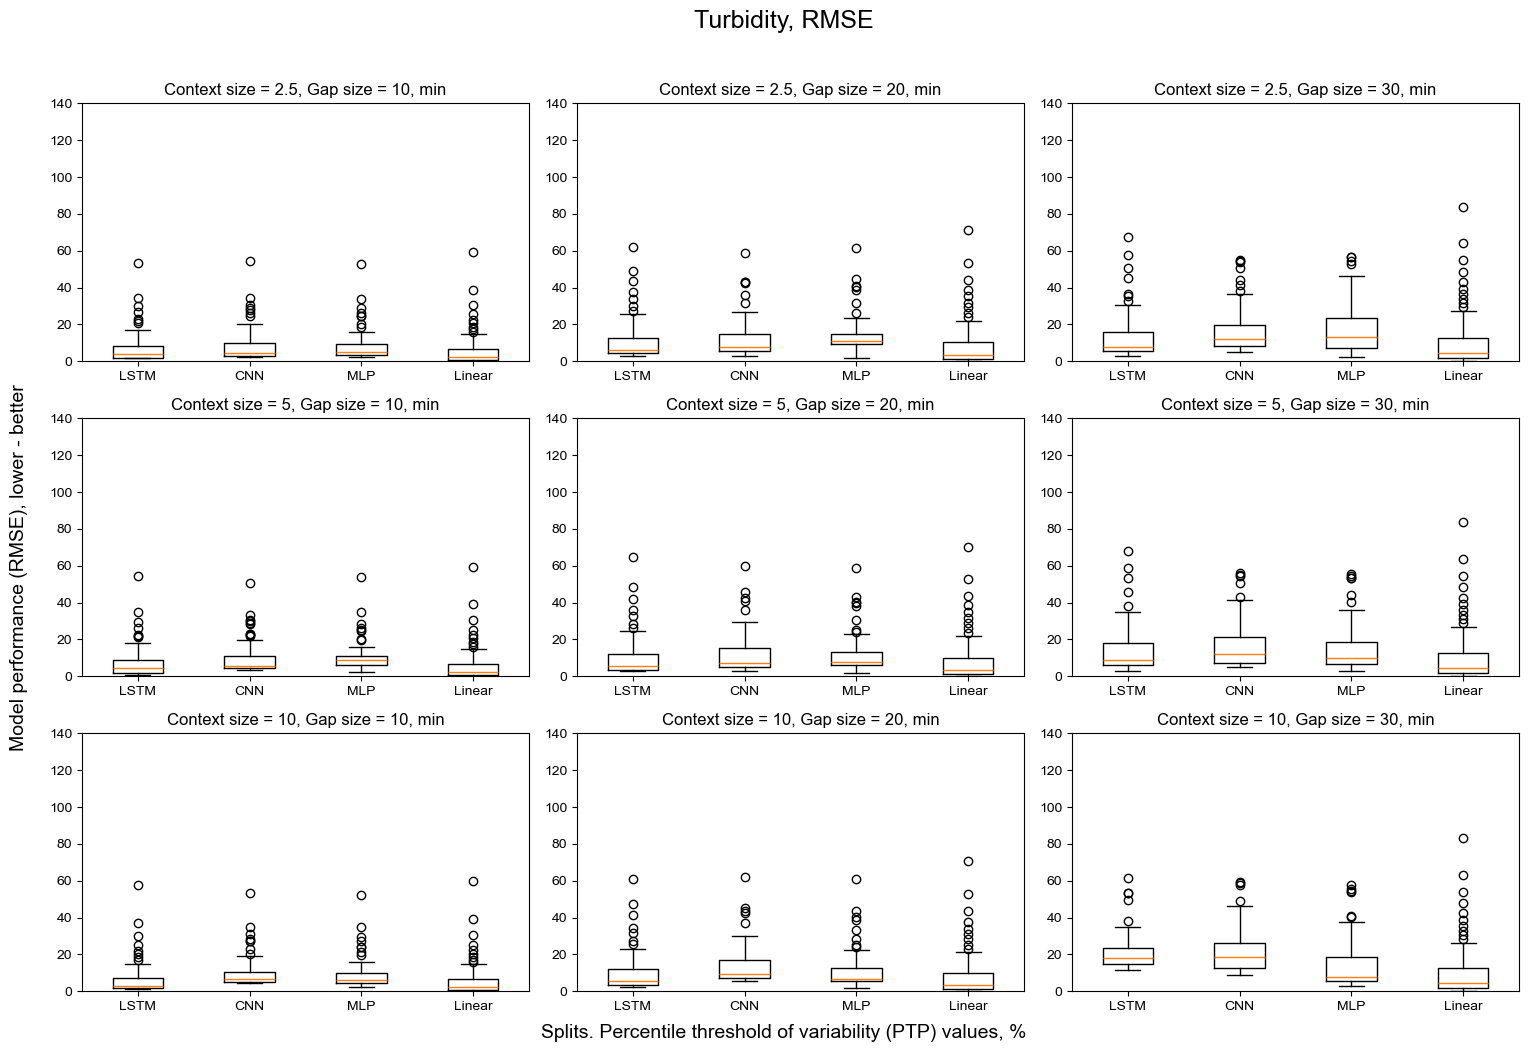

In [753]:
par_for_graph = 'Turbidity'

for metric_for_graph in ['RMSE']:
    # Getting values for different scenarious and differrent cases
    splts = []
    for thr in range(100):
        splt = [mod for mod in heatmap_model_datasets(par_for_graph, 'Test', metric_for_graph, thr)]
        splts.append(splt)
    
    lg_values = [0, 1, 2]
    gp_values = [0, 1, 2]
    
    lg_sizes = [2.5, 5, 10]
    gp_sizes = [10, 20, 30]


    all_values = np.concatenate([arr.flatten() for sublist in splts for arr in sublist])
    
    # Find minimum and maximum values
    min_value = math.floor(np.nanmin(all_values) / 5) * 5
    max_value = math.ceil(np.nanmax(all_values) / 5) * 5
    

    # Set up subplots
    fig, axs = plt.subplots(len(lg_values), len(gp_values), figsize=(15, 10))
    
    # Iterate over all combinations of lg and gp
    for i, lg in enumerate(lg_values):
        for j, gp in enumerate(gp_values):
            LSTM_splts, CNN_splts, MLP_splts, lin_splts = [], [], [], []
            
            # Collect data for each model type based on the current lg and gp
            for split_ind, splt in enumerate(splts):
                for mdl_ind, mdl in enumerate(splt):
                    if mdl_ind == 0:
                        LSTM_splts.append(mdl[lg, gp])
                    elif mdl_ind == 1:
                        CNN_splts.append(mdl[lg, gp])
                    elif mdl_ind == 2:
                        MLP_splts.append(mdl[lg, gp])
                    elif mdl_ind == 3:
                        lin_splts.append(mdl[lg, gp])


            # Assuming LSTM_splts, CNN_splts, MLP_splts, and lin_splts are lists or arrays of data points
            data = [LSTM_splts, CNN_splts, MLP_splts, lin_splts]
            labels = ["LSTM", "CNN", "MLP", "Linear"]
            
            # Plot in the corresponding subplot
            axs[i, j].boxplot(data, labels=labels)
            
            # Set y-axis limits
            axs[i, j].set_ylim(min_value, max_value)
            
            # Set title
            axs[i, j].set_title(f"Context size = {lg_sizes[i]}, Gap size = {gp_sizes[j]}, min")
            
    # Add one common x-axis label for all graphs
    fig.text(0.5, 1, f'{par_for_graph}, {metric_for_graph}', ha='center', fontsize=18)
    fig.text(0.5, -0.01, 'Splits. Percentile threshold of variability (PTP) values, %', ha='center', fontsize=14)
    fig.text(-0.01, 0.46, f'Model performance ({metric_for_graph}), lower - better', ha='center', va='center', rotation='vertical', fontsize=14)
    
    # Adjust layout and display the figure
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust to fit title
    plt.show()
    print('\n\n\n\n\n\n')

#### Combined boxplot

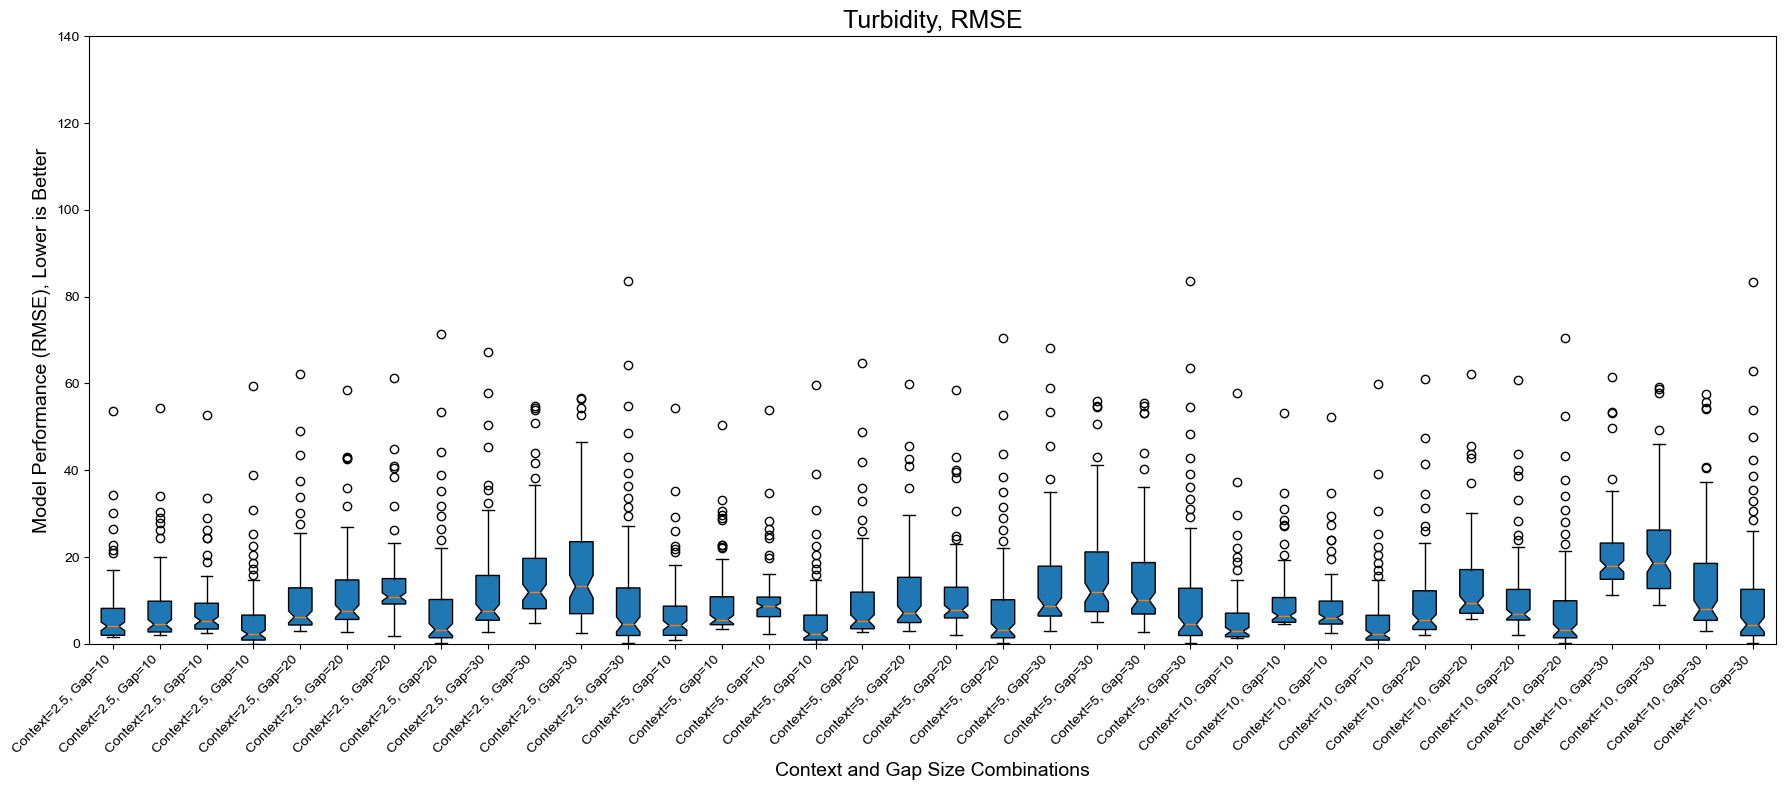

In [754]:
par_for_graph = 'Turbidity'

for metric_for_graph in ['RMSE']:
    # Getting values for different scenarios and cases
    splts = []
    for thr in range(100):
        splt = [mod for mod in heatmap_model_datasets(par_for_graph, 'Test', metric_for_graph, thr)]
        splts.append(splt)
    
    lg_values = [0, 1, 2]
    gp_values = [0, 1, 2]
    
    lg_sizes = [2.5, 5, 10]
    gp_sizes = [10, 20, 30]
    
    all_values = np.concatenate([arr.flatten() for sublist in splts for arr in sublist])
    
    # Find minimum and maximum values
    min_value = math.floor(np.nanmin(all_values) / 5) * 5
    max_value = math.ceil(np.nanmax(all_values) / 5) * 5
    
    # Initialize data for the combined plot
    combined_data = []
    combined_labels = []
    x_labels = []

    # Iterate over all combinations of lg and gp
    for i, lg in enumerate(lg_values):
        for j, gp in enumerate(gp_values):
            LSTM_splts, CNN_splts, MLP_splts, lin_splts = [], [], [], []
            
            # Collect data for each model type based on the current lg and gp
            for split_ind, splt in enumerate(splts):
                for mdl_ind, mdl in enumerate(splt):
                    if mdl_ind == 0:
                        LSTM_splts.append(mdl[lg, gp])
                    elif mdl_ind == 1:
                        CNN_splts.append(mdl[lg, gp])
                    elif mdl_ind == 2:
                        MLP_splts.append(mdl[lg, gp])
                    elif mdl_ind == 3:
                        lin_splts.append(mdl[lg, gp])
            
            # Prepare data for combined boxplot
            combined_data.extend([LSTM_splts, CNN_splts, MLP_splts, lin_splts])
            combined_labels.extend(["LSTM", "CNN", "MLP", "Linear"])
            x_labels.extend([f"Context={lg_sizes[i]}, Gap={gp_sizes[j]}"] * 4)

    # Plot the combined boxplot
    fig, ax = plt.subplots(figsize=(18, 8))
    ax.boxplot(combined_data, labels=x_labels, notch=True, patch_artist=True)
    
    # Customize plot appearance
    ax.set_ylim(min_value, max_value)
    ax.set_title(f"{par_for_graph}, {metric_for_graph}", fontsize=18)
    ax.set_xlabel("Context and Gap Size Combinations", fontsize=14)
    ax.set_ylabel(f"Model Performance ({metric_for_graph}), Lower is Better", fontsize=14)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha="right")
    
    # Display the plot
    plt.tight_layout()
    plt.show()


#### Boxplot colorcoded by model

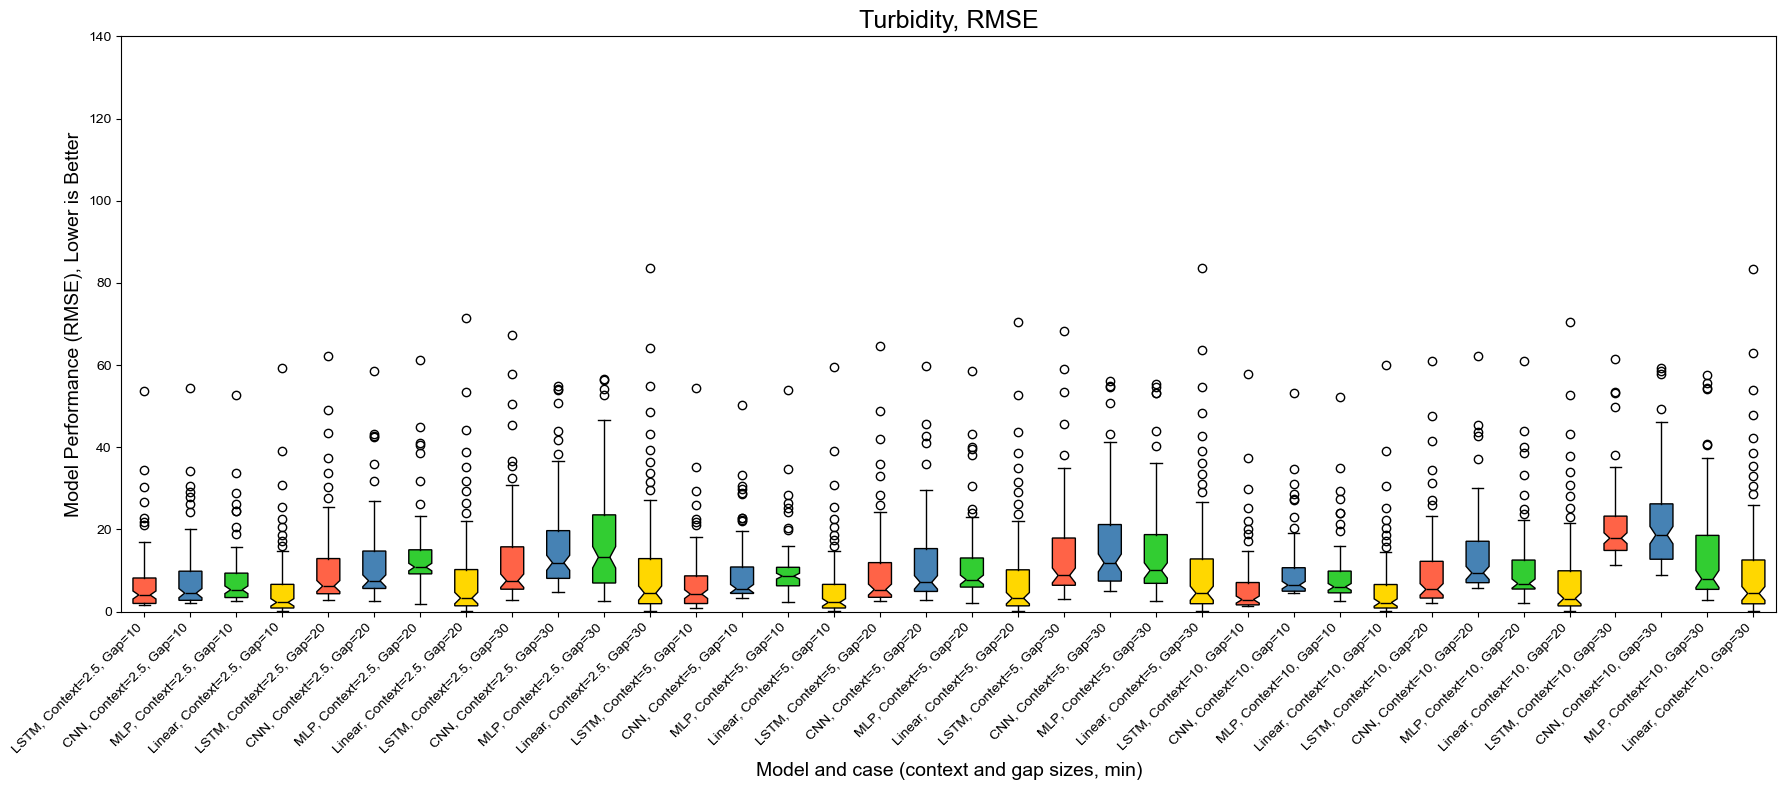

In [755]:
# Function to prepare data for the boxplot
def boxplot_data(parameter, metric):
    """
    Prepares data for combined boxplots.

    Args:
        parameter (str): The parameter of interest (e.g., 'Turbidity').
        metric (str): The metric for performance (e.g., 'SMAPE').

    Returns:
        combined_data (list): Data for all models across all scenarios.
        x_labels (list): Combined labels for each scenario and model.
        min_value (float): Minimum value for the y-axis.
        max_value (float): Maximum value for the y-axis.
    """
    # Getting values for different scenarios and cases
    splts = []
    for thr in range(100):
        splt = [mod for mod in heatmap_model_datasets(parameter, 'Test', metric, thr)]
        splts.append(splt)
    
    lg_values = [0, 1, 2]
    gp_values = [0, 1, 2]
    
    lg_sizes = [2.5, 5, 10]
    gp_sizes = [10, 20, 30]
    
    all_values = np.concatenate([arr.flatten() for sublist in splts for arr in sublist])
    
    # Find minimum and maximum values
    min_value = math.floor(np.nanmin(all_values) / 5) * 5
    max_value = math.ceil(np.nanmax(all_values) / 5) * 5
    
    # Initialize data for the combined plot
    combined_data = []
    x_labels = []

    # Iterate over all combinations of lg and gp
    for i, lg in enumerate(lg_values):
        for j, gp in enumerate(gp_values):
            LSTM_splts, CNN_splts, MLP_splts, lin_splts = [], [], [], []
            
            # Collect data for each model type based on the current lg and gp
            for split_ind, splt in enumerate(splts):
                for mdl_ind, mdl in enumerate(splt):
                    if mdl_ind == 0:
                        LSTM_splts.append(mdl[lg, gp])
                    elif mdl_ind == 1:
                        CNN_splts.append(mdl[lg, gp])
                    elif mdl_ind == 2:
                        MLP_splts.append(mdl[lg, gp])
                    elif mdl_ind == 3:
                        lin_splts.append(mdl[lg, gp])
            
            # Prepare data for combined boxplot
            combined_data.extend([LSTM_splts, CNN_splts, MLP_splts, lin_splts])
            x_labels.extend([
                f"LSTM, Context={lg_sizes[i]}, Gap={gp_sizes[j]}",
                f"CNN, Context={lg_sizes[i]}, Gap={gp_sizes[j]}",
                f"MLP, Context={lg_sizes[i]}, Gap={gp_sizes[j]}",
                f"Linear, Context={lg_sizes[i]}, Gap={gp_sizes[j]}"
            ])
            
    return combined_data, x_labels, min_value, max_value


# Main plotting loop
par_for_graph = 'Turbidity'
for metric_for_graph in ['RMSE']:
    combined_data, x_labels, min_value, max_value = boxplot_data(par_for_graph, metric_for_graph)

    # Colors for each model type
    model_colors = {
        "LSTM": '#FF6347',  # Tomato
        "CNN": '#4682B4',   # SteelBlue
        "MLP": '#32CD32',   # LimeGreen
        "Linear": '#FFD700' # Gold
    }
    
    # Plot the combined boxplot
    fig, ax = plt.subplots(figsize=(18, 8))
    boxplot = ax.boxplot(combined_data, labels=x_labels, notch=True, patch_artist=True)
    
    # Apply the colors to the boxes based on the model
    for patch, label in zip(boxplot['boxes'], x_labels):
        if "LSTM" in label:
            patch.set_facecolor(model_colors["LSTM"])
        elif "CNN" in label:
            patch.set_facecolor(model_colors["CNN"])
        elif "MLP" in label:
            patch.set_facecolor(model_colors["MLP"])
        elif "Linear" in label:
            patch.set_facecolor(model_colors["Linear"])
    
    # Change the color of the medians to black
    for median in boxplot['medians']:
        median.set_color('black')
    
    # Customize plot appearance
    ax.set_ylim(min_value, max_value)
    ax.set_title(f"{par_for_graph}, {metric_for_graph}", fontsize=18)
    ax.set_xlabel("Model and case (context and gap sizes, min)", fontsize=14)
    ax.set_ylabel(f"Model Performance ({metric_for_graph}), Lower is Better", fontsize=14)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha="right")
    
    # Adjust layout and display the plot
    plt.tight_layout()
    plt.show()
    


#### Boxplot filtered by model

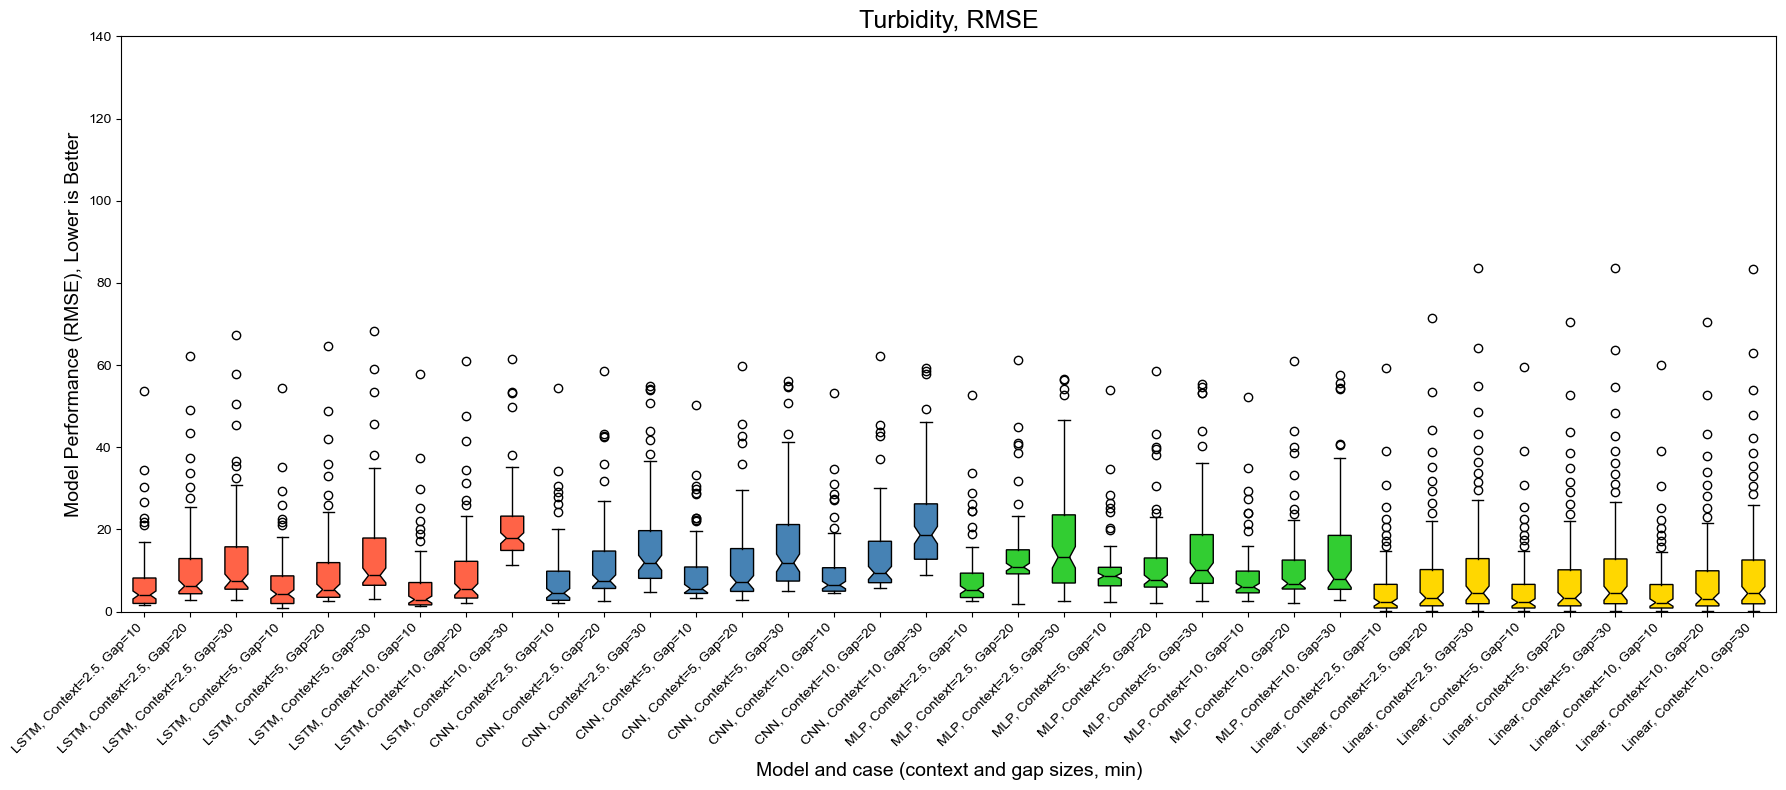

In [756]:
# Function to prepare data for the boxplot
def boxplot_data(parameter, metric):
    """
    Prepares data for combined boxplots.

    Args:
        parameter (str): The parameter of interest (e.g., 'Turbidity').
        metric (str): The metric for performance (e.g., 'SMAPE').

    Returns:
        combined_data (list): Data for all models across all scenarios.
        x_labels (list): Combined labels for each scenario and model.
        min_value (float): Minimum value for the y-axis.
        max_value (float): Maximum value for the y-axis.
    """
    # Getting values for different scenarios and cases
    splts = []
    for thr in range(100):
        splt = [mod for mod in heatmap_model_datasets(parameter, 'Test', metric, thr)]
        splts.append(splt)
    
    lg_values = [0, 1, 2]
    gp_values = [0, 1, 2]
    
    lg_sizes = [2.5, 5, 10]
    gp_sizes = [10, 20, 30]
    
    all_values = np.concatenate([arr.flatten() for sublist in splts for arr in sublist])
    
    # Find minimum and maximum values
    min_value = math.floor(np.nanmin(all_values) / 5) * 5
    max_value = math.ceil(np.nanmax(all_values) / 5) * 5
    
    # Initialize data for the combined plot
    combined_data = []
    x_labels = []

    # Iterate over all combinations of lg and gp
    for i, lg in enumerate(lg_values):
        for j, gp in enumerate(gp_values):
            LSTM_splts, CNN_splts, MLP_splts, lin_splts = [], [], [], []
            
            # Collect data for each model type based on the current lg and gp
            for split_ind, splt in enumerate(splts):
                for mdl_ind, mdl in enumerate(splt):
                    if mdl_ind == 0:
                        LSTM_splts.append(mdl[lg, gp])
                    elif mdl_ind == 1:
                        CNN_splts.append(mdl[lg, gp])
                    elif mdl_ind == 2:
                        MLP_splts.append(mdl[lg, gp])
                    elif mdl_ind == 3:
                        lin_splts.append(mdl[lg, gp])
            
            # Prepare data for combined boxplot
            combined_data.extend([LSTM_splts, CNN_splts, MLP_splts, lin_splts])
            x_labels.extend([
                f"LSTM, Context={lg_sizes[i]}, Gap={gp_sizes[j]}",
                f"CNN, Context={lg_sizes[i]}, Gap={gp_sizes[j]}",
                f"MLP, Context={lg_sizes[i]}, Gap={gp_sizes[j]}",
                f"Linear, Context={lg_sizes[i]}, Gap={gp_sizes[j]}"
            ])


    
    return combined_data, x_labels, min_value, max_value

def restructure_combined_data(combined_data, x_labels):
    # Define the custom order for model types
    model_order = {'LSTM': 0, 'CNN': 1, 'MLP': 2, 'Linear': 3}
    
    # Sort the x_labels by model (LSTM, CNN, MLP, Linear), then by Context, and finally by Gap
    sorted_labels = sorted(x_labels, key=lambda x: (
        model_order[x.split(',')[0].strip()],  # First, by the model order (LSTM, CNN, MLP, Linear)
        float(x.split('Context=')[1].split(',')[0]),  # Then by Context value
        int(x.split('Gap=')[1].split(',')[0])  # Finally by Gap value
    ))
    
    # Now we will create a new list for combined_data, sorted based on sorted_labels
    sorted_combined_data = []
    
    # Go through the sorted x_labels and collect the corresponding values from combined_data
    for label in sorted_labels:
        model_name = label.split(',')[0].strip()  # Extract the model name from the label
        # Find the index of the label in the original x_labels list
        index = x_labels.index(label)
        sorted_combined_data.append(combined_data[index])
    
    return sorted_combined_data, sorted_labels







# Main plotting loop
par_for_graph = 'Turbidity'
for metric_for_graph in ['RMSE']:
    combined_data,x_labels, min_value, max_value = boxplot_data(par_for_graph, metric_for_graph)
    combined_data, x_labels = restructure_combined_data(combined_data, x_labels)


    # Colors for each model type
    model_colors = {
        "LSTM": '#FF6347',  # Tomato
        "CNN": '#4682B4',   # SteelBlue
        "MLP": '#32CD32',   # LimeGreen
        "Linear": '#FFD700' # Gold
    }
    
    # Plot the combined boxplot
    fig, ax = plt.subplots(figsize=(18, 8))
    boxplot = ax.boxplot(combined_data, labels=x_labels, notch=True, patch_artist=True)
    
    # Apply the colors to the boxes based on the model
    for patch, label in zip(boxplot['boxes'], x_labels):
        if "LSTM" in label:
            patch.set_facecolor(model_colors["LSTM"])
        elif "CNN" in label:
            patch.set_facecolor(model_colors["CNN"])
        elif "MLP" in label:
            patch.set_facecolor(model_colors["MLP"])
        elif "Linear" in label:
            patch.set_facecolor(model_colors["Linear"])
    
    # Change the color of the medians to black
    for median in boxplot['medians']:
        median.set_color('black')
    
    # Customize plot appearance
    ax.set_ylim(min_value, max_value)
    ax.set_title(f"{par_for_graph}, {metric_for_graph}", fontsize=18)
    ax.set_xlabel("Model and case (context and gap sizes, min)", fontsize=14)
    ax.set_ylabel(f"Model Performance ({metric_for_graph}), Lower is Better", fontsize=14)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha="right")
    
    # Adjust layout and display the plot
    plt.tight_layout()
    plt.show()
    

#### Boxplot filtered by model and gap size within the model

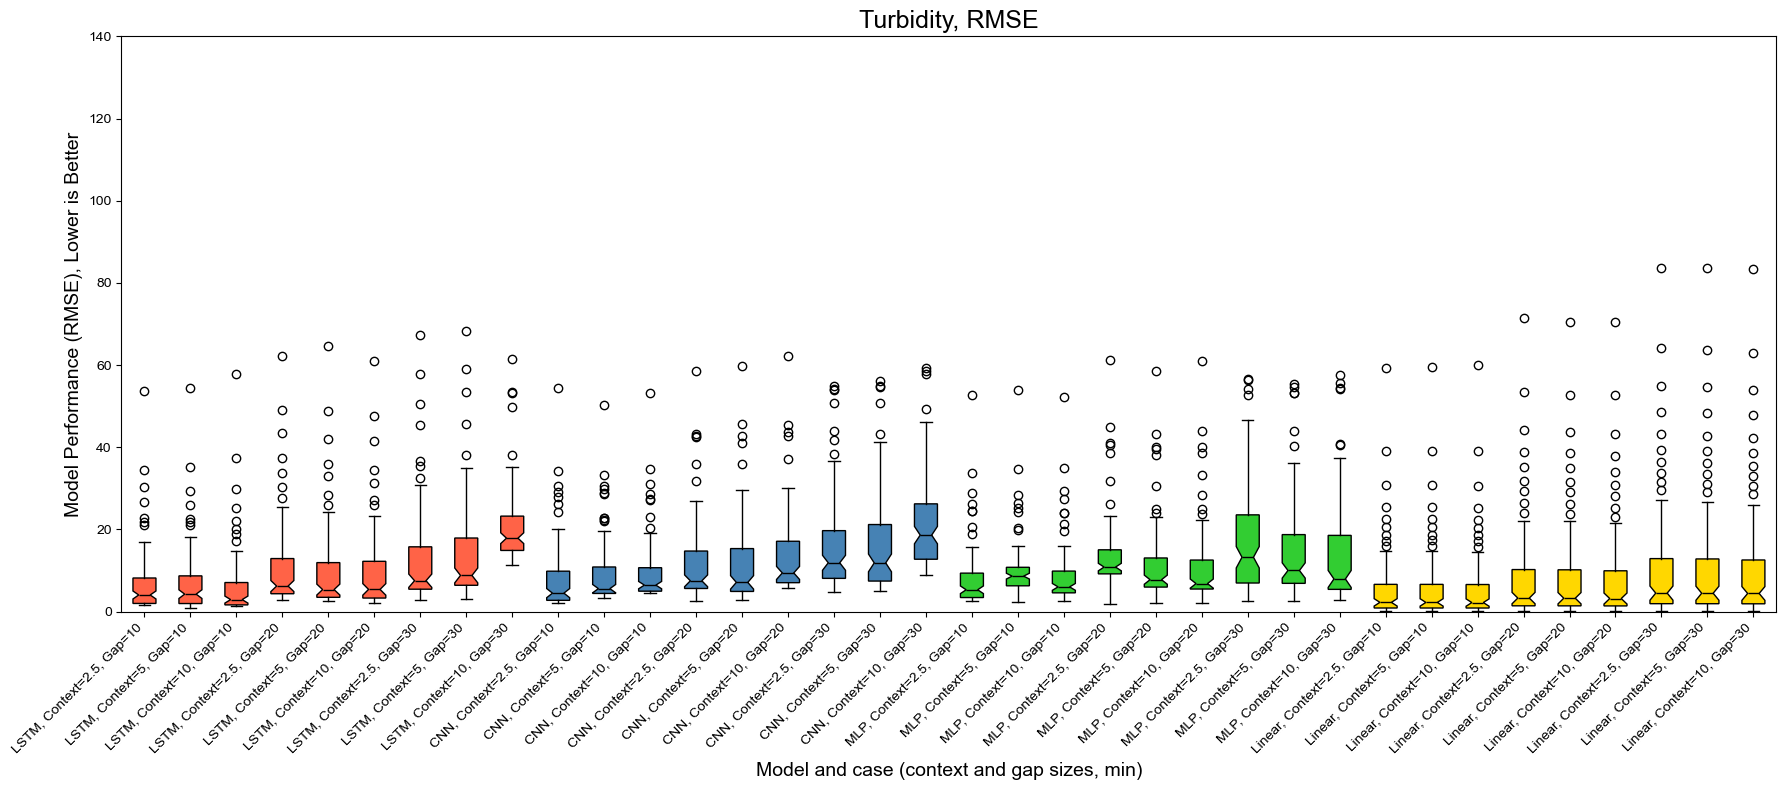

In [757]:
# Function to prepare data for the boxplot
def boxplot_data(parameter, metric):
    """
    Prepares data for combined boxplots.

    Args:
        parameter (str): The parameter of interest (e.g., 'Turbidity').
        metric (str): The metric for performance (e.g., 'SMAPE').

    Returns:
        combined_data (list): Data for all models across all scenarios.
        x_labels (list): Combined labels for each scenario and model.
        min_value (float): Minimum value for the y-axis.
        max_value (float): Maximum value for the y-axis.
    """
    # Getting values for different scenarios and cases
    splts = []
    for thr in range(100):
        splt = [mod for mod in heatmap_model_datasets(parameter, 'Test', metric, thr)]
        splts.append(splt)
    
    lg_values = [0, 1, 2]
    gp_values = [0, 1, 2]
    
    lg_sizes = [2.5, 5, 10]
    gp_sizes = [10, 20, 30]
    
    all_values = np.concatenate([arr.flatten() for sublist in splts for arr in sublist])
    
    # Find minimum and maximum values
    min_value = math.floor(np.nanmin(all_values) / 5) * 5
    max_value = math.ceil(np.nanmax(all_values) / 5) * 5
    
    # Initialize data for the combined plot
    combined_data = []
    x_labels = []

    # Iterate over all combinations of lg and gp
    for i, lg in enumerate(lg_values):
        for j, gp in enumerate(gp_values):
            LSTM_splts, CNN_splts, MLP_splts, lin_splts = [], [], [], []
            
            # Collect data for each model type based on the current lg and gp
            for split_ind, splt in enumerate(splts):
                for mdl_ind, mdl in enumerate(splt):
                    if mdl_ind == 0:
                        LSTM_splts.append(mdl[lg, gp])
                    elif mdl_ind == 1:
                        CNN_splts.append(mdl[lg, gp])
                    elif mdl_ind == 2:
                        MLP_splts.append(mdl[lg, gp])
                    elif mdl_ind == 3:
                        lin_splts.append(mdl[lg, gp])
            
            # Prepare data for combined boxplot
            combined_data.extend([LSTM_splts, CNN_splts, MLP_splts, lin_splts])
            x_labels.extend([
                f"LSTM, Context={lg_sizes[i]}, Gap={gp_sizes[j]}",
                f"CNN, Context={lg_sizes[i]}, Gap={gp_sizes[j]}",
                f"MLP, Context={lg_sizes[i]}, Gap={gp_sizes[j]}",
                f"Linear, Context={lg_sizes[i]}, Gap={gp_sizes[j]}"
            ])


    
    return combined_data, x_labels, min_value, max_value


def restructure_combined_data(combined_data, x_labels):
    # Define the custom order for model types
    model_order = {'LSTM': 0, 'CNN': 1, 'MLP': 2, 'Linear': 3}
    context_sizes = [2.5, 5, 10]
    gap_sizes = [10, 20, 30]
    
    # Sort the x_labels by model, then by gap size, then by context size
    sorted_labels = sorted(x_labels, key=lambda x: (
        model_order[x.split(',')[0].strip()],  # First, by the model order (LSTM, CNN, MLP, Linear)
        gap_sizes.index(int(x.split('Gap=')[1].split(',')[0])),  # Then by Gap (10, 20, 30)
        context_sizes.index(float(x.split('Context=')[1].split(',')[0]))  # Finally by Context (2.5, 5, 10)
    ))
    
    # Initialize a dictionary to hold lists of data, grouped by model and gap size
    model_gap_data_dict = {'LSTM': {}, 'CNN': {}, 'MLP': {}, 'Linear': {}}
    
    # Group data by model and gap size
    for label, data in zip(x_labels, combined_data):
        model_name = label.split(',')[0].strip()  # Extract the model name
        gap_value = int(label.split('Gap=')[1].split(',')[0])  # Extract the gap value
        
        # Initialize the dictionary for the model if not already initialized
        if gap_value not in model_gap_data_dict[model_name]:
            model_gap_data_dict[model_name][gap_value] = []
        
        # Append the data for this model and gap size
        model_gap_data_dict[model_name][gap_value].append((label, data))
    
    # Now, flatten the data in sorted order (by model, then gap size, then context)
    sorted_combined_data = []
    sorted_labels = []

    for model in model_order:
        # For each model, sort by gap size (10, 20, 30)
        for gap in gap_sizes:
            model_gap_data = model_gap_data_dict[model].get(gap, [])
            
            # Sort by context size (2.5, 5, 10) within each gap size
            sorted_model_gap_data = sorted(model_gap_data, key=lambda x: (
                context_sizes.index(float(x[0].split('Context=')[1].split(',')[0]))  # Sort by Context (2.5, 5, 10)
            ))

            # Append sorted data and labels
            for label, data in sorted_model_gap_data:
                sorted_labels.append(label)
                sorted_combined_data.append(data)

    return sorted_combined_data, sorted_labels





# Main plotting loop
par_for_graph = 'Turbidity'
for metric_for_graph in ['RMSE']:
    combined_data,x_labels, min_value, max_value = boxplot_data(par_for_graph, metric_for_graph)
    combined_data, x_labels = restructure_combined_data(combined_data, x_labels)


    # Colors for each model type
    model_colors = {
        "LSTM": '#FF6347',  # Tomato
        "CNN": '#4682B4',   # SteelBlue
        "MLP": '#32CD32',   # LimeGreen
        "Linear": '#FFD700' # Gold
    }
    
    # Plot the combined boxplot
    fig, ax = plt.subplots(figsize=(18, 8))
    boxplot = ax.boxplot(combined_data, labels=x_labels, notch=True, patch_artist=True)
    
    # Apply the colors to the boxes based on the model
    for patch, label in zip(boxplot['boxes'], x_labels):
        if "LSTM" in label:
            patch.set_facecolor(model_colors["LSTM"])
        elif "CNN" in label:
            patch.set_facecolor(model_colors["CNN"])
        elif "MLP" in label:
            patch.set_facecolor(model_colors["MLP"])
        elif "Linear" in label:
            patch.set_facecolor(model_colors["Linear"])
    
    # Change the color of the medians to black
    for median in boxplot['medians']:
        median.set_color('black')
    
    # Customize plot appearance
    ax.set_ylim(min_value, max_value)
    ax.set_title(f"{par_for_graph}, {metric_for_graph}", fontsize=18)
    ax.set_xlabel("Model and case (context and gap sizes, min)", fontsize=14)
    ax.set_ylabel(f"Model Performance ({metric_for_graph}), Lower is Better", fontsize=14)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha="right")
    
    # Adjust layout and display the plot
    plt.tight_layout()
    plt.show()

#### Best boxplot, filtered by model and gap size and also better colorcoded and added functionality for extraction of the numerical stats

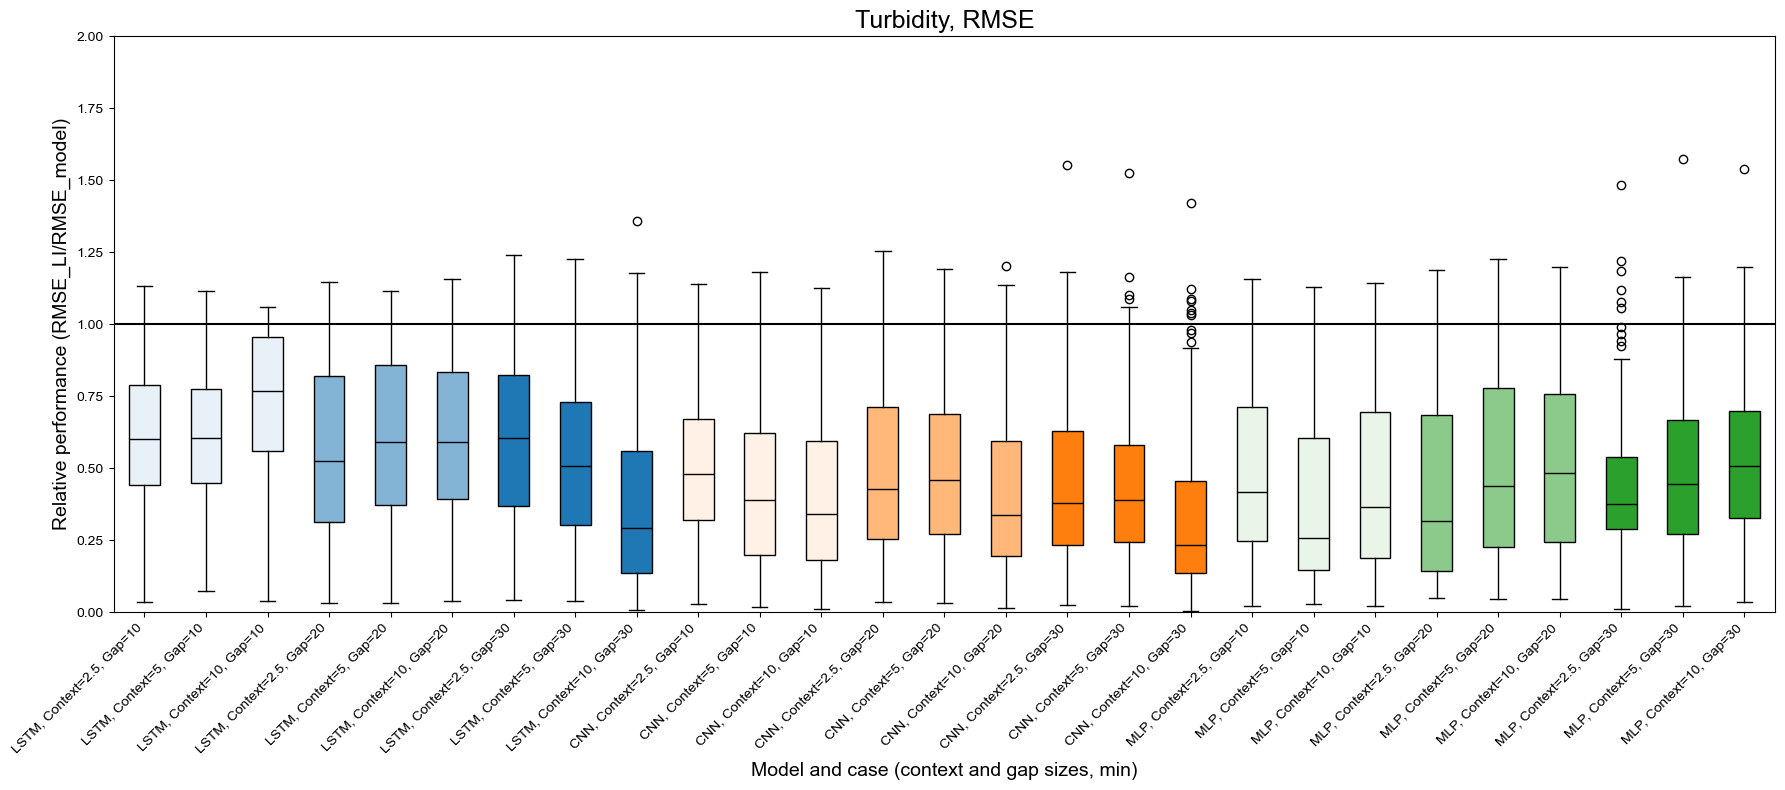

In [758]:
# Function to prepare data for the boxplot
def boxplot_data(parameter, metric):
    """
    Prepares data for combined boxplots.

    Args:
        parameter (str): The parameter of interest (e.g., 'Turbidity').
        metric (str): The metric for performance (e.g., 'SMAPE').

    Returns:
        combined_data (list): Data for all models across all scenarios.
        x_labels (list): Combined labels for each scenario and model.
        min_value (float): Minimum value for the y-axis.
        max_value (float): Maximum value for the y-axis.
    """
    # Getting values for different scenarios and cases
    splts = []
    for thr in range(100):
        splt = [mod for mod in heatmap_model_datasets(parameter, 'Test', metric, thr)]
        splts.append(splt)
    
    lg_values = [0, 1, 2]
    gp_values = [0, 1, 2]
    
    lg_sizes = [2.5, 5, 10]
    gp_sizes = [10, 20, 30]
    
    all_values = np.concatenate([arr.flatten() for sublist in splts for arr in sublist])
    
    # Find minimum and maximum values
    min_value = math.floor(np.nanmin(all_values) / 5) * 5
    max_value = math.ceil(np.nanmax(all_values) / 5) * 5
    
    # Initialize data for the combined plot
    combined_data = []
    x_labels = []

    # Iterate over all combinations of lg and gp
    for i, lg in enumerate(lg_values):
        for j, gp in enumerate(gp_values):
            LSTM_splts, CNN_splts, MLP_splts, lin_splts = [], [], [], []
            
            # Collect data for each model type based on the current lg and gp
            for split_ind, splt in enumerate(splts):
                for mdl_ind, mdl in enumerate(splt):
                    if mdl_ind == 0:
                        LSTM_splts.append(mdl[lg, gp])
                    elif mdl_ind == 1:
                        CNN_splts.append(mdl[lg, gp])
                    elif mdl_ind == 2:
                        MLP_splts.append(mdl[lg, gp])
                    elif mdl_ind == 3:
                        lin_splts.append(mdl[lg, gp])


            # Convert lists to arrays for processing
            LSTM_splts = np.array(LSTM_splts)
            CNN_splts = np.array(CNN_splts)
            MLP_splts = np.array(MLP_splts)
            lin_splts = np.array(lin_splts)
    
            # # Calculate the difference between CNN and Linear interpolation
            # diff_LSTM = (lin_splts - LSTM_splts)/lin_splts*100
            # diff_CNN = (lin_splts - CNN_splts)/lin_splts*100
            # diff_MLP = (lin_splts - MLP_splts)/lin_splts*100

            # Calculate the difference between CNN and Linear interpolation
            diff_LSTM = (lin_splts/LSTM_splts)
            diff_CNN = (lin_splts/CNN_splts)
            diff_MLP = (lin_splts/MLP_splts)

            
            # Prepare data for combined boxplot
            combined_data.extend([diff_LSTM, diff_CNN, diff_MLP])
            x_labels.extend([
                f"LSTM, Context={lg_sizes[i]}, Gap={gp_sizes[j]}",
                f"CNN, Context={lg_sizes[i]}, Gap={gp_sizes[j]}",
                f"MLP, Context={lg_sizes[i]}, Gap={gp_sizes[j]}"
            ])


    
    return combined_data, x_labels, min_value, max_value


def restructure_combined_data(combined_data, x_labels):
    # Define the custom order for model types
    model_order = {'LSTM': 0, 'CNN': 1, 'MLP': 2, 'Linear': 3}
    context_sizes = [2.5, 5, 10]
    gap_sizes = [10, 20, 30]
    
    # Sort the x_labels by model, then by gap size, then by context size
    sorted_labels = sorted(x_labels, key=lambda x: (
        model_order[x.split(',')[0].strip()],  # First, by the model order (LSTM, CNN, MLP, Linear)
        gap_sizes.index(int(x.split('Gap=')[1].split(',')[0])),  # Then by Gap (10, 20, 30)
        context_sizes.index(float(x.split('Context=')[1].split(',')[0]))  # Finally by Context (2.5, 5, 10)
    ))
    
    # Initialize a dictionary to hold lists of data, grouped by model and gap size
    model_gap_data_dict = {'LSTM': {}, 'CNN': {}, 'MLP': {}, 'Linear': {}}
    
    # Group data by model and gap size
    for label, data in zip(x_labels, combined_data):
        model_name = label.split(',')[0].strip()  # Extract the model name
        gap_value = int(label.split('Gap=')[1].split(',')[0])  # Extract the gap value
        
        # Initialize the dictionary for the model if not already initialized
        if gap_value not in model_gap_data_dict[model_name]:
            model_gap_data_dict[model_name][gap_value] = []
        
        # Append the data for this model and gap size
        model_gap_data_dict[model_name][gap_value].append((label, data))
    
    # Now, flatten the data in sorted order (by model, then gap size, then context)
    sorted_combined_data = []
    sorted_labels = []

    for model in model_order:
        # For each model, sort by gap size (10, 20, 30)
        for gap in gap_sizes:
            model_gap_data = model_gap_data_dict[model].get(gap, [])
            
            # Sort by context size (2.5, 5, 10) within each gap size
            sorted_model_gap_data = sorted(model_gap_data, key=lambda x: (
                context_sizes.index(float(x[0].split('Context=')[1].split(',')[0]))  # Sort by Context (2.5, 5, 10)
            ))

            # Append sorted data and labels
            for label, data in sorted_model_gap_data:
                sorted_labels.append(label)
                sorted_combined_data.append(data)

    return sorted_combined_data, sorted_labels



# Function to generate shades for a base color
def generate_shades(base_color, num_shades):
    """
    Generates a list of shades for a given base color.
    
    Args:
        base_color (str): The base color in any matplotlib-compatible format.
        num_shades (int): Number of shades to generate.
        
    Returns:
        list: A list of shades ranging from light to base color.
    """
    rgba = to_rgba(base_color)
    shades = [(rgba[0], rgba[1], rgba[2], alpha) for alpha in np.linspace(0.1, 1, num_shades)]
    return shades

# Define colors for each model type and generate shades for gap sizes
model_colors = {
    "LSTM": '#1f77b4',  # Blue
    "CNN": '#FF7F0E',   # Orange
    "MLP": '#2CA02C',   # Green
}

gap_sizes = [10, 20, 30]
model_shades = {model: generate_shades(color, len(gap_sizes)) for model, color in model_colors.items()}

# Main plotting loop
par_for_graph = 'Turbidity'
for metric_for_graph in ['RMSE']:
    # Original data
    combined_data, x_labels, min_value, max_value = boxplot_data(par_for_graph, metric_for_graph)
    # Sorted data (grouped by model and then by gap size within each model)
    combined_data, x_labels = restructure_combined_data(combined_data, x_labels)

    # For the case when there is no enough data for 99% percentile and it makes NaN, to plot figure correctly - remove NaN
    combined_data = [pd.Series(box).dropna() for box in combined_data]
    
    # Plot the combined boxplot
    fig, ax = plt.subplots(figsize=(18, 8))
    ax.axhline(1, color = 'black')
    boxplot = ax.boxplot(combined_data, labels=x_labels, notch=False, patch_artist=True)
    
    # Apply the shades to the boxes based on the model and gap size
    for patch, label in zip(boxplot['boxes'], x_labels):
        model_name = label.split(',')[0].strip()  # Extract model name
        gap_size = int(label.split('Gap=')[1].split(',')[0])  # Extract gap size
        
        # Get the index of the gap size
        gap_index = gap_sizes.index(gap_size)
        
        # Set the face color using the model's shade for this gap size
        patch.set_facecolor(model_shades[model_name][gap_index])
    
    # Change the color of the medians to black
    for median in boxplot['medians']:
        median.set_color('black')
    
    # Customize plot appearance
    ax.set_ylim(0, 2)
    ax.set_title(f"{par_for_graph}, {metric_for_graph}", fontsize=18)
    ax.set_xlabel("Model and case (context and gap sizes, min)", fontsize=14)
    ax.set_ylabel(f"Relative performance ({metric_for_graph}_LI/{metric_for_graph}_model)", fontsize=14)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha="right")
    # Adjust layout and display the plot
    plt.tight_layout()
    plt.show()
    if metric_for_graph == 'SMAPE':
        boxplot_SMAPE = boxplot
    elif metric_for_graph == 'RMSE':
        boxplot_RMSE = boxplot

    


#### Best boxplot, filtered by model and gap size and also better colorcoded and added functionality for extraction of the numerical stats

In [759]:
# Reshape for boxplot
LSTM_cross_idx_list_turb_box = np.reshape(LSTM_cross_idx_list_turb, (3, 3)).T.flatten()
CNN_cross_idx_list_turb_box = np.reshape(CNN_cross_idx_list_turb, (3, 3)).T.flatten()
MLP_cross_idx_list_turb_box = np.reshape(MLP_cross_idx_list_turb, (3, 3)).T.flatten()

LSTM_cross_idx_list_cond_box = np.reshape(LSTM_cross_idx_list_cond, (3, 3)).T.flatten()
CNN_cross_idx_list_cond_box = np.reshape(CNN_cross_idx_list_cond, (3, 3)).T.flatten()
MLP_cross_idx_list_cond_box = np.reshape(MLP_cross_idx_list_cond, (3, 3)).T.flatten()

LSTM_cross_idx_list_pH_box = np.reshape(LSTM_cross_idx_list_pH, (3, 3)).T.flatten()
CNN_cross_idx_list_pH_box = np.reshape(CNN_cross_idx_list_pH, (3, 3)).T.flatten()
MLP_cross_idx_list_pH_box = np.reshape(MLP_cross_idx_list_pH, (3, 3)).T.flatten()



LSTM_mean_list_turb_box = np.reshape(LSTM_mean_list_turb, (3, 3)).T.flatten()
CNN_mean_list_turb_box = np.reshape(CNN_mean_list_turb, (3, 3)).T.flatten()
MLP_mean_list_turb_box = np.reshape(MLP_mean_list_turb, (3, 3)).T.flatten()

LSTM_mean_list_cond_box = np.reshape(LSTM_mean_list_cond, (3, 3)).T.flatten()
CNN_mean_list_cond_box = np.reshape(CNN_mean_list_cond, (3, 3)).T.flatten()
MLP_mean_list_cond_box = np.reshape(MLP_mean_list_cond, (3, 3)).T.flatten()

LSTM_mean_list_pH_box = np.reshape(LSTM_mean_list_pH, (3, 3)).T.flatten()
CNN_mean_list_pH_box = np.reshape(CNN_mean_list_pH, (3, 3)).T.flatten()
MLP_mean_list_pH_box = np.reshape(MLP_mean_list_pH, (3, 3)).T.flatten()

NameError: name 'LSTM_cross_idx_list_turb' is not defined

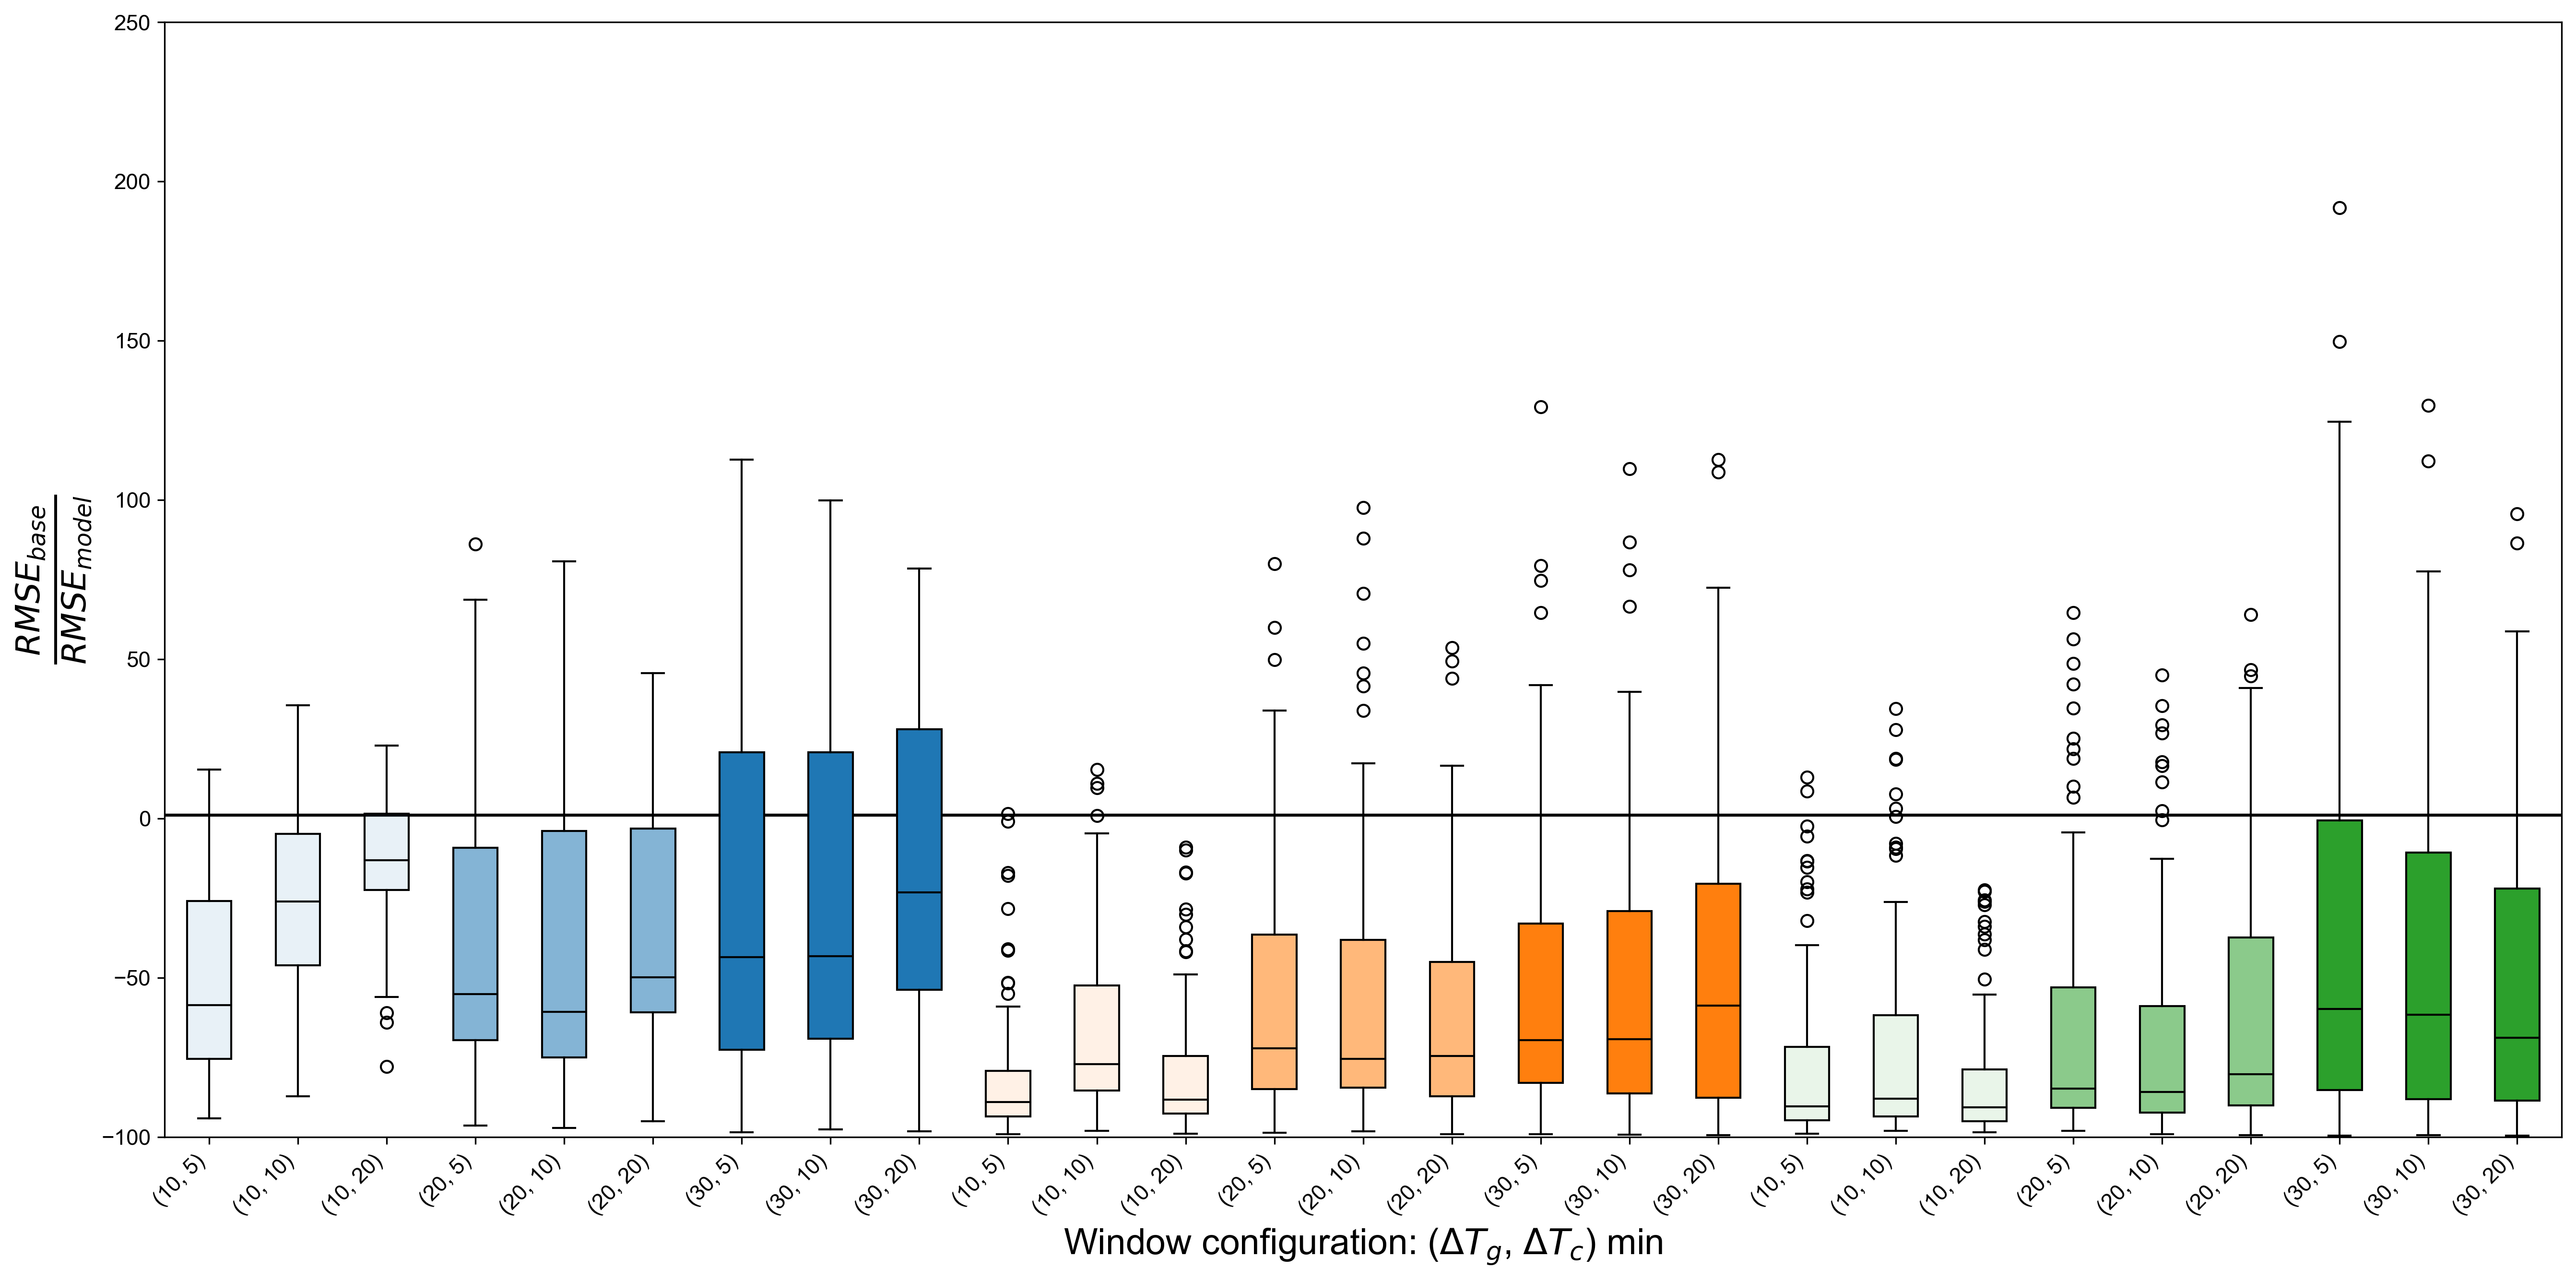

In [760]:
def add_color_legend(ax, model_colors, gap_sizes):
    """
    Adds a legend for the color gradients explaining the combination of models and gap sizes.
    
    Args:
        ax: The axis to which the legend is added.
        model_colors (dict): A dictionary mapping models to their base colors.
        gap_sizes (list): The gap sizes corresponding to the gradients.
    """
    import matplotlib.patches as mpatches
    
    # Create patches for each gradient and model
    legend_elements = []
    for model, color in model_colors.items():
        shades = generate_shades(color, len(gap_sizes))
        for i, shade in enumerate(shades):
            patch = mpatches.Patch(facecolor=shade, label=f"{model}, $\Delta T_{{g}}$ = {gap_sizes[i]} min")
            legend_elements.append(patch)
    
    # Add the legend to the axis
    ax.legend(handles=legend_elements, loc='upper center', fontsize=18, bbox_to_anchor=(1.2, 0.8), ncol=1)



# Function to prepare data for the boxplot
def boxplot_data(parameter, metric):
    """
    Prepares data for combined boxplots.

    Args:
        parameter (str): The parameter of interest (e.g., 'Turbidity').
        metric (str): The metric for performance (e.g., 'SMAPE').

    Returns:
        combined_data (list): Data for all models across all scenarios.
        x_labels (list): Combined labels for each scenario and model.
        min_value (float): Minimum value for the y-axis.
        max_value (float): Maximum value for the y-axis.
    """
    # Getting values for different scenarios and cases
    splts = []
    for thr in range(100):
        splt = [mod for mod in heatmap_model_datasets(parameter, 'Test', metric, thr)]
        splts.append(splt)
    
    lg_values = [0, 1, 2]
    gp_values = [0, 1, 2]
    
    lg_sizes = [5, 10, 20]
    gp_sizes = [10, 20, 30]
    
    all_values = np.concatenate([arr.flatten() for sublist in splts for arr in sublist])
    
    # Find minimum and maximum values
    min_value = math.floor(np.nanmin(all_values) / 5) * 5
    max_value = math.ceil(np.nanmax(all_values) / 5) * 5
    
    # Initialize data for the combined plot
    combined_data = []
    x_labels = []

    # Iterate over all combinations of lg and gp
    for i, lg in enumerate(lg_values):
        for j, gp in enumerate(gp_values):
            LSTM_splts, CNN_splts, MLP_splts, lin_splts = [], [], [], []
            
            # Collect data for each model type based on the current lg and gp
            for split_ind, splt in enumerate(splts):
                for mdl_ind, mdl in enumerate(splt):
                    if mdl_ind == 0:
                        LSTM_splts.append(mdl[lg, gp])
                    elif mdl_ind == 1:
                        CNN_splts.append(mdl[lg, gp])
                    elif mdl_ind == 2:
                        MLP_splts.append(mdl[lg, gp])
                    elif mdl_ind == 3:
                        lin_splts.append(mdl[lg, gp])


            # Convert lists to arrays for processing
            LSTM_splts = np.array(LSTM_splts)
            CNN_splts = np.array(CNN_splts)
            MLP_splts = np.array(MLP_splts)
            lin_splts = np.array(lin_splts)
    
            # Calculate the difference between a model and Linear interpolation
            diff_LSTM = (lin_splts - LSTM_splts)/LSTM_splts*100
            diff_CNN = (lin_splts - CNN_splts)/CNN_splts*100
            diff_MLP = (lin_splts - MLP_splts)/MLP_splts*100

            # # Calculate the difference between CNN and Linear interpolation
            # diff_LSTM = (lin_splts/LSTM_splts)
            # diff_CNN = (lin_splts/CNN_splts)
            # diff_MLP = (lin_splts/MLP_splts)

            
            # Prepare data for combined boxplot
            combined_data.extend([diff_LSTM, diff_CNN, diff_MLP])
            x_labels.extend([
                f"LSTM, $\Delta T_{{g}}$ = {gp_sizes[j]}, $\Delta T_{{c}}$ = {lg_sizes[i]}",
                f"CNN, $\Delta T_{{g}}$ = {gp_sizes[j]}, $\Delta T_{{c}}$ = {lg_sizes[i]}",
                f"MLP, $\Delta T_{{g}}$ = {gp_sizes[j]}, $\Delta T_{{c}}$ = {lg_sizes[i]}"
            ])


    
    return combined_data, x_labels, min_value, max_value


def restructure_combined_data(combined_data, x_labels):
    # Define the custom order for model types
    model_order = {'LSTM': 0, 'CNN': 1, 'MLP': 2, 'Linear': 3}
    context_sizes = [5, 10, 20]
    gap_sizes = [10, 20, 30]
    
    # Sort the x_labels by model, then by gap size, then by context size
    sorted_labels = sorted(x_labels, key=lambda x: (
        model_order[x.split(',')[0].strip()],  # First, by the model order (LSTM, CNN, MLP, Linear)
        gap_sizes.index(int(x.split(f'$\Delta T_{{g}}$ = ')[1].split(',')[0])),  # Then by Gap (10, 20, 30)
        context_sizes.index(float(x.split(f'$\Delta T_{{c}}$ = ')[1].split(',')[0]))  # Finally by Context (2.5, 5, 10)
    ))
    
    # Initialize a dictionary to hold lists of data, grouped by model and gap size
    model_gap_data_dict = {'LSTM': {}, 'CNN': {}, 'MLP': {}, 'Linear': {}}
    
    # Group data by model and gap size
    for label, data in zip(x_labels, combined_data):
        model_name = label.split(',')[0].strip()  # Extract the model name
        gap_value = int(label.split(f'$\Delta T_{{g}}$ = ')[1].split(',')[0])  # Extract the gap value
        
        # Initialize the dictionary for the model if not already initialized
        if gap_value not in model_gap_data_dict[model_name]:
            model_gap_data_dict[model_name][gap_value] = []
        
        # Append the data for this model and gap size
        model_gap_data_dict[model_name][gap_value].append((label, data))
    
    # Now, flatten the data in sorted order (by model, then gap size, then context)
    sorted_combined_data = []
    sorted_labels = []

    for model in model_order:
        # For each model, sort by gap size (10, 20, 30)
        for gap in gap_sizes:
            model_gap_data = model_gap_data_dict[model].get(gap, [])
            
            # Sort by context size (2.5, 5, 10) within each gap size
            sorted_model_gap_data = sorted(model_gap_data, key=lambda x: (
                context_sizes.index(float(x[0].split(f'$\Delta T_{{c}}$ = ')[1].split(',')[0]))  # Sort by Context (2.5, 5, 10)
            ))

            # Append sorted data and labels
            for label, data in sorted_model_gap_data:
                sorted_labels.append(label)
                sorted_combined_data.append(data)

    return sorted_combined_data, sorted_labels



# Function to generate shades for a base color
def generate_shades(base_color, num_shades):
    """
    Generates a list of shades for a given base color.
    
    Args:
        base_color (str): The base color in any matplotlib-compatible format.
        num_shades (int): Number of shades to generate.
        
    Returns:
        list: A list of shades ranging from light to base color.
    """
    rgba = to_rgba(base_color)
    shades = [(rgba[0], rgba[1], rgba[2], alpha) for alpha in np.linspace(0.1, 1, num_shades)]
    return shades

# Define colors for each model type and generate shades for gap sizes
model_colors = {
    "LSTM": '#1f77b4',  # Blue
    "CNN": '#FF7F0E',   # Orange
    "MLP": '#2CA02C',   # Green
}

gap_sizes = [10, 20, 30]
model_shades = {model: generate_shades(color, len(gap_sizes)) for model, color in model_colors.items()}

# Main plotting loop
par_for_graph = 'Conductivity'
for metric_for_graph in ['RMSE']:
    # Original data
    combined_data, x_labels, min_value, max_value = boxplot_data(par_for_graph, metric_for_graph)
    # Sorted data (grouped by model and then by gap size within each model)
    combined_data, x_labels = restructure_combined_data(combined_data, x_labels)
    x_labels_cleaned = [entry.split(", ", 1)[1] for entry in x_labels]
    numerical_tuples = [tuple(map(int, re.findall(r'\d+', label))) for label in x_labels_cleaned]
                       
    # For the case when there is no enough data for 99% percentile and it makes NaN, to plot figure correctly - remove NaN
    combined_data = [pd.Series(box).dropna() for box in combined_data]
    
    # Plot the combined boxplot
    fig, ax = plt.subplots(figsize=(18, 9), dpi=300)
    ax.axhline(1, color = 'black')
    boxplot = ax.boxplot(combined_data, labels=numerical_tuples, notch=False, patch_artist=True)
    
    # Apply the shades to the boxes based on the model and gap size
    for patch, label in zip(boxplot['boxes'], x_labels):
        model_name = label.split(',')[0].strip()  # Extract model name
        gap_size = int(label.split(f'$\Delta T_{{g}}$ = ')[1].split(',')[0])  # Extract gap size
        
        # Get the index of the gap size
        gap_index = gap_sizes.index(gap_size)
        
        # Set the face color using the model's shade for this gap size
        patch.set_facecolor(model_shades[model_name][gap_index])
    
    # Add the color gradient legend
    # add_color_legend(ax, model_colors, gap_sizes)
    
    # Change the color of the medians to black
    for median in boxplot['medians']:
        median.set_color('black')


    # Add MSES and ARP above each boxplot
    # if par_for_graph == 'Turbidity': 
    #     combined_MSES =  np.concatenate((LSTM_cross_idx_list_turb_box, CNN_cross_idx_list_turb_box, MLP_cross_idx_list_turb_box), axis = 0)
    #     combined_ARP =  np.concatenate((LSTM_mean_list_turb_box, CNN_mean_list_turb_box, MLP_mean_list_turb_box), axis = 0)
    # elif par_for_graph == 'Conductivity': 
    #     combined_MSES =  np.concatenate((LSTM_cross_idx_list_cond_box, CNN_cross_idx_list_cond_box, MLP_cross_idx_list_cond_box), axis = 0)
    #     combined_ARP =  np.concatenate((LSTM_mean_list_cond_box, CNN_mean_list_cond_box, MLP_mean_list_cond_box), axis = 0)
    # elif par_for_graph == 'pH': 
    #     combined_MSES =  np.concatenate((LSTM_cross_idx_list_pH_box, CNN_cross_idx_list_pH_box, MLP_cross_idx_list_pH_box), axis = 0)
    #     combined_ARP =  np.concatenate((LSTM_mean_list_pH_box, CNN_mean_list_pH_box, MLP_mean_list_pH_box), axis = 0)
        
    # for idx, MSES in enumerate(combined_MSES):
    #     x_pos = idx + 1  # Boxplot x-coordinates are 1-based
    #     y_pos = 3.1  # Place above the y-axis range
    #     ax.text(x_pos, y_pos, MSES, fontsize=9, ha="center", va="bottom", color="black")
    # for idx, ARP in enumerate(combined_ARP):
    #     x_pos = idx + 1  # Boxplot x-coordinates are 1-based
    #     y_pos = 3.2  # Place above the y-axis range
    #     ax.text(x_pos, y_pos, round(ARP, 3), fontsize=9, ha="center", va="bottom", color="black")
        
    # # ax.text(0, 3.1, "MSES:", fontsize=10, ha="center", va="bottom", color="black")
    # ax.text(0, 3.2, "ARP:", fontsize=10, ha="center", va="bottom", color="black")
    
    # Customize plot appearance
    ax.set_ylim(-100, 250)
    # ax.set_title(f"{par_for_graph}", fontsize=24)
    ax.set_xlabel("Window configuration: ($\Delta T_{{g}}$, $\Delta T_{{c}}$) min", fontsize=18)
    ax.set_ylabel(r"$\frac{{" + metric_for_graph + r"_{base}}}{" + metric_for_graph + r"_{model}}$", fontsize=24)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha="right", fontsize=11)
    plt.yticks(fontsize=11)
    # Adjust layout and display the plot
    plt.tight_layout()
    plt.show()
    if metric_for_graph == 'SMAPE':
        boxplot_SMAPE = boxplot
    elif metric_for_graph == 'RMSE':
        boxplot_RMSE = boxplot

#### Best boxplot, filtered by model and gap size and also better colorcoded and added functionality for extraction of the numerical stats ONLY FOR DIFFICULT 20% OF THE CASES

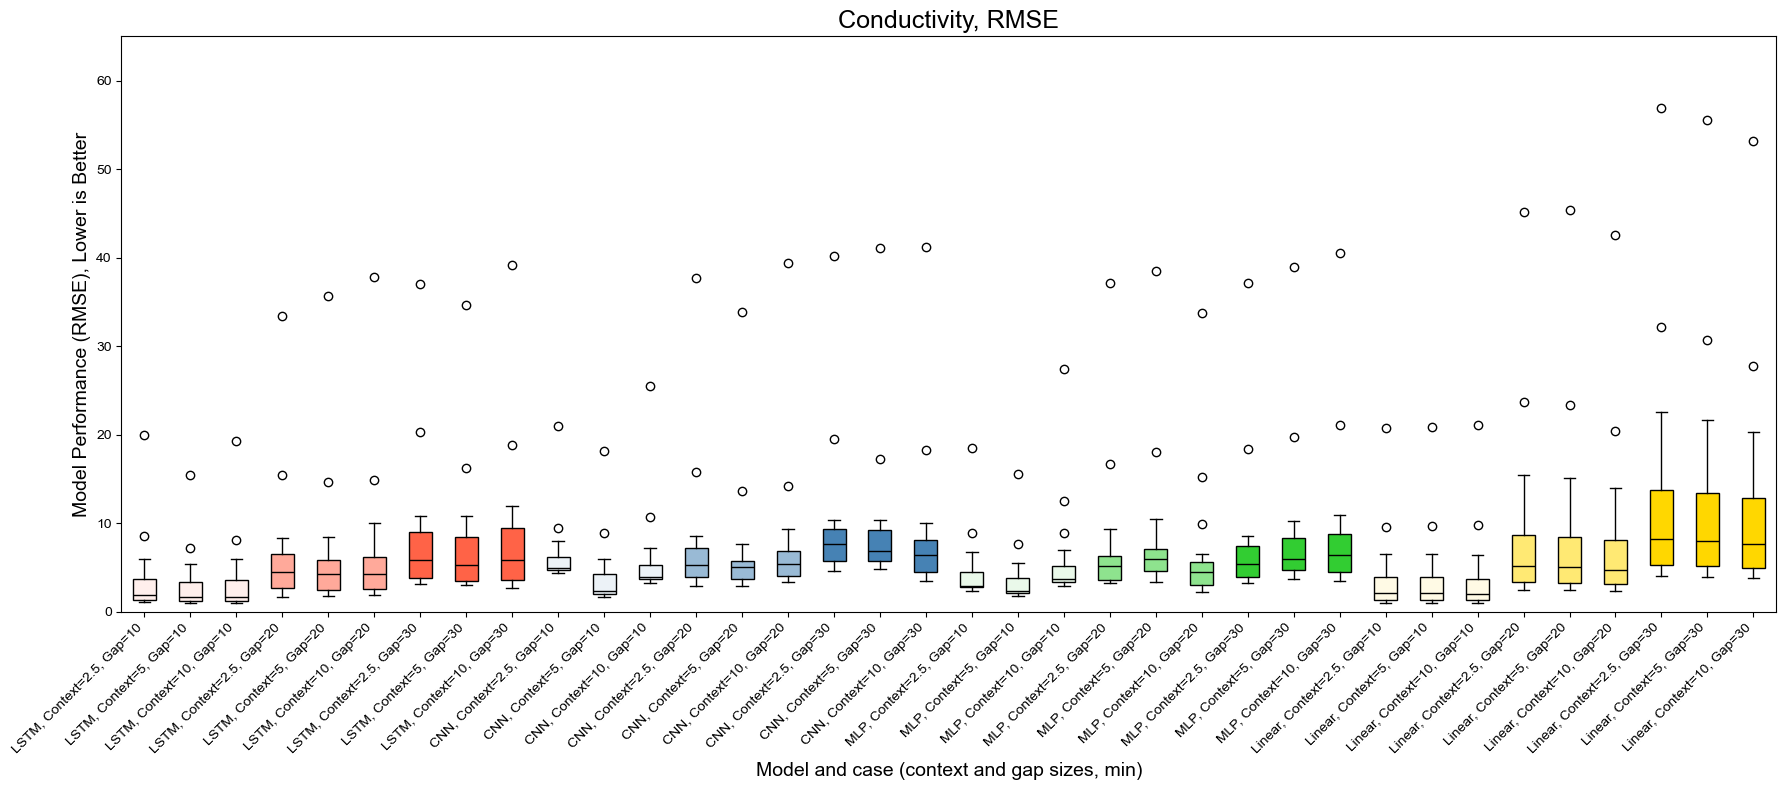

In [762]:
# Function to prepare data for the boxplot
def boxplot_data(parameter, metric):
    """
    Prepares data for combined boxplots.

    Args:
        parameter (str): The parameter of interest (e.g., 'Turbidity').
        metric (str): The metric for performance (e.g., 'SMAPE').

    Returns:
        combined_data (list): Data for all models across all scenarios.
        x_labels (list): Combined labels for each scenario and model.
        min_value (float): Minimum value for the y-axis.
        max_value (float): Maximum value for the y-axis.
    """
    # Getting values for different scenarios and cases
    splts = []
    for thr in range(80, 100):
        splt = [mod for mod in heatmap_model_datasets(parameter, 'Test', metric, thr)]
        splts.append(splt)

    lg_values = [0, 1, 2]
    gp_values = [0, 1, 2]
    
    lg_sizes = [2.5, 5, 10]
    gp_sizes = [10, 20, 30]
    
    all_values = np.concatenate([arr.flatten() for sublist in splts for arr in sublist])
    
    # Find minimum and maximum values
    min_value = math.floor(np.nanmin(all_values) / 5) * 5
    max_value = math.ceil(np.nanmax(all_values) / 5) * 5
    
    # Initialize data for the combined plot
    combined_data = []
    x_labels = []

    # Iterate over all combinations of lg and gp
    for i, lg in enumerate(lg_values):
        for j, gp in enumerate(gp_values):
            LSTM_splts, CNN_splts, MLP_splts, lin_splts = [], [], [], []
            
            # Collect data for each model type based on the current lg and gp
            for split_ind, splt in enumerate(splts):
                for mdl_ind, mdl in enumerate(splt):
                    if mdl_ind == 0:
                        LSTM_splts.append(mdl[lg, gp])
                    elif mdl_ind == 1:
                        CNN_splts.append(mdl[lg, gp])
                    elif mdl_ind == 2:
                        MLP_splts.append(mdl[lg, gp])
                    elif mdl_ind == 3:
                        lin_splts.append(mdl[lg, gp])
            
            # Prepare data for combined boxplot
            combined_data.extend([LSTM_splts, CNN_splts, MLP_splts, lin_splts])
            x_labels.extend([
                f"LSTM, Context={lg_sizes[i]}, Gap={gp_sizes[j]}",
                f"CNN, Context={lg_sizes[i]}, Gap={gp_sizes[j]}",
                f"MLP, Context={lg_sizes[i]}, Gap={gp_sizes[j]}",
                f"Linear, Context={lg_sizes[i]}, Gap={gp_sizes[j]}"
            ])


    
    return combined_data, x_labels, min_value, max_value


def restructure_combined_data(combined_data, x_labels):
    # Define the custom order for model types
    model_order = {'LSTM': 0, 'CNN': 1, 'MLP': 2, 'Linear': 3}
    context_sizes = [2.5, 5, 10]
    gap_sizes = [10, 20, 30]
    
    # Sort the x_labels by model, then by gap size, then by context size
    sorted_labels = sorted(x_labels, key=lambda x: (
        model_order[x.split(',')[0].strip()],  # First, by the model order (LSTM, CNN, MLP, Linear)
        gap_sizes.index(int(x.split('Gap=')[1].split(',')[0])),  # Then by Gap (10, 20, 30)
        context_sizes.index(float(x.split('Context=')[1].split(',')[0]))  # Finally by Context (2.5, 5, 10)
    ))
    
    # Initialize a dictionary to hold lists of data, grouped by model and gap size
    model_gap_data_dict = {'LSTM': {}, 'CNN': {}, 'MLP': {}, 'Linear': {}}
    
    # Group data by model and gap size
    for label, data in zip(x_labels, combined_data):
        model_name = label.split(',')[0].strip()  # Extract the model name
        gap_value = int(label.split('Gap=')[1].split(',')[0])  # Extract the gap value
        
        # Initialize the dictionary for the model if not already initialized
        if gap_value not in model_gap_data_dict[model_name]:
            model_gap_data_dict[model_name][gap_value] = []
        
        # Append the data for this model and gap size
        model_gap_data_dict[model_name][gap_value].append((label, data))
    
    # Now, flatten the data in sorted order (by model, then gap size, then context)
    sorted_combined_data = []
    sorted_labels = []

    for model in model_order:
        # For each model, sort by gap size (10, 20, 30)
        for gap in gap_sizes:
            model_gap_data = model_gap_data_dict[model].get(gap, [])
            
            # Sort by context size (2.5, 5, 10) within each gap size
            sorted_model_gap_data = sorted(model_gap_data, key=lambda x: (
                context_sizes.index(float(x[0].split('Context=')[1].split(',')[0]))  # Sort by Context (2.5, 5, 10)
            ))

            # Append sorted data and labels
            for label, data in sorted_model_gap_data:
                sorted_labels.append(label)
                sorted_combined_data.append(data)

    return sorted_combined_data, sorted_labels






# Function to generate shades for a base color
def generate_shades(base_color, num_shades):
    """
    Generates a list of shades for a given base color.
    
    Args:
        base_color (str): The base color in any matplotlib-compatible format.
        num_shades (int): Number of shades to generate.
        
    Returns:
        list: A list of shades ranging from light to base color.
    """
    rgba = to_rgba(base_color)
    shades = [(rgba[0], rgba[1], rgba[2], alpha) for alpha in np.linspace(0.1, 1, num_shades)]
    return shades

# Define colors for each model type and generate shades for gap sizes
model_colors = {
    "LSTM": '#FF6347',  # Tomato
    "CNN": '#4682B4',   # SteelBlue
    "MLP": '#32CD32',   # LimeGreen
    "Linear": '#FFD700' # Gold
}

gap_sizes = [10, 20, 30]
model_shades = {model: generate_shades(color, len(gap_sizes)) for model, color in model_colors.items()}

# Main plotting loop
par_for_graph = 'Conductivity'
for metric_for_graph in ['RMSE']:
    # Original data
    combined_data, x_labels, min_value, max_value = boxplot_data(par_for_graph, metric_for_graph)
    # Sorted data (grouped by model and then by gap size within each model)
    combined_data, x_labels = restructure_combined_data(combined_data, x_labels)

    # Plot the combined boxplot
    fig, ax = plt.subplots(figsize=(18, 8))
    boxplot = ax.boxplot(combined_data, labels=x_labels, notch=False, patch_artist=True)
    
    # Apply the shades to the boxes based on the model and gap size
    for patch, label in zip(boxplot['boxes'], x_labels):
        model_name = label.split(',')[0].strip()  # Extract model name
        gap_size = int(label.split('Gap=')[1].split(',')[0])  # Extract gap size
        
        # Get the index of the gap size
        gap_index = gap_sizes.index(gap_size)
        
        # Set the face color using the model's shade for this gap size
        patch.set_facecolor(model_shades[model_name][gap_index])
    
    # Change the color of the medians to black
    for median in boxplot['medians']:
        median.set_color('black')
    
    # Customize plot appearance
    ax.set_ylim(min_value, max_value)
    ax.set_title(f"{par_for_graph}, {metric_for_graph}", fontsize=18)
    ax.set_xlabel("Model and case (context and gap sizes, min)", fontsize=14)
    ax.set_ylabel(f"Model Performance ({metric_for_graph}), Lower is Better", fontsize=14)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha="right")
    # Adjust layout and display the plot
    plt.tight_layout()
    plt.show()
    if metric_for_graph == 'SMAPE':
        boxplot_SMAPE = boxplot
    elif metric_for_graph == 'RMSE':
        boxplot_RMSE = boxplot

    


In [763]:
# Here is a function allowing to get all numerical data summarized for the box plots
def boxplot_stats(metric):
    if metric == 'SMAPE':
        boxplot = boxplot_SMAPE
    elif metric == 'RMSE':
        boxplot = boxplot_RMSE
    outliers = [case.get_path().vertices[:, 1] for case in boxplot['fliers']]
    medians = [case.get_path().vertices[0][1] for case in boxplot['medians']]
    maxes = [case.get_path().vertices[1][1] for case in boxplot['whiskers']][1::2]
    mins = [case.get_path().vertices[1][1] for case in boxplot['whiskers']][0::2]
    perc_25 = [case.get_path().vertices[0][1] for case in boxplot['whiskers']][0::2]
    perc_75 = [case.get_path().vertices[0][1] for case in boxplot['whiskers']][1::2]

    return {'outliers': outliers, 'medians': medians, 'maxes': maxes, 'mins': mins, 'perc_25': perc_25, 'perc_75': perc_75}

In [764]:
boxplot_stats('SMAPE')

NameError: name 'boxplot_SMAPE' is not defined

#### Interactive heatmap for each test case

In [ ]:
def heatmap(l, g, parameter, dataset, metric_name, clustering, threshold):
    if dataset == 'Test':
        plotsize = (12, 6)
    elif dataset == 'Train':
        plotsize = (16, 16)

    if parameter == 'Turbidity':
        case_list = turb_case_list
        l_g_list = turb_l_g_list
    elif parameter == 'Conductivity':
        case_list = cond_case_list
        l_g_list = cond_l_g_list
    elif parameter == 'pH':
        case_list = pH_case_list
        l_g_list = pH_l_g_list
    
    # Create a dictionary to map each parameter to its corresponding index
    par_map = {
        'Turbidity': (0, turb_case_list, turb_l_g_list),
        'Conductivity': (1, cond_case_list, cond_l_g_list),
        'pH': (2, pH_case_list, pH_l_g_list)
    }

    par_col, case_list, l_g_list = par_map.get(parameter, (None, None, None))
    
    threshold_mapping = {
    f'{threshold_range[par_col][0]}': 0,
    f'{threshold_range[par_col][1]}': 1,
    f'{threshold_range[par_col][2]}': 2
    }

    thr = threshold_mapping.get(threshold)

    # Taking collections of metrics corresponding to the chosen parameters on the interactive plot
    metric_event_base, metric_event_base_total, metric_event, metric_event_total = collection_of_calculated_metrics(parameter, clustering, dataset, thr)
    
    # data for the plot
    compl_list, compl_list_total, compl_list_names = data_for_heatmap(l, g, case_list, l_g_list, metric_event_base, metric_event_base_total, metric_event, metric_event_total, metric_name, only_total=False)

    t_coeff = 0.5    # 1 min = 2 datapoints
    
    fig = plt.figure(figsize=plotsize)

    # Create the heatmap
    plt.imshow(compl_list, cmap='viridis_r', vmin = 0)
    cbar = plt.colorbar()  # Add color bar to show scale
    cbar.set_label(f'{metric_name}', fontsize = 12)
    
    # Add annotations to each cell
    for i in range(len(compl_list)):
        for j in range(len(compl_list[i])):
            plt.text(j, i, f'{compl_list[i][j]:.3f}', ha='center', va='center', color='white')


    # Update x labels to include the column averages
    updated_x_labels = [f'{label}\nAvg. score: {avg:.3f}' for label, avg in zip(compl_list_names, compl_list_total)]
    
    # Manually label every column
    plt.xticks(ticks=np.arange(compl_list.shape[1]), labels=updated_x_labels, rotation=90, fontsize = 9)
    
    # Show every y tick not every second
    plt.yticks(ticks=np.arange(compl_list.shape[0]))
    
    # Show the plot
    plt.xlabel('\nModels', fontsize = 12)
    plt.ylabel('Events', fontsize = 12)
    plt.title(f'\nContext size = 2 x {round(t_coeff * l, 1)} min, gap size = {round(t_coeff * g)} min\n', fontsize = 14)
    plt.show()

In [ ]:
# Parameter
par_hm = ToggleButtons(options = ['Turbidity', 'Conductivity', 'pH'], description = 'Parameter:', value = 'Turbidity', button_style = 'info')

# Dataset
dataset_hm = ToggleButtons(options = ['Test', 'Train'], description = 'Dataset:', value = 'Test', button_style = 'info')

# Lag and gap sizes
l_size_hm = Dropdown(options = turb_unique_lag_list, description = 'l_s:')
g_size_hm = Dropdown(options = turb_unique_gap_list, description = 'g_s:')

# Choosing metric
metr_hm = ToggleButtons(options = list(metric_functions.keys()), description = 'Metric name:', button_style = 'info')

# Variance
clustering_hm = ToggleButtons(options = ['All values', '3 levels', 'Low variance'], description = 'Variancy:', value = '3 levels', button_style = 'info')

threshold_hm = ToggleButtons(options = [f'{threshold_range[0][0]}', f'{threshold_range[0][1]}', f'{threshold_range[0][2]}'], description = 'Split:', value = f'{threshold_range[0][2]}', button_style = 'info')

# Interaction of dependent widgets
# This function updates lists of l and g to match the available ones for given parameter
def update_l_g(*args):
    if par_hm.value == 'Turbidity':
        l_size_hm.options = turb_unique_lag_list
        g_size_hm.options = turb_unique_gap_list
    elif par_hm.value == 'Conductivity':
        l_size_hm.options = cond_unique_lag_list
        g_size_hm.options = cond_unique_gap_list
    elif par_hm.value == 'pH':
        l_size_hm.options = pH_unique_lag_list
        g_size_hm.options = pH_unique_gap_list

# Observes l_size and g_size in order to update configuration
par_hm.observe(update_l_g)

In [ ]:
print()
# Widget display settings
wz = ipywidgets.HBox([par_hm, dataset_hm, l_size_hm, g_size_hm, metr_hm, clustering_hm, threshold_hm], layout=item_layout)

heatmap_widget = ipywidgets.interactive_output(heatmap, {'parameter': par_hm, 'dataset': dataset_hm, 'l': l_size_hm, 'g': g_size_hm, 'metric_name': metr_hm, 'clustering': clustering_hm, 'threshold': threshold_hm})

# Plot display settings
heatmap_widget.layout.display='flex'
heatmap_widget.layout.justify_content='center'
display(wz, heatmap_widget)

#### Interactive forecast plot (FOR CORRECT DISPLAY OF THE PLOT, DATASET MUST BE NORMALIZED)

In [ ]:
def plot_series(x, y, format=('-', '-'), start=None, end=None, x_name='Time', y_name='Value', title=None, label=None):
    '''
    Visualizes time series data

    Args:
      x (array of int) - contains indeces
      y (array) - contains the measurements for each time step
      format - line style when plotting the graph
      start - first time step to plot
      end - last time step to plot
    '''
    # Setup dimensions of the graph figure
    plt.figure(figsize=(10, 6))
    
    n = 0
    for x_n, y_n in zip(x, y):
        # Plot the time series data for each of the curves consequently
        plt.plot(x_n, y_n, format[n], label=label[n] if label else None)
        n += 1

    # Legend
    plt.legend()
    
    # Title
    plt.title(title)
    
    # Label the x-axis
    plt.xlabel(x_name)

    # Label the y-axis
    plt.ylabel(y_name)

    # Overlay a grid on the graph
    plt.grid(True)
    
    # For plotting only part of the graph
    if start != None or end != None:
        plt.gca().set_xlim(start, end)
    
    # Draw the graph on screen
    plt.show()

In [ ]:
def interactive_plot(parameter, dataset_name, l, g, case_ind, n_event, instance, time_axis, zoom, metric_name, selected_params):
    if parameter == 'Turbidity':
        param = 'turb'
        l_g_list = turb_l_g_list
        if dataset_name == 'Test':
            dataset_list = multipar_test_dataset_list
            forecast = turb_forecast_test
            metric_event = turb_metric_event_test
            metric_event_base = turb_metric_event_base_test
        elif dataset_name == 'Train':
            dataset_list = multipar_train_dataset_list
            forecast = turb_forecast_train
            metric_event = turb_metric_event_train
            metric_event_base = turb_metric_event_base_train
            
    elif parameter == 'Conductivity':
        param = 'cond'
        l_g_list = cond_l_g_list        
        if dataset_name == 'Test':
            dataset_list = multipar_test_dataset_list
            forecast = cond_forecast_test
            metric_event = cond_metric_event_test
            metric_event_base = cond_metric_event_base_test
        elif dataset_name == 'Train':
            dataset_list = multipar_train_dataset_list
            forecast = cond_forecast_train
            metric_event = cond_metric_event_train
            metric_event_base = cond_metric_event_base_train           

    elif parameter == 'pH':
        param = 'pH'
        l_g_list = pH_l_g_list
        if dataset_name == 'Test':
            dataset_list = multipar_test_dataset_list
            forecast = pH_forecast_test
            metric_event = pH_metric_event_test
            metric_event_base = pH_metric_event_base_test
        elif dataset_name == 'Train':
            dataset_list = multipar_train_dataset_list
            forecast = pH_forecast_train
            metric_event = pH_metric_event_train
            metric_event_base = pH_metric_event_base_train


    
    # Initializer is the index of the beginning of the lag preceeding the gap
    y, linear_int, pr_w, suc_w, initializer = instance_event_collection(l, g, dataset_list, param, base=True)[n_event][instance]

    # Column indeces of the parameters in the datasets
    param_columns = {'cond': 0, 'temp': 1, 'DO': 2, 'turb': 3, 'pH': 4, 'flow': 5, 'cum_disch':6, 'time_since_rain':7, 'time_since_rain_started':8, 'Absolute_gradient_of_flow_ls':9}
    par_col = param_columns[param]
    
    # Lag the event
    dataset = dataset_list[n_event][predefined_max_lag_size: -(predefined_max_lag_size)]
    
    # Choosing only parameters that have been chosen
    extended_dataset = dataset[:, selected_params]
    # Labels for chosen parameters from the extended dataset
    labels = [['Conductivity', 'Temperature', 'DO', 'Turbidity', 'pH', 'Flow', 'Cumulative discharge', 'Time since last rain', 'Time since rain started', 'Absolute gradient of flow l/s'][p] for p in selected_params]
    
    # Time axis
    if time_axis == 'datapoints':
        t_coeff = 1
        x_name = 'Datapoint index'
    elif time_axis == 'minutes':
        t_coeff = 0.5    # 5 min = 10 datapoints
        x_name = 'Time (min)'

    # The whole duration of the event from the test dataset
    time_event = t_coeff * np.arange(len(extended_dataset))
    # Placing the forecast to where it belongs on the plot
    time_forecast = t_coeff * np.arange(initializer + l, initializer + l + g)
    # Input times
    time_pr_w = t_coeff * np.arange(initializer, initializer + l)

    time_suc_w = t_coeff * np.arange(initializer + l + g, initializer + 2 * l + g)

    # Zooming in the graph
    if zoom == 'Off':
        start = None
        end = None
    elif zoom == 'On':
        start = t_coeff * (initializer - l)
        end = t_coeff * (initializer + 3 * l + g)
    
    plot_series(x = (time_pr_w, time_forecast, time_forecast, time_suc_w, time_event),
            y = (pr_w, forecast[case_ind][n_event][instance][l:l+g], linear_int, suc_w, extended_dataset),
            format = ('rx', '--r','--g', 'rx', '-'),
            x_name = x_name,
            y_name = 'Scaled parameters',
            label = ('Input', 'Forecast', 'Linear interpolation', 'Input', labels),
            title = f'{dataset_name} dataset, event № {n_event}', 
            start = start,
            end = end)
    plt.show()
    
    # metric score summary
    print(f'\033[1m{metric_name} score summary:\033[0m\n')

    print(f'model:                                 for the current instance - \033[1m{metric_functions[metric_name](y, forecast[case_ind][n_event][instance][l:l+g].squeeze()):.4f}\033[0m')
          # f'| average per event - \033[1m{metric_event[metric_name][case_ind][n_event]:.4f}\033[0m',
          # f'| overall model score - \033[1m{np.mean(metric_event[metric_name][case_ind]):.4f}\033[0m')
    print(f'Linear interpolation:             for the current instance - \033[1m{metric_functions[metric_name](y, linear_int):.4f}\033[0m')
          # f'| average per event - \033[1m{metric_event_base[metric_name][np.where((l_g_list == [l, g]).all(axis=1))[0][0]][0][n_event]:.4f}\033[0m',
          # f'| overall model score - \033[1m{np.mean(metric_event_base[metric_name][np.where((l_g_list == [l, g]).all(axis=1))[0][0]][0]):.4f}\033[0m')

In [ ]:
# Widgets
# Parameter
par = ToggleButtons(options = ['Turbidity', 'Conductivity', 'pH'], description = 'Parameter:', value = 'Turbidity', button_style = 'info')
# Dataset
dset = ToggleButtons(options = ['Test', 'Train'], description = 'Dataset:', value = 'Test', button_style = 'info')
# Lag and gap sizes
l_size = Dropdown(options = turb_unique_lag_list, description = 'Lag size:')
g_size = Dropdown(options = turb_unique_gap_list, description = 'Gap size:')
# Model configuration
config = Dropdown(options = available_models(turb_unique_lag_list[0], turb_unique_gap_list[0], turb_case_list), description = 'Model:')
# Event number
event = Dropdown(options = list(range(len(multipar_test_dataset_list))), value = 0, description = 'Event №:')
# Number of the gaps that can be instantionized for given model
inst = IntSlider(min=0, max=len(multipar_test_dataset_list[0][predefined_max_lag_size: -(predefined_max_lag_size)])  - 2 * turb_unique_lag_list[0] - turb_unique_gap_list[0], step = 1, value = 0, readout_format = 'd', description = 'Instance:')
# Button for switching between time units
time_ax = ToggleButtons(options = ['datapoints', 'minutes'], description = 'Time axis', button_style = 'info')
# Buttons for zomming
zoom_in = ToggleButtons(options = ['Off', 'On'], description = 'Zoom', button_style = 'info')
# Choosing metric
metr = ToggleButtons(options = list(metric_functions.keys()), description = 'Metric name:', button_style = 'info')


# Define parameters and their corresponding numbers
parameters = {'Conductivity':0, 'Temperature':1, 'DO':2, 'Turbidity':3, 'pH':4, 'Flow':5, 'Cumulative discharge':6, 'Time since last rain':7, 'Time since rain started':8, 'Absolute gradient of flow l/s':9}

# Create checkbox widgets for each parameter
checkboxes = {param: ipywidgets.Checkbox(description=param, value=False) for param in parameters}

# Create a button widget to submit the selection
submit_button = ipywidgets.Button(description="Submit")

# Create a fixed widget to hold the selected parameters
selected_parameters_widget = ipywidgets.fixed([])

# Interaction of dependent widgets
# Function to collect selected parameters
def collect_selected_parameters(button):
    selected_parameters = [parameters[param] for param, checkbox in checkboxes.items() if checkbox.value]
    # Update the fixed widget
    selected_parameters_widget.value = selected_parameters

# Attach the function to the button's click event
submit_button.on_click(collect_selected_parameters)

# This function updates lists of l and g to match the available ones for given parameter
def update_l_g_lists(*args):
    if par.value == 'Turbidity':
        l_size.options = turb_unique_lag_list
        g_size.options = turb_unique_gap_list
    elif par.value == 'Conductivity':
        l_size.options = cond_unique_lag_list
        g_size.options = cond_unique_gap_list
    elif par.value == 'pH':
        l_size.options = pH_unique_lag_list
        g_size.options = pH_unique_gap_list

# Observes l_size and g_size in order to update configuration
par.observe(update_l_g_lists)

# This function updates list of configurations depending on lag and gap sizes
def update_case_list(*args):
    if par.value == 'Turbidity':
        config.options = available_models(l_size.value, g_size.value, turb_case_list)
    elif par.value == 'Conductivity':
        config.options = available_models(l_size.value, g_size.value, cond_case_list)
    elif par.value == 'pH':
        config.options = available_models(l_size.value, g_size.value, pH_case_list)

# Observes l_size and g_size in order to update configuration
l_size.observe(update_case_list)
g_size.observe(update_case_list)
par.observe(update_case_list)

# This function updates list of configurations depending on lag and gap sizes
def update_event_list(*args):
    if dset.value == 'Test':
        event.options = list(range(len(multipar_test_dataset_list)))
    elif dset.value == 'Train':
        event.options = list(range(len(multipar_train_dataset_list)))
# Observes l_size and g_size in order to update configuration
dset.observe(update_event_list)

# This function makes a dependency between maximum number of instances and given event, as events are of different length
def update_instance_range(*args):
    if par.value == 'Turbidity':
        if dset.value == 'Test':
            dataset_list = multipar_test_dataset_list
        elif dset.value == 'Train':
            dataset_list = multipar_train_dataset_list
    elif par.value == 'Conductivity':
        if dset.value == 'Test':
            dataset_list = multipar_test_dataset_list
        elif dset.value == 'Train':
            dataset_list = multipar_train_dataset_list
    elif par.value == 'pH':
        if dset.value == 'Test':
            dataset_list = multipar_test_dataset_list
        elif dset.value == 'Train':
            dataset_list = multipar_train_dataset_list
    inst.max = (len(dataset_list[event.value][predefined_max_lag_size: -(predefined_max_lag_size)]) - 2 * l_size.value) - g_size.value
# Observes number of the event in order to update the range of the instance
l_size.observe(update_instance_range)
g_size.observe(update_instance_range)
event.observe(update_instance_range)
par.observe(update_instance_range)

In [ ]:
print()
# Collecting widgets into HBox for their basic layout configuration
checkbox_widgets = list(checkboxes.values())
wi = ipywidgets.HBox([par, dset, l_size, g_size, config, event, inst, time_ax, zoom_in, metr]+ checkbox_widgets + [submit_button], layout=item_layout)
# Output of the interactive plot
forecast_widget = ipywidgets.interactive_output(interactive_plot, {'parameter': par, 'dataset_name': dset, 'l': l_size, 'g': g_size, 'case_ind': config, 'n_event': event, 'instance': inst,  'time_axis': time_ax, 'zoom': zoom_in, 'metric_name':metr, 'selected_params': selected_parameters_widget})

# Interactive plot display settings
forecast_widget.layout.display='flex'
forecast_widget.layout.justify_content='center'
display(wi, forecast_widget)